# Short-Range Methodology for the CO₂–H₂ Potential Energy Surface

**Author:** Cyrus Rule  
**System:** CO₂–H₂  
**Primary radial range:** $R=4.4$–$6.6$ Bohr

## Purpose and scope

This notebook separates three questions that require different levels
of evidence:

1. **Existing completed dataset:** Which fit should be used now that all
   500 angular energies have already been calculated at every $R$?
2. **Retrospective finite-grid reconstruction:** How efficiently can a
   subset reconstruct the known 500-orientation candidate grid?
3. **Prospective sampling:** What angular design is promising for a
   future comparable calculation, subject to genuinely independent
   validation and adaptive augmentation?

The July 9 discussion identified the short-range difficulty as an
information and sampling problem. At small $R$, most sampled angular
configurations lie deep in the repulsive wall, while a small set remains
in the energy range relevant to scattering. Sparse fits of the complete
angular expansion can therefore be unstable even when their training
residuals are small.

The complete 158-term basis is held fixed in the core experiments. Basis
reduction and the eventual splice to intermediate- and long-range methods
are separate project components.


## Notebook organization

1. Locked conventions and data audit
2. Working validation specification
3. High-count raw/switch comparison
4. Full short-range raw baseline
5. Random point-count learning curves
6. Geometry-aware sampling
7. Fixed-design finite-grid reconstruction
8. Reduced-data raw/switch due diligence
9. Refined D-optimal finite-grid thresholds
10. Design robustness
11. Acceptance-criterion sensitivity
12. Reconstruction across the available radial slices
13. Agreement with full-grid coefficient curves
14. Off-grid angular stress diagnostics
15. Radial-holdout interpolation diagnostic
16. Solver and synthetic-noise sensitivity
17. Evidence-based design comparison
18. July 9 assignment close-out and concrete calculation request
19. Frozen independent-ab-initio validation plan
20. Final interpretation
21. Limitations and deferred extensions

Terms such as *validation*, *reconstruction*, and *off-grid diagnostic*
are used deliberately. Held-out members of the existing 500-point grid
are out of sample for a particular fit, but they are not independent new
ab initio geometries.


## Revision record — meeting v2

The uploaded source notebook is preserved unchanged. This working copy makes
the following substantive revisions:

- preserves the published/current nested-sine switching function exactly as
  implemented, with **no square on the inner sine**;
- separates the recommended all-500 fit for the completed dataset from
  retrospective finite-grid reconstruction and prospective sampling claims;
- centralizes the physical tolerance and guardrail definitions and removes
  duplicated or superseded screening displays;
- labels complement tests, off-grid model comparisons, and radial holdouts by
  the evidence they actually provide;
- adds paired raw/switch tests at low, intermediate, and high sample counts;
- adds acceptance-criterion sensitivity, off-grid disagreement/derivative/
  false-opening stress tests, and leave-one-$R$-out spline diagnostics;
- adds a frozen independent-ab-initio validation plan and conditions every
  prospective data-economy claim on that future validation.

All saved outputs in this version were regenerated by running the notebook
chronologically from a clean namespace after these changes.


## Meeting preview — conclusions, request, and decisions

The detailed evidence appears below, but the meeting can begin with four
conclusions:

1. **Use all 500 raw energies for the completed surface.** The calculations
   already exist, and the current switch sacrifices accuracy in the
   physically retained region.
2. **Treat 175--182 D-optimal orientations as a prospective hypothesis.** A
   nominal 180-point design reconstructs the known candidate grid well, but
   it is not an independently validated total ab initio budget.
3. **The remaining uncertainty is concentrated at the shortest distances.**
   $R=4.4$ has the strongest angular disagreement, while the radial holdout
   flags $R=4.8$ for both the 180- and 500-point angular fits.
4. **Request new truth before claiming data economy.** Section 18 generates
   an exact request for 48 new off-grid orientations at $R=4.4$, 4.8, and
   5.0 (144 energies), plus an optional 24-energy radial interpolation
   challenge at $R=4.7$ and 4.9.

The explicit group decisions requested at the end are: approve the new
calculations, confirm the baseline safety rule, decide whether an alternative
identity-preserving wall transform is still a near-term priority, and agree
on a 6.4--8.0 Bohr overlap study with the intermediate-range work.


# 1. Locked conventions and data audit

The cells in this section establish the common inputs used by every later experiment. Keeping these definitions fixed ensures that differences between fits can be attributed to the experimental factor being varied, rather than to changes in preprocessing or basis construction.

In [1]:
import math
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.special import lpmv
from sympy.physics.wigner import wigner_3j

# Reproducible defaults shared by later experiments.
RANDOM_SEED = 42
SHORT_RANGE_MIN_R = 4.4
SHORT_RANGE_MAX_R = 6.6
EXPECTED_POINTS_PER_R = 500
EXPECTED_BASIS_TERMS = 158

ANGLE_COLUMNS = ["Theta_1", "Theta_2", "Phi"]
DATA_COLUMNS = ["R", *ANGLE_COLUMNS, "V"]

# The first path is convenient when the notebook and data file are kept together.
# The second matches the current project workspace.
DATA_CANDIDATES = [
    Path("all_avcbs_uniform.dat"),
    Path("project_sources/02-all_avcbs_uniform.dat"),
    Path("02-all_avcbs_uniform.dat"),
]
DATA_FILE = next((path for path in DATA_CANDIDATES if path.exists()), None)

if DATA_FILE is None:
    searched = "\n".join(f"  - {path.resolve()}" for path in DATA_CANDIDATES)
    raise FileNotFoundError(
        "Could not locate all_avcbs_uniform.dat. Searched:\n" + searched
    )

plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

print(f"Using data file: {DATA_FILE.resolve()}")

Using data file: C:\Users\curly\Documents\Not Emulation\UROP STUFF\Fitting Phase 2\all_avcbs_uniform.dat


## 1.1 Load and verify the ab initio dataset

The source file contains $R$, the three angular coordinates
$(\theta_1,\theta_2,\phi)$ in degrees, and $V$ in $\mathrm{cm}^{-1}$.
The same random angular candidates were reused at each radial distance.

The audit assigns an `orientation_id` to every shared geometry. This
enables paired angular experiments and makes later radial holdouts
possible; it does not by itself establish radial continuity.


In [2]:
df_all = pd.read_csv(
    DATA_FILE,
    sep=r"\s+",
    names=DATA_COLUMNS,
)

# Assign the same identifier to an angular geometry wherever it appears in R.
# Rounding protects the identifier from inconsequential text-to-float differences.
angle_index = pd.MultiIndex.from_frame(df_all[ANGLE_COLUMNS].round(8))
df_all["orientation_id"] = pd.factorize(angle_index, sort=True)[0]

points_per_R = df_all.groupby("R").size().sort_index()
orientation_counts = df_all.groupby("orientation_id").size()
short_range_R = points_per_R.loc[
    (points_per_R.index >= SHORT_RANGE_MIN_R)
    & (points_per_R.index <= SHORT_RANGE_MAX_R)
].index.to_numpy()

duplicate_count = int(df_all.duplicated(subset=["R", *ANGLE_COLUMNS]).sum())
missing_count = int(df_all[DATA_COLUMNS].isna().sum().sum())
same_grid_at_every_R = (
    df_all.groupby("R")["orientation_id"].nunique()
    .eq(df_all["orientation_id"].nunique())
    .all()
)

print("=== Dataset integrity audit ===")
print(f"Rows: {len(df_all):,}")
print(f"Radial slices: {df_all['R'].nunique()}")
print(f"R range: {df_all['R'].min():g} to {df_all['R'].max():g} Bohr")
print(f"Points per R: {points_per_R.min()} to {points_per_R.max()}")
print(f"Unique angular orientations: {df_all['orientation_id'].nunique()}")
print(f"Same angular grid at every R: {same_grid_at_every_R}")
print(f"Duplicate (R, angle) rows: {duplicate_count}")
print(f"Missing values: {missing_count}")
print(f"Short-range R values: {short_range_R}")

print("\n=== Coordinate ranges ===")
print(df_all[DATA_COLUMNS].agg(["min", "max"]).T.to_string())

# These assertions fail early if a different or malformed dataset is loaded.
assert missing_count == 0, "The source data contain missing values."
assert duplicate_count == 0, "Duplicate radial/angular geometries were found."
assert points_per_R.eq(EXPECTED_POINTS_PER_R).all(), (
    f"Expected {EXPECTED_POINTS_PER_R} points at every R."
)
assert same_grid_at_every_R, "The angular orientations are not shared across all R values."

=== Dataset integrity audit ===
Rows: 15,000
Radial slices: 30
R range: 4.4 to 40 Bohr
Points per R: 500 to 500
Unique angular orientations: 500
Same angular grid at every R: True
Duplicate (R, angle) rows: 0
Missing values: 0
Short-range R values: [4.4 4.6 4.8 5.  5.2 5.4 5.6 5.8 6.  6.2 6.4 6.6]

=== Coordinate ranges ===
                min          max
R          4.400000     40.00000
Theta_1    0.300000    179.92000
Theta_2    0.770000    179.11000
Phi        0.480000    179.54000
V       -192.857069  71150.23297


## 1.2 Lock the 158-term angular basis

At fixed $R$, the CO₂–H₂ interaction is represented as

$$
V(R,\theta_1,\theta_2,\phi)
=\sum_{l_1,l_2,l} V_{l_1l_2l}(R)\,A_{l_1l_2l}(\theta_1,\theta_2,\phi).
$$

The basis indices follow the molecular symmetries and angular-momentum coupling rules used by the scattering calculation:

- $l_1=0,2,\ldots,24$ for CO₂;
- $l_2=0,2,4,6$ for H₂;
- $|l_1-l_2|\leq l\leq l_1+l_2$;
- $l_1+l_2+l$ is even;
- coupled terms with $l_1\geq22$ and $l_2>0$ are omitted, matching the established 158-term expansion.

The associated Legendre functions are rescaled to the normalization used by YUMI, following Appendix C, Equations C7 and C9, of the reference manuscript. This section repeats only the minimum checks needed to ensure that every later experiment uses the same verified convention.

In [3]:
@lru_cache(maxsize=None)
def cached_wigner_3j(l1, l2, l, m1, m2, m3):
    """Return a cached floating-point Wigner 3-j value."""
    return float(wigner_3j(l1, l2, l, m1, m2, m3))


def normalized_associated_legendre(l, m, x):
    """Associated Legendre function with the Appendix C7 normalization."""
    normalization = np.sqrt(
        ((2 * l + 1) / 2.0)
        * math.factorial(l - m)
        / math.factorial(l + m)
    )
    return normalization * lpmv(m, l, x)


def generate_basis_indices():
    """Generate the 158 allowed (l1, l2, l) angular basis triplets."""
    basis = []
    for l1 in range(0, 25, 2):
        for l2 in range(0, 7, 2):
            if l1 >= 22 and l2 > 0:
                continue
            for l in range(abs(l1 - l2), l1 + l2 + 1):
                if (l1 + l2 + l) % 2 == 0:
                    basis.append((l1, l2, l))
    return basis


def evaluate_A_basis(l1, l2, l, theta1_rad, theta2_rad, phi_rad):
    """Evaluate one normalized angular basis function on vectorized angles."""
    cos_t1 = np.cos(theta1_rad)
    cos_t2 = np.cos(theta2_rad)

    wj_zero = cached_wigner_3j(l1, l2, l, 0, 0, 0)
    p_l1_0 = normalized_associated_legendre(l1, 0, cos_t1)
    p_l2_0 = normalized_associated_legendre(l2, 0, cos_t2)
    total = ((-1) ** (l1 - l2)) * wj_zero * p_l1_0 * p_l2_0

    for m in range(1, min(l1, l2) + 1):
        wj_m = cached_wigner_3j(l1, l2, l, m, -m, 0)
        p_l1 = normalized_associated_legendre(l1, m, cos_t1)
        p_l2 = normalized_associated_legendre(l2, m, cos_t2)
        total += (
            2.0
            * ((-1) ** (m + l1 - l2))
            * wj_m
            * p_l1
            * p_l2
            * np.cos(m * phi_rad)
        )

    return np.sqrt((2 * l + 1) / (4.0 * np.pi)) * total


basis_indices = generate_basis_indices()

normal_integral, _ = quad(
    lambda x: normalized_associated_legendre(4, 2, x) ** 2,
    -1.0,
    1.0,
)
orthogonal_integral, _ = quad(
    lambda x: (
        normalized_associated_legendre(2, 2, x)
        * normalized_associated_legendre(4, 2, x)
    ),
    -1.0,
    1.0,
)

test_values = evaluate_A_basis(4, 2, 4, *[
    np.radians(np.array(values, dtype=float))
    for values in ([15, 60, 120], [30, 90, 150], [0, 45, 90])
])

print("=== Angular basis checks ===")
print(f"Basis terms: {len(basis_indices)} (expected {EXPECTED_BASIS_TERMS})")
print(f"Normalization integral (l=4, m=2): {normal_integral:.10f}")
print(f"Orthogonality integral (l=2 vs. 4, m=2): {orthogonal_integral:.3e}")
print(f"Finite representative basis values: {np.isfinite(test_values).all()}")

assert len(basis_indices) == EXPECTED_BASIS_TERMS
assert np.isclose(normal_integral, 1.0, atol=1e-10)
assert np.isclose(orthogonal_integral, 0.0, atol=1e-10)
assert np.isfinite(test_values).all()

=== Angular basis checks ===
Basis terms: 158 (expected 158)
Normalization integral (l=4, m=2): 1.0000000000
Orthogonality integral (l=2 vs. 4, m=2): 0.000e+00
Finite representative basis values: True


### Section 1 conclusion

The dataset contains 30 radial slices with 500 shared angular
orientations at each distance, with no missing or duplicated geometries.
The angular construction produces the expected 158 terms and passes the
normalization, orthogonality, and finite-value checks used here.

These checks establish internal consistency with the analytical basis
convention used throughout the notebook. They do not replace a separate
end-to-end comparison with production YUMI inputs.

The raw energies range from approximately $-193$ to
$71{,}150\ \mathrm{cm}^{-1}$. This dynamic range motivates explicit
testing of wall treatment, sampling density, and finite-grid stability.


# 2. Validation protocol

Before comparing fitting methods, we must specify which regions of the potential are being evaluated and what kinds of errors matter in each region.

The July 9 discussion established that configurations below approximately $4000$–$5000\ \mathrm{cm}^{-1}$ should be represented accurately. Energies far above this range do not need comparable pointwise accuracy, but the fit must still preserve the repulsive boundary and avoid creating artificial low-energy pathways.

For the initial audit, the raw ab initio energies are divided into five regions:

1. **Attractive region:** $V<0\ \mathrm{cm}^{-1}$
2. **Low repulsive region:** $0\leq V<1000\ \mathrm{cm}^{-1}$
3. **Lower wall:** $1000\leq V<3000\ \mathrm{cm}^{-1}$
4. **Upper wall:** $3000\leq V<5000\ \mathrm{cm}^{-1}$
5. **Guardrail region:** $V\geq5000\ \mathrm{cm}^{-1}$

The first four regions will eventually be evaluated against the raw potential using quantitative error measures. In the guardrail region, exact reproduction of very large energies is less important than preventing severe underestimation of the wall.

The following cell counts how many points are available in each region at every short-range distance. This must be examined before choosing the validation procedure: an error statistic based on only a few held-out points cannot support the same conclusion as one based on hundreds.

In [4]:
# Energy regions are defined using the raw ab initio potential.
ENERGY_BINS = [-np.inf, 0.0, 1000.0, 3000.0, 5000.0, np.inf]

ENERGY_LABELS = [
    "Attractive (V < 0)",
    "Low repulsive (0 to 1000)",
    "Lower wall (1000 to 3000)",
    "Upper wall (3000 to 5000)",
    "Guardrail (V >= 5000)",
]

df_short = df_all[
    df_all["R"].between(SHORT_RANGE_MIN_R, SHORT_RANGE_MAX_R)
].copy()

df_short["energy_band"] = pd.cut(
    df_short["V"],
    bins=ENERGY_BINS,
    labels=ENERGY_LABELS,
    right=False,
    include_lowest=True,
)

band_counts = (
    pd.crosstab(df_short["R"], df_short["energy_band"])
    .reindex(columns=ENERGY_LABELS, fill_value=0)
    .sort_index()
)

band_percentages = band_counts.div(
    band_counts.sum(axis=1),
    axis=0,
) * 100.0

# A compact summary of how many points lie in the region we ultimately
# want to reproduce accurately.
audit_summary = pd.DataFrame(index=band_counts.index)
audit_summary["Points below 5000"] = band_counts[ENERGY_LABELS[:-1]].sum(axis=1)
audit_summary["Percent below 5000"] = (
    audit_summary["Points below 5000"] / EXPECTED_POINTS_PER_R * 100.0
)
audit_summary["Points at or above 5000"] = band_counts[ENERGY_LABELS[-1]]
audit_summary["Percent at or above 5000"] = (
    audit_summary["Points at or above 5000"] / EXPECTED_POINTS_PER_R * 100.0
)

print("=== Number of points in each energy region ===")
print(band_counts.to_string())

print("\n=== Physically relevant region vs. guardrail region ===")
print(audit_summary.round(1).to_string())

print("\n=== Percentage of each radial slice in each energy region ===")
print(band_percentages.round(1).to_string())

=== Number of points in each energy region ===
energy_band  Attractive (V < 0)  Low repulsive (0 to 1000)  Lower wall (1000 to 3000)  Upper wall (3000 to 5000)  Guardrail (V >= 5000)
R                                                                                                                                      
4.4                           0                         13                        118                         48                    321
4.6                           0                         55                        110                         43                    292
4.8                           0                        108                         82                         53                    257
5.0                           5                        131                         92                         44                    228
5.2                          14                        158                         87                         44                    197
5

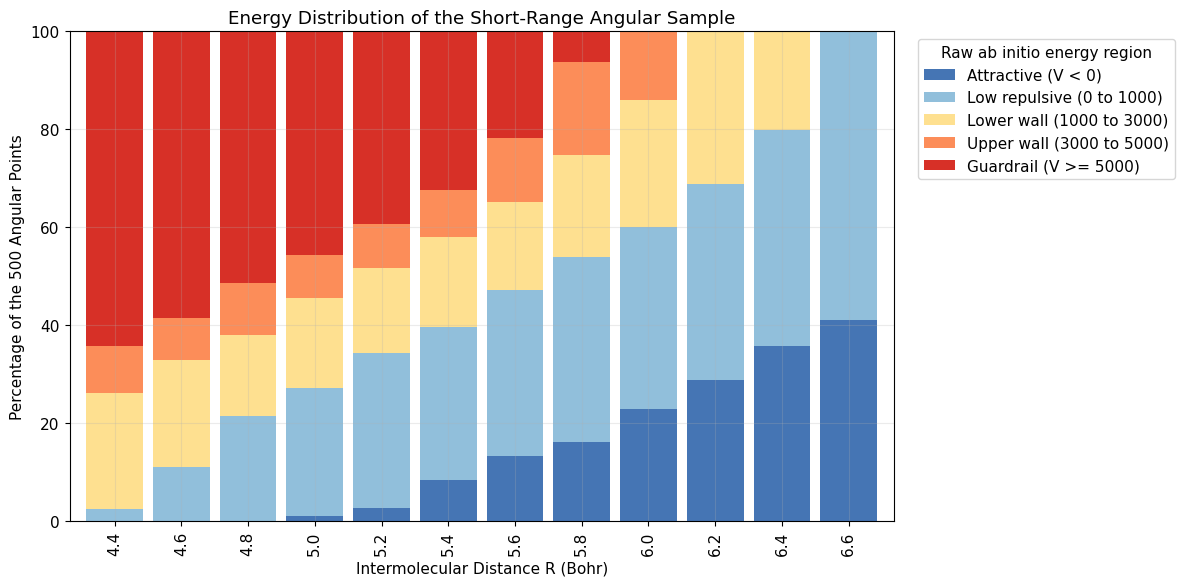

In [5]:
# Visualize how the composition of the angular sample changes with R.
band_colors = [
    "#4575b4",  # attractive
    "#91bfdb",  # low repulsive
    "#fee090",  # lower wall
    "#fc8d59",  # upper wall
    "#d73027",  # guardrail
]

ax = band_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=band_colors,
    width=0.85,
)

ax.set_title("Energy Distribution of the Short-Range Angular Sample")
ax.set_xlabel("Intermolecular Distance R (Bohr)")
ax.set_ylabel("Percentage of the 500 Angular Points")
ax.set_ylim(0, 100)
ax.legend(
    title="Raw ab initio energy region",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

### Interpretation of the energy-distribution audit

The composition of the angular sample changes substantially across the short-range radial interval.

At $R=4.4$ Bohr, only 179 of the 500 configurations lie below $5000\ \mathrm{cm}^{-1}$, while 321 configurations lie in the guardrail region. The lowest-energy region is especially sparse: only 13 points lie below $1000\ \mathrm{cm}^{-1}$, and none are attractive. Consequently, validation at this distance must preserve those rare points rather than allowing their errors to disappear inside an aggregate RMSE dominated by the wall.

As $R$ increases, the relevant region becomes progressively better sampled. The guardrail region disappears at $R=6.0$, the $3000$–$5000\ \mathrm{cm}^{-1}$ region disappears at $R=6.2$, and all configurations lie below $1000\ \mathrm{cm}^{-1}$ by $R=6.6$. This confirms that the sharp improvement previously observed near $R=6.4$–$6.6$ coincides with a qualitative change in the energy distribution of the angular sample.

All five energy bands will remain separate during validation. If a band contains no ab initio points at a particular $R$, it will be reported as unavailable rather than assigned an error of zero.

## 2.1 Working error measures

For the baseline analysis, configurations below
$5000\ \mathrm{cm}^{-1}$ use the pointwise tolerance

$$
\tau(V)=\max\left(1\ \mathrm{cm}^{-1},\,0.01|V|\right),
\qquad
z=\frac{|\widehat V-V|}{\tau(V)}.
$$

This hybrid rule avoids singular relative error near $V=0$ while
retaining an approximately 1% criterion at larger energies. It is a
**working acceptance specification**, not an independently established
physical law. Section 11 tests whether the principal conclusions survive
plausible changes to its absolute floor, relative fraction, physical
ceiling, and guardrail threshold.

For each populated energy band the notebook reports MAE, RMSE, the 95th
percentile and maximum of $z$, and the percentage satisfying $z\leq1$.
For the high wall, exact reproduction is replaced by explicit lower-tail
guardrail diagnostics.


In [6]:
ABSOLUTE_TOLERANCE_FLOOR = 1.0
RELATIVE_TOLERANCE = 0.01
PHYSICAL_ENERGY_CEILING = 5000.0
GUARDRAIL_WARNING_THRESHOLD = 3000.0
GUARDRAIL_DANGEROUS_THRESHOLD = 1000.0

RELEVANT_ENERGY_LABELS = ENERGY_LABELS[:-1]
GUARDRAIL_LABEL = ENERGY_LABELS[-1]


def hybrid_tolerance(
    V_true,
    absolute_floor=ABSOLUTE_TOLERANCE_FLOOR,
    relative_fraction=RELATIVE_TOLERANCE,
):
    """Return the working pointwise physical tolerance."""
    V_true = np.asarray(V_true, dtype=float)
    return np.maximum(
        absolute_floor,
        relative_fraction * np.abs(V_true),
    )


def hybrid_normalized_error(
    V_true,
    V_pred,
    absolute_floor=ABSOLUTE_TOLERANCE_FLOOR,
    relative_fraction=RELATIVE_TOLERANCE,
):
    """Return absolute error divided by the selected hybrid tolerance."""
    V_true = np.asarray(V_true, dtype=float)
    V_pred = np.asarray(V_pred, dtype=float)
    return np.abs(V_pred - V_true) / hybrid_tolerance(
        V_true,
        absolute_floor=absolute_floor,
        relative_fraction=relative_fraction,
    )


def score_relevant_predictions(
    V_true,
    V_pred,
    absolute_floor=ABSOLUTE_TOLERANCE_FLOOR,
    relative_fraction=RELATIVE_TOLERANCE,
):
    """Summarize prediction error in each populated band below 5000."""
    V_true = np.asarray(V_true, dtype=float)
    V_pred = np.asarray(V_pred, dtype=float)

    assigned_bands = pd.cut(
        V_true,
        bins=ENERGY_BINS,
        labels=ENERGY_LABELS,
        right=False,
        include_lowest=True,
    )

    rows = []
    for label in RELEVANT_ENERGY_LABELS:
        mask = np.asarray(assigned_bands == label)
        if not np.any(mask):
            continue

        truth = V_true[mask]
        prediction = V_pred[mask]
        absolute_error = np.abs(prediction - truth)
        normalized_error = hybrid_normalized_error(
            truth,
            prediction,
            absolute_floor=absolute_floor,
            relative_fraction=relative_fraction,
        )

        rows.append({
            "Energy band": label,
            "N": int(mask.sum()),
            "MAE (cm^-1)": np.mean(absolute_error),
            "RMSE (cm^-1)": np.sqrt(np.mean(absolute_error**2)),
            "P95 normalized error": np.percentile(normalized_error, 95),
            "Max normalized error": np.max(normalized_error),
            "Within tolerance (%)": 100.0 * np.mean(normalized_error <= 1.0),
        })

    return pd.DataFrame(rows)


## 2.2 Cross-validation at $N=400$

The first raw/switch comparison uses paired repeated five-fold
cross-validation: 400 of the existing candidates are fitted and 100 are
held out, with every orientation predicted once per repetition.

This is honest out-of-sample prediction **within the existing
500-orientation candidate grid**. It measures sensitivity to finite
angular subsets, but it is not validation at new continuous angular
geometries. All target treatments use identical folds.


In [7]:
def repeated_fivefold_splits(
    df_r,
    n_repeats=3,
    n_folds=5,
    random_seed=RANDOM_SEED,
):
    """
    Generate paired repeated five-fold splits.

    With 500 points and five folds, every split contains
    400 training points and 100 test points.
    """
    all_indices = df_r.index.to_numpy()
    rng = np.random.default_rng(random_seed)

    for repeat in range(n_repeats):
        shuffled_indices = rng.permutation(all_indices)
        folds = np.array_split(shuffled_indices, n_folds)

        for fold_number in range(n_folds):
            test_indices = folds[fold_number]
            train_indices = np.concatenate([
                fold
                for i, fold in enumerate(folds)
                if i != fold_number
            ])

            yield {
                "repeat": repeat,
                "fold": fold_number,
                "train_indices": train_indices,
                "test_indices": test_indices,
            }

In [8]:
# Verify the cross-validation structure before using it for any fits.
example_R = 4.4
example_slice = df_short[np.isclose(df_short["R"], example_R)]

example_splits = list(
    repeated_fivefold_splits(
        example_slice,
        n_repeats=3,
        n_folds=5,
    )
)

test_coverage = pd.Series(
    0,
    index=example_slice.index,
    dtype=int,
)

for split in example_splits:
    test_coverage.loc[split["test_indices"]] += 1

train_sizes = [len(split["train_indices"]) for split in example_splits]
test_sizes = [len(split["test_indices"]) for split in example_splits]

print("=== Cross-validation integrity audit ===")
print(f"Example R: {example_R}")
print(f"Total fits: {len(example_splits)}")
print(f"Training-set sizes: {sorted(set(train_sizes))}")
print(f"Test-set sizes: {sorted(set(test_sizes))}")
print(
    "Out-of-sample predictions per point: "
    f"{test_coverage.min()} to {test_coverage.max()}"
)

assert len(example_splits) == 15
assert set(train_sizes) == {400}
assert set(test_sizes) == {100}
assert test_coverage.eq(3).all()

=== Cross-validation integrity audit ===
Example R: 4.4
Total fits: 15
Training-set sizes: [400]
Test-set sizes: [100]
Out-of-sample predictions per point: 3 to 3


# 3. Treatment of the repulsive wall

The first fitting experiment compares two established baselines:

1. **Raw-potential fit:** ordinary least squares is applied directly to the raw ab initio energies.
2. **Current switched fit:** ordinary least squares is applied after transforming the high-energy portion of the target.

The current switching function is defined using thresholds

$$
V_{T1}=1000\ \mathrm{cm}^{-1},
\qquad
V_{T2}=5000\ \mathrm{cm}^{-1}.
$$

It leaves the potential unchanged below $V_{T1}$, transforms energies between the two thresholds using a nested sine function, and maps all energies above $V_{T2}$ to the constant

$$
V_{T1}+\frac{2}{\pi}(V_{T2}-V_{T1})
\approx 3546.5\ \mathrm{cm}^{-1}.
$$

The transformation can protect least squares from domination by extremely large repulsive energies. However, it also modifies the entire $1000$$–$5000\ \mathrm{cm}^{-1}$ region that the current study is intended to verify.

Both models will therefore be evaluated against the **raw ab initio potential** at all points below $5000\ \mathrm{cm}^{-1}$. Above that boundary, the analysis will examine whether the fitted surface remains strongly repulsive rather than requiring it to reproduce the raw wall point by point.

The comparison begins at $R=4.4$ using the repeated five-fold protocol with 400 training points per fit.

In [9]:
LSTSQ_RCOND = 1e-4

CURRENT_SWITCH_T1 = 1000.0
CURRENT_SWITCH_T2 = 5000.0


def raw_target(V):
    """Return the unmodified ab initio potential."""
    return np.asarray(V, dtype=float)


def apply_current_switch(
    V,
    V_T1=CURRENT_SWITCH_T1,
    V_T2=CURRENT_SWITCH_T2,
):
    """Apply the switching function used in the existing fitting workflow."""
    V = np.asarray(V, dtype=float)
    V_switched = np.empty_like(V)

    below = V <= V_T1
    above = V > V_T2
    middle = ~(below | above)

    V_switched[below] = V[below]

    cap = V_T1 + (2.0 / np.pi) * (V_T2 - V_T1)
    V_switched[above] = cap

    u = (V[middle] - V_T1) / (V_T2 - V_T1)

    S_u = (
        (2.0 / np.pi)
        * np.sin(
            (np.pi / 2.0)
            * np.sin((np.pi / 2.0) * u)
        )
    )

    V_switched[middle] = (
        V_T1
        + (V_T2 - V_T1) * S_u
    )

    return V_switched


CURRENT_SWITCH_CAP = (
    CURRENT_SWITCH_T1
    + (2.0 / np.pi)
    * (CURRENT_SWITCH_T2 - CURRENT_SWITCH_T1)
)

print(f"Current high-energy cap: {CURRENT_SWITCH_CAP:.3f} cm^-1")

Current high-energy cap: 3546.479 cm^-1


In [10]:
# Inspect the transformation numerically before fitting it.
switch_audit_energies = np.array([
    -200.0,
    0.0,
    500.0,
    1000.0,
    1500.0,
    2000.0,
    3000.0,
    4000.0,
    5000.0,
    10000.0,
    70000.0,
])

switch_audit = pd.DataFrame({
    "Raw V": switch_audit_energies,
    "Switched V": apply_current_switch(switch_audit_energies),
})

switch_audit["Change"] = (
    switch_audit["Switched V"] - switch_audit["Raw V"]
)

print("=== Current switching-function audit ===")
print(switch_audit.round(3).to_string(index=False))

=== Current switching-function audit ===
  Raw V  Switched V     Change
 -200.0    -200.000      0.000
    0.0       0.000      0.000
  500.0     500.000      0.000
 1000.0    1000.000      0.000
 1500.0    1768.205    268.205
 2000.0    2440.198    440.198
 3000.0    3281.693    281.693
 4000.0    3528.297   -471.703
 5000.0    3546.479  -1453.521
10000.0    3546.479  -6453.521
70000.0    3546.479 -66453.521


## 3.1 Shared angular design matrix

Because the angular coordinates are identical at every radial distance,
the 158-column design matrix is constructed once, ordered by
`orientation_id`, and reused at every $R$.


In [11]:
def angles_from_df(df):
    """Return the three angular coordinates in radians."""
    return (
        np.radians(df["Theta_1"].to_numpy()),
        np.radians(df["Theta_2"].to_numpy()),
        np.radians(df["Phi"].to_numpy()),
    )


def build_design_matrix(df_angles, basis):
    """Construct the angular design matrix for a set of orientations."""
    theta1, theta2, phi = angles_from_df(df_angles)

    M = np.empty((len(df_angles), len(basis)))

    for column, (l1, l2, l) in enumerate(basis):
        M[:, column] = evaluate_A_basis(
            l1,
            l2,
            l,
            theta1,
            theta2,
            phi,
        )

    return M


# Keep exactly one copy of each shared angular orientation.
reference_angles = (
    df_all
    .drop_duplicates(subset="orientation_id")
    .sort_values("orientation_id")
)

assert np.array_equal(
    reference_angles["orientation_id"].to_numpy(),
    np.arange(EXPECTED_POINTS_PER_R),
)

M_orientation = build_design_matrix(
    reference_angles,
    basis_indices,
)

singular_values = np.linalg.svd(
    M_orientation,
    compute_uv=False,
)

matrix_rank = np.linalg.matrix_rank(M_orientation)
matrix_condition = singular_values[0] / singular_values[-1]

print("=== Shared design-matrix audit ===")
print(f"Shape: {M_orientation.shape}")
print(f"Numerical rank: {matrix_rank}")
print(f"Condition number: {matrix_condition:.3e}")
print(f"All entries finite: {np.isfinite(M_orientation).all()}")

assert M_orientation.shape == (
    EXPECTED_POINTS_PER_R,
    EXPECTED_BASIS_TERMS,
)
assert matrix_rank == EXPECTED_BASIS_TERMS
assert np.isfinite(M_orientation).all()

=== Shared design-matrix audit ===
Shape: (500, 158)
Numerical rank: 158
Condition number: 4.571e+01
All entries finite: True


## 3.2 Guardrail diagnostics

The switched target intentionally maps the extreme wall to a finite
barrier, so demanding pointwise agreement above
$5000\ \mathrm{cm}^{-1}$ would be inappropriate. The baseline guardrail
audit instead records the minimum and lower tail of fitted predictions
where the raw truth is at or above $5000\ \mathrm{cm}^{-1}$, including
the fractions below $3000$ and $1000\ \mathrm{cm}^{-1}$.

The $3000\ \mathrm{cm}^{-1}$ threshold is used as the notebook's baseline
screening rule. It remains a working methodological choice and is varied
in the acceptance-criterion sensitivity analysis.


In [12]:
def score_guardrail_predictions(
    V_true,
    V_pred,
    true_guardrail_threshold=PHYSICAL_ENERGY_CEILING,
    warning_prediction_threshold=GUARDRAIL_WARNING_THRESHOLD,
    dangerous_prediction_threshold=GUARDRAIL_DANGEROUS_THRESHOLD,
):
    """Describe predictions where the raw truth lies in the high wall."""
    V_true = np.asarray(V_true, dtype=float)
    V_pred = np.asarray(V_pred, dtype=float)

    mask = V_true >= true_guardrail_threshold
    guardrail_predictions = V_pred[mask]

    if len(guardrail_predictions) == 0:
        return pd.DataFrame([{
            "N": 0,
            "Minimum predicted V": np.nan,
            "5th percentile predicted V": np.nan,
            "Predicted below 3000 (%)": np.nan,
            "Predicted below 1000 (%)": np.nan,
        }])

    return pd.DataFrame([{
        "N": len(guardrail_predictions),
        "Minimum predicted V": np.min(guardrail_predictions),
        "5th percentile predicted V": np.percentile(
            guardrail_predictions, 5
        ),
        "Predicted below 3000 (%)": 100.0 * np.mean(
            guardrail_predictions < warning_prediction_threshold
        ),
        "Predicted below 1000 (%)": 100.0 * np.mean(
            guardrail_predictions < dangerous_prediction_threshold
        ),
    }])


In [13]:
TARGET_METHODS = {
    "Raw potential": raw_target,
    "Current switch": apply_current_switch,
}


def cross_validate_target_methods_at_R(
    df,
    target_R,
    design_matrix,
    target_methods=TARGET_METHODS,
    n_repeats=3,
    n_folds=5,
    rcond=LSTSQ_RCOND,
):
    """
    Compare target treatments using paired repeated five-fold fits.

    Each repetition returns one out-of-sample prediction for every
    angular orientation.
    """
    df_r = df[np.isclose(df["R"], target_R)].copy()

    if len(df_r) != EXPECTED_POINTS_PER_R:
        raise ValueError(
            f"Expected {EXPECTED_POINTS_PER_R} points at R={target_R}, "
            f"but found {len(df_r)}."
        )

    truth_by_orientation = (
        df_r
        .set_index("orientation_id")["V"]
        .reindex(range(EXPECTED_POINTS_PER_R))
        .to_numpy()
    )

    splits = list(
        repeated_fivefold_splits(
            df_r,
            n_repeats=n_repeats,
            n_folds=n_folds,
        )
    )

    predictions = {
        (method_name, repeat): np.full(
            EXPECTED_POINTS_PER_R,
            np.nan,
        )
        for method_name in target_methods
        for repeat in range(n_repeats)
    }

    for split in splits:
        repeat = split["repeat"]

        train_df = df_r.loc[split["train_indices"]]
        test_df = df_r.loc[split["test_indices"]]

        train_ids = train_df["orientation_id"].to_numpy()
        test_ids = test_df["orientation_id"].to_numpy()

        M_train = design_matrix[train_ids]
        M_test = design_matrix[test_ids]

        raw_training_values = train_df["V"].to_numpy()

        for method_name, target_function in target_methods.items():
            y_train = target_function(raw_training_values)

            coefficients, *_ = np.linalg.lstsq(
                M_train,
                y_train,
                rcond=rcond,
            )

            predictions[(method_name, repeat)][test_ids] = (
                M_test @ coefficients
            )

    relevant_results = []
    guardrail_results = []

    for method_name in target_methods:
        for repeat in range(n_repeats):
            prediction = predictions[(method_name, repeat)]

            if not np.isfinite(prediction).all():
                raise RuntimeError(
                    f"Incomplete predictions for "
                    f"{method_name}, repeat {repeat}."
                )

            relevant = score_relevant_predictions(
                truth_by_orientation,
                prediction,
            )
            relevant.insert(0, "Repeat", repeat)
            relevant.insert(0, "Method", method_name)
            relevant.insert(0, "R", target_R)
            relevant_results.append(relevant)

            guardrail = score_guardrail_predictions(
                truth_by_orientation,
                prediction,
            )
            guardrail.insert(0, "Repeat", repeat)
            guardrail.insert(0, "Method", method_name)
            guardrail.insert(0, "R", target_R)
            guardrail_results.append(guardrail)

    return (
        pd.concat(relevant_results, ignore_index=True),
        pd.concat(guardrail_results, ignore_index=True),
        predictions,
        truth_by_orientation,
    )

In [14]:
relevant_r44, guardrail_r44, predictions_r44, truth_r44 = (
    cross_validate_target_methods_at_R(
        df_all,
        target_R=4.4,
        design_matrix=M_orientation,
    )
)

relevant_r44_summary = (
    relevant_r44
    .groupby(["Method", "Energy band"], sort=False)
    .agg(
        N=("N", "first"),
        mean_MAE=("MAE (cm^-1)", "mean"),
        mean_RMSE=("RMSE (cm^-1)", "mean"),
        mean_P95_normalized_error=(
            "P95 normalized error",
            "mean",
        ),
        worst_max_normalized_error=(
            "Max normalized error",
            "max",
        ),
        mean_within_tolerance_percent=(
            "Within tolerance (%)",
            "mean",
        ),
    )
    .reset_index()
)

guardrail_r44_summary = (
    guardrail_r44
    .groupby("Method", sort=False)
    .agg(
        N=("N", "first"),
        mean_minimum_prediction=(
            "Minimum predicted V",
            "mean",
        ),
        mean_5th_percentile_prediction=(
            "5th percentile predicted V",
            "mean",
        ),
        mean_percent_below_3000=(
            "Predicted below 3000 (%)",
            "mean",
        ),
        mean_percent_below_1000=(
            "Predicted below 1000 (%)",
            "mean",
        ),
    )
    .reset_index()
)

print("=== R = 4.4: Out-of-sample accuracy below 5000 cm^-1 ===")
print(
    relevant_r44_summary
    .round(3)
    .to_string(index=False)
)

print("\n=== R = 4.4: Guardrail behavior for true V >= 5000 cm^-1 ===")
print(
    guardrail_r44_summary
    .round(3)
    .to_string(index=False)
)

=== R = 4.4: Out-of-sample accuracy below 5000 cm^-1 ===
        Method               Energy band   N  mean_MAE  mean_RMSE  mean_P95_normalized_error  worst_max_normalized_error  mean_within_tolerance_percent
 Raw potential Low repulsive (0 to 1000)  13     2.646      3.578                      0.888                       1.149                         94.872
 Raw potential Lower wall (1000 to 3000) 118     2.426      4.087                      0.408                       0.950                        100.000
 Raw potential Upper wall (3000 to 5000)  48     3.659      5.581                      0.279                       1.001                         99.306
Current switch Low repulsive (0 to 1000)  13    13.583     16.389                      3.663                       4.077                         35.897
Current switch Lower wall (1000 to 3000) 118   312.001    341.619                     22.278                      23.305                          0.000
Current switch Upper wall (3000

### 3.3 Decompose physical error into target distortion and regression error

For a transformed target,

$$
\widehat V_{\mathrm{method}}-V
=
(V_{\mathrm{method}}-V)
+(\widehat V_{\mathrm{method}}-V_{\mathrm{method}}).
$$

The first term is target distortion and the second is regression error
relative to the fitted target. Below $1000\ \mathrm{cm}^{-1}$ the current
switch is exactly the identity, so any difference there is regression
spillover. The guardrail region is monitored separately.


In [15]:
PHYSICAL_ENERGY_BANDS = [
    ("Attractive (V < 0)", lambda V: V < 0.0),
    ("Low repulsive (0 to 1000)", lambda V: (V >= 0.0) & (V < 1000.0)),
    ("Lower wall (1000 to 3000)", lambda V: (V >= 1000.0) & (V < 3000.0)),
    ("Upper wall (3000 to 5000)", lambda V: (V >= 3000.0) & (V < 5000.0)),
]


def summarize_error_decomposition(raw_truth, predictions, target_methods):
    """
    Decompose cross-validated physical error into:

        target distortion = transformed target - raw target
        regression error  = prediction - transformed target
        physical error    = prediction - raw target

    Parameters
    ----------
    raw_truth : array-like, shape (n_points,)
        Original ab initio energies, ordered consistently with predictions.

    predictions : dict
        predictions[method] must have shape (n_repeats, n_points), or
        shape (n_points,) for a single repeat.

    target_methods : dict
        Mapping from method name to its target-transformation function.
    """
    raw_truth = np.asarray(raw_truth, dtype=float)
    rows = []

    for method_name, target_function in target_methods.items():
        target_truth = np.asarray(
            target_function(raw_truth),
            dtype=float
        )

        matching_keys = sorted(
            [
                key
                for key in predictions
                if key[0] == method_name
            ],
            key=lambda key: key[1],
        )

        if not matching_keys:
            raise KeyError(
                f"No predictions found for method {method_name!r}. "
                f"Available keys are: {list(predictions.keys())}"
            )

        method_predictions = np.stack(
            [
                np.asarray(predictions[key], dtype=float)
                for key in matching_keys
            ],
            axis=0,
        )

        if method_predictions.shape[1] != raw_truth.size:
            raise ValueError(
                f"{method_name}: predictions contain "
                f"{method_predictions.shape[1]} points, but raw_truth "
                f"contains {raw_truth.size}."
            )

        target_shift = target_truth - raw_truth

        for band_name, mask_function in PHYSICAL_ENERGY_BANDS:
            mask = mask_function(raw_truth)
            n_points = int(mask.sum())

            if n_points == 0:
                continue

            regression_error = (
                method_predictions[:, mask]
                - target_truth[None, mask]
            )

            physical_error = (
                method_predictions[:, mask]
                - raw_truth[None, mask]
            )

            regression_mae_by_repeat = np.mean(
                np.abs(regression_error),
                axis=1
            )

            physical_mae_by_repeat = np.mean(
                np.abs(physical_error),
                axis=1
            )

            physical_bias_by_repeat = np.mean(
                physical_error,
                axis=1
            )

            rows.append({
                "Method": method_name,
                "Energy band": band_name,
                "N": n_points,

                # Transformation alone; identical across CV repeats.
                "Mean target shift": np.mean(target_shift[mask]),
                "Target-distortion MAE": np.mean(
                    np.abs(target_shift[mask])
                ),

                # Mean performance across repeated five-fold CV runs.
                "CV MAE to own target": np.mean(
                    regression_mae_by_repeat
                ),
                "CV MAE to raw potential": np.mean(
                    physical_mae_by_repeat
                ),
                "Mean signed physical error": np.mean(
                    physical_bias_by_repeat
                ),
            })

    result = pd.DataFrame(rows)

    band_order = {
        name: index
        for index, (name, _) in enumerate(PHYSICAL_ENERGY_BANDS)
    }
    method_order = {
        name: index
        for index, name in enumerate(target_methods)
    }

    result["_method_order"] = result["Method"].map(method_order)
    result["_band_order"] = result["Energy band"].map(band_order)

    result = (
        result
        .sort_values(["_method_order", "_band_order"])
        .drop(columns=["_method_order", "_band_order"])
        .reset_index(drop=True)
    )

    return result

In [16]:
decomposition_r44 = summarize_error_decomposition(
    raw_truth=truth_r44,
    predictions=predictions_r44,
    target_methods=TARGET_METHODS,
)

print("=== R = 4.4: Physical-error decomposition ===")

print(
    decomposition_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

=== R = 4.4: Physical-error decomposition ===
        Method               Energy band   N  Mean target shift  Target-distortion MAE  CV MAE to own target  CV MAE to raw potential  Mean signed physical error
 Raw potential Low repulsive (0 to 1000)  13              0.000                  0.000                 2.646                    2.646                      -0.308
 Raw potential Lower wall (1000 to 3000) 118              0.000                  0.000                 2.426                    2.426                       0.299
 Raw potential Upper wall (3000 to 5000)  48              0.000                  0.000                 3.659                    3.659                      -0.056
Current switch Low repulsive (0 to 1000)  13              0.000                  0.000                13.583                   13.583                      -4.405
Current switch Lower wall (1000 to 3000) 118            311.511                311.511                 7.911                  312.001           

### 3.4 Representative short-range radial slices

The paired comparison is repeated at $R=5.8$ and at the $R=6.6$
identity control. At $R=6.6$ every target lies below
$1000\ \mathrm{cm}^{-1}$, so raw and switched fits must agree exactly.


In [17]:
ANCHOR_R_VALUES = [4.4, 5.8, 6.6]

# Preserve the R=4.4 results already computed.
anchor_results = {
    4.4: {
        "relevant": relevant_r44,
        "guardrail": guardrail_r44,
        "predictions": predictions_r44,
        "truth": truth_r44,
    }
}

# Compute only the two new anchor slices.
for target_R in [5.8, 6.6]:
    relevant, guardrail, predictions, truth = (
        cross_validate_target_methods_at_R(
            df_all,
            target_R=target_R,
            design_matrix=M_orientation,
        )
    )

    anchor_results[target_R] = {
        "relevant": relevant,
        "guardrail": guardrail,
        "predictions": predictions,
        "truth": truth,
    }

In [18]:
anchor_relevant = pd.concat(
    [
        anchor_results[R]["relevant"]
        for R in ANCHOR_R_VALUES
    ],
    ignore_index=True,
)

anchor_relevant_summary = (
    anchor_relevant
    .groupby(["R", "Method", "Energy band"], sort=False)
    .agg(
        N=("N", "first"),
        mean_MAE=("MAE (cm^-1)", "mean"),
        mean_RMSE=("RMSE (cm^-1)", "mean"),
        mean_P95_normalized_error=(
            "P95 normalized error",
            "mean",
        ),
        worst_max_normalized_error=(
            "Max normalized error",
            "max",
        ),
        mean_within_tolerance_percent=(
            "Within tolerance (%)",
            "mean",
        ),
    )
    .reset_index()
)

print(
    "=== Anchor-slice accuracy below 5000 cm^-1 ==="
)

print(
    anchor_relevant_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

=== Anchor-slice accuracy below 5000 cm^-1 ===
    R         Method               Energy band   N  mean_MAE  mean_RMSE  mean_P95_normalized_error  worst_max_normalized_error  mean_within_tolerance_percent
4.400  Raw potential Low repulsive (0 to 1000)  13     2.646      3.578                      0.888                       1.149                         94.872
4.400  Raw potential Lower wall (1000 to 3000) 118     2.426      4.087                      0.408                       0.950                        100.000
4.400  Raw potential Upper wall (3000 to 5000)  48     3.659      5.581                      0.279                       1.001                         99.306
4.400 Current switch Low repulsive (0 to 1000)  13    13.583     16.389                      3.663                       4.077                         35.897
4.400 Current switch Lower wall (1000 to 3000) 118   312.001    341.619                     22.278                      23.305                          0.000
4.400

In [19]:
anchor_guardrail = pd.concat(
    [
        anchor_results[R]["guardrail"]
        for R in ANCHOR_R_VALUES
    ],
    ignore_index=True,
)

anchor_guardrail_summary = (
    anchor_guardrail
    .groupby(["R", "Method"], sort=False)
    .agg(
        N=("N", "first"),
        mean_minimum_prediction=(
            "Minimum predicted V",
            "mean",
        ),
        mean_5th_percentile_prediction=(
            "5th percentile predicted V",
            "mean",
        ),
        mean_percent_below_3000=(
            "Predicted below 3000 (%)",
            "mean",
        ),
        mean_percent_below_1000=(
            "Predicted below 1000 (%)",
            "mean",
        ),
    )
    .reset_index()
)

# A slice with N=0 has no guardrail region to evaluate.
anchor_guardrail_summary = anchor_guardrail_summary[
    anchor_guardrail_summary["N"] > 0
]

print(
    "=== Anchor-slice guardrail behavior ==="
)

print(
    anchor_guardrail_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

=== Anchor-slice guardrail behavior ===
    R         Method   N  mean_minimum_prediction  mean_5th_percentile_prediction  mean_percent_below_3000  mean_percent_below_1000
4.400  Raw potential 321                 5274.571                        6347.846                    0.000                    0.000
4.400 Current switch 321                 3524.948                        3540.579                    0.000                    0.000
5.800  Raw potential  31                 5016.516                        5059.909                    0.000                    0.000
5.800 Current switch  31                 3538.407                        3541.401                    0.000                    0.000


In [20]:
identity_control_rows = []

for repeat in range(3):
    raw_prediction = anchor_results[6.6]["predictions"][
        ("Raw potential", repeat)
    ]

    switched_prediction = anchor_results[6.6]["predictions"][
        ("Current switch", repeat)
    ]

    identity_control_rows.append({
        "Repeat": repeat,
        "Maximum prediction difference": np.max(
            np.abs(raw_prediction - switched_prediction)
        ),
    })

identity_control = pd.DataFrame(identity_control_rows)

print("=== R = 6.6 identity-control audit ===")
print(
    identity_control.to_string(
        index=False,
        float_format=lambda x: f"{x:.3e}",
    )
)

assert np.allclose(
    identity_control["Maximum prediction difference"],
    0.0,
    atol=1e-10,
    rtol=0.0,
)

=== R = 6.6 identity-control audit ===
 Repeat  Maximum prediction difference
      0                      0.000e+00
      1                      0.000e+00
      2                      0.000e+00


### 3.5 Provisional high-count decision

At $N=400$, the raw target is the better primary branch for fidelity to
the raw potential below $5000\ \mathrm{cm}^{-1}$. The current switch
introduces substantial target distortion in the 1000–5000 region and
produces measurable spillover below 1000, while the raw fits show no
dangerous guardrail opening at the sampled candidates.

This is **not yet a global retirement of switching**. The July 9 meeting
specifically suggested that compression may help when data are sparse.
Section 8 therefore repeats the comparison at low, intermediate, and high
point counts under both random and D-optimal sampling before the final
wall-treatment conclusion is stated.


## 4. Full short-range raw-potential baseline

Before reducing the number of sampled orientations, the raw-potential fit is
evaluated at every short-range radial slice using 10 repeated five-fold
partitions.

At each radius:

- each fit uses 400 training orientations and 100 held-out orientations;
- each orientation receives 10 out-of-sample predictions;
- all 158 angular basis terms are retained;
- the same least-squares threshold and physical scoring rules are used.

This establishes the best-supported raw-potential performance available from
the existing 500-orientation grid. Later point-count experiments will be
compared against this baseline.

Repeated cross-validation is used here to measure sensitivity to the selected
training subset. Because repetitions share observations, their variation is a
stability diagnostic rather than a formal independent-sample uncertainty.

In [21]:
RAW_ONLY_METHOD = {
    "Raw potential": raw_target,
}

BASELINE_N_REPEATS = 10

SHORT_RANGE_R_VALUES = (
    df_all.loc[
        (df_all["R"] >= 4.4)
        & (df_all["R"] <= 6.6),
        "R",
    ]
    .drop_duplicates()
    .sort_values()
    .to_numpy()
)

print("Short-range radial slices:")
print(SHORT_RANGE_R_VALUES)

raw_baseline_results = {}

for target_R in SHORT_RANGE_R_VALUES:
    relevant, guardrail, predictions, truth = (
        cross_validate_target_methods_at_R(
            df_all,
            target_R=target_R,
            design_matrix=M_orientation,
            target_methods=RAW_ONLY_METHOD,
            n_repeats=BASELINE_N_REPEATS,
            n_folds=5,
        )
    )

    raw_baseline_results[target_R] = {
        "relevant": relevant,
        "guardrail": guardrail,
        "predictions": predictions,
        "truth": truth,
    }

    print(
        f"Completed R = {target_R:.1f}: "
        f"{BASELINE_N_REPEATS * 5} fits"
    )

Short-range radial slices:
[4.4 4.6 4.8 5.  5.2 5.4 5.6 5.8 6.  6.2 6.4 6.6]
Completed R = 4.4: 50 fits
Completed R = 4.6: 50 fits
Completed R = 4.8: 50 fits
Completed R = 5.0: 50 fits
Completed R = 5.2: 50 fits
Completed R = 5.4: 50 fits
Completed R = 5.6: 50 fits
Completed R = 5.8: 50 fits
Completed R = 6.0: 50 fits
Completed R = 6.2: 50 fits
Completed R = 6.4: 50 fits
Completed R = 6.6: 50 fits


In [22]:
def summarize_raw_baseline_by_radius(
    baseline_results,
    n_repeats,
):
    rows = []

    for target_R, result in baseline_results.items():
        truth = np.asarray(result["truth"], dtype=float)

        relevant_mask = truth < 5000.0
        relevant_truth = truth[relevant_mask]

        tolerance = np.maximum(
            1.0,
            0.01 * np.abs(relevant_truth),
        )

        for repeat in range(n_repeats):
            prediction = np.asarray(
                result["predictions"][
                    ("Raw potential", repeat)
                ],
                dtype=float,
            )

            error = (
                prediction[relevant_mask]
                - relevant_truth
            )

            absolute_error = np.abs(error)
            normalized_error = absolute_error / tolerance

            rows.append({
                "R": target_R,
                "Repeat": repeat,
                "N below 5000": int(relevant_mask.sum()),
                "N at or above 5000": int(
                    (~relevant_mask).sum()
                ),
                "MAE (cm^-1)": np.mean(absolute_error),
                "RMSE (cm^-1)": np.sqrt(
                    np.mean(error**2)
                ),
                "P95 normalized error": np.percentile(
                    normalized_error,
                    95,
                ),
                "Max normalized error": np.max(
                    normalized_error
                ),
                "Within tolerance (%)": (
                    100.0
                    * np.mean(normalized_error <= 1.0)
                ),
            })

    per_repeat = pd.DataFrame(rows)

    summary = (
        per_repeat
        .groupby("R", sort=True)
        .agg(
            N_below_5000=("N below 5000", "first"),
            N_at_or_above_5000=(
                "N at or above 5000",
                "first",
            ),
            mean_MAE=("MAE (cm^-1)", "mean"),
            worst_repeat_MAE=("MAE (cm^-1)", "max"),
            mean_RMSE=("RMSE (cm^-1)", "mean"),
            mean_P95_normalized_error=(
                "P95 normalized error",
                "mean",
            ),
            worst_max_normalized_error=(
                "Max normalized error",
                "max",
            ),
            mean_within_tolerance_percent=(
                "Within tolerance (%)",
                "mean",
            ),
            worst_repeat_within_tolerance_percent=(
                "Within tolerance (%)",
                "min",
            ),
        )
        .reset_index()
    )

    return per_repeat, summary

In [23]:
(
    raw_baseline_per_repeat,
    raw_baseline_summary,
) = summarize_raw_baseline_by_radius(
    raw_baseline_results,
    n_repeats=BASELINE_N_REPEATS,
)

print(
    "=== Full short-range raw-potential baseline ==="
)

print(
    raw_baseline_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

=== Full short-range raw-potential baseline ===
    R  N_below_5000  N_at_or_above_5000  mean_MAE  worst_repeat_MAE  mean_RMSE  mean_P95_normalized_error  worst_max_normalized_error  mean_within_tolerance_percent  worst_repeat_within_tolerance_percent
4.400           179                 321     2.954             3.449      4.999                      0.507                       2.788                         98.994                                 97.765
4.600           208                 292     1.146             1.351      1.931                      0.307                       2.135                         99.663                                 99.038
4.800           243                 257     0.504             0.586      0.827                      0.216                       2.249                         99.588                                 99.177
5.000           272                 228     0.236             0.266      0.380                      0.177                       1.928   

## 5. Retrospective point-count experiments

The following paired learning curves ask how accurately random subsets
reconstruct held-out members of the existing 500-orientation grid. They
diagnose rank, conditioning, and finite-sample error as a function of
point count. They do not establish a universal physical minimum or
continuous-angle accuracy.

Training prefixes of 158, 175, 200, 225, 250, 300, 350, and 400 are
nested inside common 400-point training pools, with identical test folds
at every count and radial slice.


In [24]:
POINT_COUNT_VALUES = np.array([
    158,
    175,
    200,
    225,
    250,
    300,
    350,
    400,
])

POINT_COUNT_N_REPEATS = 10
POINT_COUNT_N_FOLDS = 5
POINT_COUNT_RANDOM_SEED = 20260713


def nested_point_count_splits(
    n_points=EXPECTED_POINTS_PER_R,
    training_sizes=POINT_COUNT_VALUES,
    n_repeats=POINT_COUNT_N_REPEATS,
    n_folds=POINT_COUNT_N_FOLDS,
    random_seed=POINT_COUNT_RANDOM_SEED,
):
    """
    Generate paired, nested training subsets within repeated test folds.

    Each repetition partitions all orientations into disjoint test folds.
    For a given fold, the complementary training pool is randomly ordered.
    Every requested training set is a prefix of this common ordering.
    """
    orientation_ids = np.arange(n_points)
    training_sizes = np.asarray(training_sizes, dtype=int)

    if n_points % n_folds != 0:
        raise ValueError(
            "This implementation requires equal-sized test folds."
        )

    test_size = n_points // n_folds
    maximum_training_size = n_points - test_size

    if np.any(training_sizes < len(basis_indices)):
        raise ValueError(
            "Training sizes smaller than the number of basis "
            "coefficients are not included in this experiment."
        )

    if np.any(training_sizes > maximum_training_size):
        raise ValueError(
            f"Training sizes cannot exceed "
            f"{maximum_training_size} with these test folds."
        )

    if np.any(np.diff(training_sizes) <= 0):
        raise ValueError(
            "Training sizes must be strictly increasing."
        )

    for repeat in range(n_repeats):
        repeat_rng = np.random.default_rng(
            np.random.SeedSequence([
                random_seed,
                repeat,
            ])
        )

        shuffled_ids = repeat_rng.permutation(
            orientation_ids
        )

        test_folds = np.split(
            shuffled_ids,
            n_folds,
        )

        for fold, test_ids in enumerate(test_folds):
            training_pool = np.setdiff1d(
                orientation_ids,
                test_ids,
                assume_unique=True,
            )

            pool_rng = np.random.default_rng(
                np.random.SeedSequence([
                    random_seed,
                    repeat,
                    fold,
                    1,
                ])
            )

            training_order = pool_rng.permutation(
                training_pool
            )

            yield {
                "repeat": repeat,
                "fold": fold,
                "test_ids": test_ids,
                "training_order": training_order,
            }

In [25]:
point_count_splits = list(
    nested_point_count_splits()
)

test_coverage = np.zeros(
    (
        POINT_COUNT_N_REPEATS,
        EXPECTED_POINTS_PER_R,
    ),
    dtype=int,
)

nested_sets_verified = True

for split in point_count_splits:
    repeat = split["repeat"]
    test_ids = split["test_ids"]
    training_order = split["training_order"]

    test_coverage[repeat, test_ids] += 1

    for smaller_N, larger_N in zip(
        POINT_COUNT_VALUES[:-1],
        POINT_COUNT_VALUES[1:],
    ):
        smaller_set = set(
            training_order[:smaller_N]
        )
        larger_set = set(
            training_order[:larger_N]
        )

        if not smaller_set.issubset(larger_set):
            nested_sets_verified = False

print("=== Nested point-count split audit ===")
print(f"Repeats: {POINT_COUNT_N_REPEATS}")
print(f"Folds per repeat: {POINT_COUNT_N_FOLDS}")
print(f"Total fold configurations: {len(point_count_splits)}")
print(
    "Test-set sizes:",
    sorted({
        len(split["test_ids"])
        for split in point_count_splits
    }),
)
print(
    "Training-pool sizes:",
    sorted({
        len(split["training_order"])
        for split in point_count_splits
    }),
)
print(
    "Out-of-sample predictions per point and repeat:",
    f"{test_coverage.min()} to {test_coverage.max()}",
)
print(f"Nested training sets verified: {nested_sets_verified}")
print(f"Training sizes: {POINT_COUNT_VALUES.tolist()}")

=== Nested point-count split audit ===
Repeats: 10
Folds per repeat: 5
Total fold configurations: 50
Test-set sizes: [100]
Training-pool sizes: [400]
Out-of-sample predictions per point and repeat: 1 to 1
Nested training sets verified: True
Training sizes: [158, 175, 200, 225, 250, 300, 350, 400]


In [26]:
def run_raw_point_count_experiment_at_R(
    df,
    target_R,
    design_matrix,
    splits,
    training_sizes=POINT_COUNT_VALUES,
    rcond=LSTSQ_RCOND,
):
    """
    Evaluate raw-potential fitting over nested training sizes.

    Returns band-resolved physical scores, guardrail scores,
    out-of-sample predictions, fit diagnostics, and raw truth.
    """
    df_r = df[np.isclose(df["R"], target_R)].copy()

    truth_by_orientation = (
        df_r
        .set_index("orientation_id")["V"]
        .reindex(range(EXPECTED_POINTS_PER_R))
        .to_numpy()
    )

    repeats = sorted({
        split["repeat"]
        for split in splits
    })

    predictions = {
        (int(training_N), repeat): np.full(
            EXPECTED_POINTS_PER_R,
            np.nan,
        )
        for training_N in training_sizes
        for repeat in repeats
    }

    fit_diagnostic_rows = []

    for split in splits:
        repeat = split["repeat"]
        fold = split["fold"]
        test_ids = split["test_ids"]
        training_order = split["training_order"]

        M_test = design_matrix[test_ids]

        for training_N in training_sizes:
            training_N = int(training_N)
            train_ids = training_order[:training_N]

            M_train = design_matrix[train_ids]
            y_train = truth_by_orientation[train_ids]

            (
                coefficients,
                residuals,
                retained_rank,
                singular_values,
            ) = np.linalg.lstsq(
                M_train,
                y_train,
                rcond=rcond,
            )

            predictions[
                (training_N, repeat)
            ][test_ids] = M_test @ coefficients

            if singular_values[-1] > 0.0:
                matrix_condition = (
                    singular_values[0]
                    / singular_values[-1]
                )
            else:
                matrix_condition = np.inf

            fit_diagnostic_rows.append({
                "R": target_R,
                "Training points": training_N,
                "Repeat": repeat,
                "Fold": fold,
                "Retained rank": retained_rank,
                "Rank deficient": (
                    retained_rank < len(basis_indices)
                ),
                "Condition number": matrix_condition,
                "Coefficient norm": np.linalg.norm(
                    coefficients
                ),
            })

    relevant_rows = []
    guardrail_rows = []

    for training_N in training_sizes:
        training_N = int(training_N)

        for repeat in repeats:
            prediction = predictions[
                (training_N, repeat)
            ]

            if not np.isfinite(prediction).all():
                raise RuntimeError(
                    "Incomplete out-of-sample predictions for "
                    f"N={training_N}, repeat={repeat}."
                )

            relevant = score_relevant_predictions(
                truth_by_orientation,
                prediction,
            )
            relevant.insert(0, "Repeat", repeat)
            relevant.insert(
                0,
                "Training points",
                training_N,
            )
            relevant.insert(0, "R", target_R)
            relevant_rows.append(relevant)

            guardrail = score_guardrail_predictions(
                truth_by_orientation,
                prediction,
            )
            guardrail.insert(0, "Repeat", repeat)
            guardrail.insert(
                0,
                "Training points",
                training_N,
            )
            guardrail.insert(0, "R", target_R)
            guardrail_rows.append(guardrail)

    return (
        pd.concat(relevant_rows, ignore_index=True),
        pd.concat(guardrail_rows, ignore_index=True),
        predictions,
        pd.DataFrame(fit_diagnostic_rows),
        truth_by_orientation,
    )

In [27]:
(
    point_count_relevant_r44,
    point_count_guardrail_r44,
    point_count_predictions_r44,
    point_count_diagnostics_r44,
    point_count_truth_r44,
) = run_raw_point_count_experiment_at_R(
    df_all,
    target_R=4.4,
    design_matrix=M_orientation,
    splits=point_count_splits,
)

In [28]:
point_count_numerical_summary_r44 = (
    point_count_diagnostics_r44
    .groupby("Training points", sort=True)
    .agg(
        minimum_retained_rank=(
            "Retained rank",
            "min",
        ),
        rank_deficient_fits=(
            "Rank deficient",
            "sum",
        ),
        median_condition_number=(
            "Condition number",
            "median",
        ),
        worst_condition_number=(
            "Condition number",
            "max",
        ),
        median_coefficient_norm=(
            "Coefficient norm",
            "median",
        ),
        maximum_coefficient_norm=(
            "Coefficient norm",
            "max",
        ),
    )
    .reset_index()
)

print("=== R = 4.4: Numerical stability by training count ===")

print(
    point_count_numerical_summary_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3e}",
    )
)

=== R = 4.4: Numerical stability by training count ===
 Training points  minimum_retained_rank  rank_deficient_fits  median_condition_number  worst_condition_number  median_coefficient_norm  maximum_coefficient_norm
             158                    150                   50                6.314e+05               4.260e+07                1.121e+05                 1.201e+05
             175                    156                    6                3.879e+03               2.319e+04                1.125e+05                 1.171e+05
             200                    158                    0                7.405e+02               2.599e+03                1.126e+05                 1.127e+05
             225                    158                    0                3.492e+02               1.079e+03                1.126e+05                 1.126e+05
             250                    158                    0                2.170e+02               6.544e+02                1.126e+05      

In [29]:
point_count_relevant_summary_r44 = (
    point_count_relevant_r44
    .groupby(
        ["Training points", "Energy band"],
        sort=True,
    )
    .agg(
        N=("N", "first"),
        mean_MAE=("MAE (cm^-1)", "mean"),
        worst_repeat_MAE=("MAE (cm^-1)", "max"),
        mean_P95_normalized_error=(
            "P95 normalized error",
            "mean",
        ),
        worst_max_normalized_error=(
            "Max normalized error",
            "max",
        ),
        mean_within_tolerance_percent=(
            "Within tolerance (%)",
            "mean",
        ),
        worst_repeat_within_tolerance_percent=(
            "Within tolerance (%)",
            "min",
        ),
    )
    .reset_index()
)

print("=== R = 4.4: Physical accuracy by training count ===")

print(
    point_count_relevant_summary_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

=== R = 4.4: Physical accuracy by training count ===
 Training points               Energy band   N  mean_MAE  worst_repeat_MAE  mean_P95_normalized_error  worst_max_normalized_error  mean_within_tolerance_percent  worst_repeat_within_tolerance_percent
             158 Low repulsive (0 to 1000)  13  1646.107          2615.110                    632.921                    1293.265                          0.000                                  0.000
             158 Lower wall (1000 to 3000) 118   805.605          1214.044                    197.270                     997.422                          9.915                                  4.237
             158 Upper wall (3000 to 5000)  48  1004.838          1454.197                    107.217                     365.539                         15.000                                  6.250
             175 Low repulsive (0 to 1000)  13   622.724          1595.529                    274.082                     836.029                  

In [30]:
point_count_guardrail_summary_r44 = (
    point_count_guardrail_r44
    .groupby("Training points", sort=True)
    .agg(
        N=("N", "first"),
        mean_minimum_prediction=(
            "Minimum predicted V",
            "mean",
        ),
        worst_minimum_prediction=(
            "Minimum predicted V",
            "min",
        ),
        mean_5th_percentile_prediction=(
            "5th percentile predicted V",
            "mean",
        ),
        worst_percent_below_3000=(
            "Predicted below 3000 (%)",
            "max",
        ),
        worst_percent_below_1000=(
            "Predicted below 1000 (%)",
            "max",
        ),
    )
    .reset_index()
)

print("=== R = 4.4: Guardrail behavior by training count ===")

print(
    point_count_guardrail_summary_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

=== R = 4.4: Guardrail behavior by training count ===
 Training points   N  mean_minimum_prediction  worst_minimum_prediction  mean_5th_percentile_prediction  worst_percent_below_3000  worst_percent_below_1000
             158 321                -9506.266                -18653.664                        5532.234                     3.115                     1.558
             175 321                 2261.424                 -2968.295                        6279.148                     0.935                     0.312
             200 321                 5252.201                  5079.558                        6345.095                     0.000                     0.000
             225 321                 5269.563                  5246.018                        6344.703                     0.000                     0.000
             250 321                 5272.225                  5263.367                        6350.568                     0.000                     0.000
          

### 5.1 Distinguish finite-sample error from basis-representation error

Increasing the random training count produces two distinct transitions:

1. At approximately 200 points, the sampled design matrices become reliably
   full rank and cease generating dangerous guardrail artifacts.
2. Physical accuracy continues improving well beyond this numerical-stability
   threshold.

Thus, full rank is necessary but not sufficient for an accurate PES fit.

The low-repulsive region remains particularly challenging. At $R=4.4$, this
band contains only 13 of the 500 orientations. Consequently, its validation
percentages are highly discrete: one failed orientation changes a repetition's
pass rate by approximately 7.69 percentage points.

Before interpreting the remaining error as a sampling failure, the best
least-squares projection available within the fixed 158-term basis is computed
using all 500 orientations:

$$
V_{\mathrm{projection}} = M\hat{\mathbf v}_{500}.
$$

This is not an out-of-sample model and must not be reported as predictive
validation. Instead, it provides a diagnostic estimate of the representation
error associated with projecting the 500-point angular grid onto the fixed
basis.

For a finite-sample prediction,

$$
\widehat V_N - V
=
\left(V_{\mathrm{projection}}-V\right)
+
\left(\widehat V_N-V_{\mathrm{projection}}\right).
$$

The first term is the full-grid projection residual. The second measures how
far the finite-sample fit lies from that projection. This decomposition will
show whether the apparent performance plateau near 350–400 points is caused
primarily by incomplete sampling or by the basis representation itself.

In [31]:
full_projection_coefficients_r44, _, full_projection_rank_r44, full_projection_singular_values_r44 = (
    np.linalg.lstsq(
        M_orientation,
        point_count_truth_r44,
        rcond=LSTSQ_RCOND,
    )
)

full_projection_r44 = (
    M_orientation
    @ full_projection_coefficients_r44
)

full_projection_condition_r44 = (
    full_projection_singular_values_r44[0]
    / full_projection_singular_values_r44[-1]
)

print("=== R = 4.4: Full-grid basis projection audit ===")
print(f"Observations: {len(point_count_truth_r44)}")
print(f"Basis terms: {len(basis_indices)}")
print(f"Retained rank: {full_projection_rank_r44}")
print(
    "Condition number: "
    f"{full_projection_condition_r44:.3e}"
)
print(
    "Coefficient norm: "
    f"{np.linalg.norm(full_projection_coefficients_r44):.3e}"
)

=== R = 4.4: Full-grid basis projection audit ===
Observations: 500
Basis terms: 158
Retained rank: 158
Condition number: 4.571e+01
Coefficient norm: 1.126e+05


In [32]:
full_projection_relevant_r44 = (
    score_relevant_predictions(
        point_count_truth_r44,
        full_projection_r44,
    )
)

full_projection_guardrail_r44 = (
    score_guardrail_predictions(
        point_count_truth_r44,
        full_projection_r44,
    )
)

print(
    "=== R = 4.4: Full-grid projection residual "
    "below 5000 cm^-1 ==="
)

print(
    full_projection_relevant_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

print(
    "\n=== R = 4.4: Full-grid projection "
    "guardrail behavior ==="
)

print(
    full_projection_guardrail_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

=== R = 4.4: Full-grid projection residual below 5000 cm^-1 ===
              Energy band   N  MAE (cm^-1)  RMSE (cm^-1)  P95 normalized error  Max normalized error  Within tolerance (%)
Low repulsive (0 to 1000)  13        0.921         1.196                 0.289                 0.303               100.000
Lower wall (1000 to 3000) 118        1.088         1.382                 0.161                 0.213               100.000
Upper wall (3000 to 5000)  48        1.453         1.843                 0.098                 0.131               100.000

=== R = 4.4: Full-grid projection guardrail behavior ===
  N  Minimum predicted V  5th percentile predicted V  Predicted below 3000 (%)  Predicted below 1000 (%)
321             5274.937                    6347.678                     0.000                     0.000


In [33]:
def summarize_sampling_vs_projection_error(
    raw_truth,
    full_projection,
    point_count_predictions,
    training_sizes=POINT_COUNT_VALUES,
):
    """
    Compare finite-sample predictions with the full-grid basis projection.

    The full-grid projection is a diagnostic reference, not an
    out-of-sample prediction.
    """
    raw_truth = np.asarray(raw_truth, dtype=float)
    full_projection = np.asarray(
        full_projection,
        dtype=float,
    )

    rows = []

    for training_N in training_sizes:
        training_N = int(training_N)

        repeats = sorted({
            key[1]
            for key in point_count_predictions
            if key[0] == training_N
        })

        for band_name, mask_function in PHYSICAL_ENERGY_BANDS:
            mask = mask_function(raw_truth)
            n_points = int(mask.sum())

            if n_points == 0:
                continue

            projection_error = (
                full_projection[mask]
                - raw_truth[mask]
            )

            projection_mae = np.mean(
                np.abs(projection_error)
            )

            for repeat in repeats:
                prediction = np.asarray(
                    point_count_predictions[
                        (training_N, repeat)
                    ],
                    dtype=float,
                )

                finite_sample_deviation = (
                    prediction[mask]
                    - full_projection[mask]
                )

                physical_error = (
                    prediction[mask]
                    - raw_truth[mask]
                )

                rows.append({
                    "Training points": training_N,
                    "Repeat": repeat,
                    "Energy band": band_name,
                    "N": n_points,
                    "Full-grid projection MAE": (
                        projection_mae
                    ),
                    "Finite-sample deviation MAE": (
                        np.mean(
                            np.abs(
                                finite_sample_deviation
                            )
                        )
                    ),
                    "CV physical MAE": (
                        np.mean(
                            np.abs(physical_error)
                        )
                    ),
                })

    per_repeat = pd.DataFrame(rows)

    summary = (
        per_repeat
        .groupby(
            ["Training points", "Energy band"],
            sort=True,
        )
        .agg(
            N=("N", "first"),
            full_grid_projection_MAE=(
                "Full-grid projection MAE",
                "first",
            ),
            mean_finite_sample_deviation_MAE=(
                "Finite-sample deviation MAE",
                "mean",
            ),
            worst_finite_sample_deviation_MAE=(
                "Finite-sample deviation MAE",
                "max",
            ),
            mean_CV_physical_MAE=(
                "CV physical MAE",
                "mean",
            ),
            worst_CV_physical_MAE=(
                "CV physical MAE",
                "max",
            ),
        )
        .reset_index()
    )

    return per_repeat, summary

In [34]:
(
    sampling_projection_per_repeat_r44,
    sampling_projection_summary_r44,
) = summarize_sampling_vs_projection_error(
    raw_truth=point_count_truth_r44,
    full_projection=full_projection_r44,
    point_count_predictions=point_count_predictions_r44,
)

print(
    "=== R = 4.4: Sampling error versus "
    "full-grid projection residual ==="
)

print(
    sampling_projection_summary_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

=== R = 4.4: Sampling error versus full-grid projection residual ===
 Training points               Energy band   N  full_grid_projection_MAE  mean_finite_sample_deviation_MAE  worst_finite_sample_deviation_MAE  mean_CV_physical_MAE  worst_CV_physical_MAE
             158 Low repulsive (0 to 1000)  13                     0.921                          1646.158                           2615.318              1646.107               2615.110
             158 Lower wall (1000 to 3000) 118                     1.088                           805.658                           1213.834               805.605               1214.044
             158 Upper wall (3000 to 5000)  48                     1.453                          1005.141                           1454.688              1004.838               1454.197
             175 Low repulsive (0 to 1000)  13                     0.921                           622.795                           1595.876               622.724               1595.

### 5.2 Interpretation of the full-grid projection diagnostic

The full 500-orientation least-squares projection is numerically stable
and satisfies the baseline working tolerance at every sampled point below
$5000\ \mathrm{cm}^{-1}$ at $R=4.4$.

Its band-resolved MAEs are $0.921$, $1.088$, and
$1.453\ \mathrm{cm}^{-1}$ in the low-repulsive, lower-wall, and
upper-wall bands. This establishes that the fixed basis reconstructs the
**existing candidate grid** closely. It does not test continuous angular
configurations.

The larger errors from finite random subsets arise mainly because those
subsets do not recover the 500-point coefficient projection. The
full-grid projection remains a diagnostic reference, not an
out-of-sample validation result.


### 5.3 Random-sampling curves across the short-range region

The same nested angular splits are reused from $R=4.4$ through 6.6.
Baseline screening requires full numerical rank, bandwise mean P95
normalized error no greater than one, at least 95% mean coverage within
tolerance, and no sampled guardrail point predicted below
$3000\ \mathrm{cm}^{-1}$.

These rules summarize the learning curves under the working validation
specification. Section 11 later tests their sensitivity. A “stable” count
here means stable only over the larger counts explicitly tested.


In [35]:
random_point_count_results = {
    4.4: {
        "relevant": point_count_relevant_r44,
        "guardrail": point_count_guardrail_r44,
        "predictions": point_count_predictions_r44,
        "diagnostics": point_count_diagnostics_r44,
        "truth": point_count_truth_r44,
    }
}

for target_R in SHORT_RANGE_R_VALUES:
    target_R = float(target_R)

    if np.isclose(target_R, 4.4):
        continue

    (
        relevant,
        guardrail,
        predictions,
        diagnostics,
        truth,
    ) = run_raw_point_count_experiment_at_R(
        df_all,
        target_R=target_R,
        design_matrix=M_orientation,
        splits=point_count_splits,
    )

    random_point_count_results[target_R] = {
        "relevant": relevant,
        "guardrail": guardrail,
        "predictions": predictions,
        "diagnostics": diagnostics,
        "truth": truth,
    }

    print(f"Completed random point-count curve at R = {target_R:.1f}")

Completed random point-count curve at R = 4.6
Completed random point-count curve at R = 4.8
Completed random point-count curve at R = 5.0
Completed random point-count curve at R = 5.2
Completed random point-count curve at R = 5.4
Completed random point-count curve at R = 5.6
Completed random point-count curve at R = 5.8
Completed random point-count curve at R = 6.0
Completed random point-count curve at R = 6.2
Completed random point-count curve at R = 6.4
Completed random point-count curve at R = 6.6


In [36]:
random_relevant_all_R = pd.concat(
    [
        random_point_count_results[float(R)]["relevant"]
        for R in SHORT_RANGE_R_VALUES
    ],
    ignore_index=True,
)

random_band_summary_all_R = (
    random_relevant_all_R
    .groupby(
        ["R", "Training points", "Energy band"],
        sort=True,
    )
    .agg(
        N=("N", "first"),
        mean_MAE=("MAE (cm^-1)", "mean"),
        worst_repeat_MAE=("MAE (cm^-1)", "max"),
        mean_P95_normalized_error=(
            "P95 normalized error",
            "mean",
        ),
        worst_max_normalized_error=(
            "Max normalized error",
            "max",
        ),
        mean_within_tolerance_percent=(
            "Within tolerance (%)",
            "mean",
        ),
        worst_repeat_within_tolerance_percent=(
            "Within tolerance (%)",
            "min",
        ),
    )
    .reset_index()
)

In [37]:
random_physical_screen = (
    random_band_summary_all_R
    .groupby(
        ["R", "Training points"],
        sort=True,
    )
    .agg(
        populated_bands=("Energy band", "count"),
        worst_band_mean_P95=(
            "mean_P95_normalized_error",
            "max",
        ),
        minimum_band_mean_within_percent=(
            "mean_within_tolerance_percent",
            "min",
        ),
        minimum_band_worst_repeat_within_percent=(
            "worst_repeat_within_tolerance_percent",
            "min",
        ),
        worst_individual_normalized_error=(
            "worst_max_normalized_error",
            "max",
        ),
    )
    .reset_index()
)

random_physical_screen["Physical screen passed"] = (
    (
        random_physical_screen[
            "worst_band_mean_P95"
        ] <= 1.0
    )
    & (
        random_physical_screen[
            "minimum_band_mean_within_percent"
        ] >= 95.0
    )
)

In [38]:
random_guardrail_all_R = pd.concat(
    [
        random_point_count_results[float(R)]["guardrail"]
        for R in SHORT_RANGE_R_VALUES
    ],
    ignore_index=True,
)

random_guardrail_summary_all_R = (
    random_guardrail_all_R
    .groupby(
        ["R", "Training points"],
        sort=True,
    )
    .agg(
        guardrail_N=("N", "first"),
        worst_minimum_guardrail_prediction=(
            "Minimum predicted V",
            "min",
        ),
        worst_percent_below_3000=(
            "Predicted below 3000 (%)",
            "max",
        ),
        worst_percent_below_1000=(
            "Predicted below 1000 (%)",
            "max",
        ),
    )
    .reset_index()
)

# A radius with no true guardrail points passes this condition
# vacuously because there is no guardrail region to evaluate.
random_guardrail_summary_all_R[
    "Guardrail screen passed"
] = np.where(
    random_guardrail_summary_all_R["guardrail_N"] == 0,
    True,
    (
        random_guardrail_summary_all_R[
            "worst_percent_below_3000"
        ] == 0.0
    ),
)

In [39]:
random_numerical_screen = (
    point_count_numerical_summary_r44[
        [
            "Training points",
            "rank_deficient_fits",
            "worst_condition_number",
        ]
    ]
    .copy()
)

random_numerical_screen["Numerical screen passed"] = (
    random_numerical_screen[
        "rank_deficient_fits"
    ] == 0
)

In [40]:
random_screen_all_R = (
    random_physical_screen
    .merge(
        random_guardrail_summary_all_R,
        on=["R", "Training points"],
        how="left",
    )
    .merge(
        random_numerical_screen,
        on="Training points",
        how="left",
    )
)

random_screen_all_R["All screens passed"] = (
    random_screen_all_R["Physical screen passed"]
    & random_screen_all_R["Guardrail screen passed"]
    & random_screen_all_R["Numerical screen passed"]
)

In [41]:
threshold_rows = []

for target_R in SHORT_RANGE_R_VALUES:
    target_R = float(target_R)

    curve = (
        random_screen_all_R[
            np.isclose(
                random_screen_all_R["R"],
                target_R,
            )
        ]
        .sort_values("Training points")
        .reset_index(drop=True)
    )

    passing_counts = curve.loc[
        curve["All screens passed"],
        "Training points",
    ].tolist()

    first_passing_count = (
        min(passing_counts)
        if passing_counts
        else pd.NA
    )

    stable_passing_count = pd.NA

    for row_index in range(len(curve)):
        remaining_passes = curve.loc[
            row_index:,
            "All screens passed",
        ]

        if remaining_passes.all():
            stable_passing_count = int(
                curve.loc[
                    row_index,
                    "Training points",
                ]
            )
            break

    largest_count_row = curve.loc[
        curve["Training points"].idxmax()
    ]

    threshold_rows.append({
        "R": target_R,
        "First passing count": first_passing_count,
        "Stable passing count": stable_passing_count,
        "N=400 worst-band mean P95": (
            largest_count_row[
                "worst_band_mean_P95"
            ]
        ),
        "N=400 minimum band mean within (%)": (
            largest_count_row[
                "minimum_band_mean_within_percent"
            ]
        ),
        "N=400 minimum worst-repeat within (%)": (
            largest_count_row[
                "minimum_band_worst_repeat_within_percent"
            ]
        ),
        "N=400 worst individual normalized error": (
            largest_count_row[
                "worst_individual_normalized_error"
            ]
        ),
        "N=400 guardrail passed": (
            largest_count_row[
                "Guardrail screen passed"
            ]
        ),
    })

random_threshold_summary = pd.DataFrame(
    threshold_rows
)

random_threshold_summary[
    "First passing count"
] = random_threshold_summary[
    "First passing count"
].astype("Int64")

random_threshold_summary[
    "Stable passing count"
] = random_threshold_summary[
    "Stable passing count"
].astype("Int64")

In [42]:
print(
    "=== Random sampling: radial point-count thresholds ==="
)

print(
    random_threshold_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

=== Random sampling: radial point-count thresholds ===
    R  First passing count  Stable passing count  N=400 worst-band mean P95  N=400 minimum band mean within (%)  N=400 minimum worst-repeat within (%)  N=400 worst individual normalized error  N=400 guardrail passed
4.400                 <NA>                  <NA>                      1.565                              84.615                                 69.231                                    3.636                    True
4.600                  350                   350                      0.660                              97.636                                 96.364                                    2.549                    True
4.800                  300                   300                      0.403                              98.426                                 98.148                                    2.686                    True
5.000                 <NA>                  <NA>                      0.755      

In [43]:
unresolved_radii = random_threshold_summary.loc[
    random_threshold_summary[
        "Stable passing count"
    ].isna(),
    "R",
].tolist()

if unresolved_radii:
    unresolved_curves = random_screen_all_R[
        random_screen_all_R["R"].isin(
            unresolved_radii
        )
    ][
        [
            "R",
            "Training points",
            "worst_band_mean_P95",
            "minimum_band_mean_within_percent",
            "minimum_band_worst_repeat_within_percent",
            "worst_individual_normalized_error",
            "rank_deficient_fits",
            "worst_percent_below_3000",
            "All screens passed",
        ]
    ]

    print(
        "\n=== Detailed curves where no stable threshold "
        "was reached ==="
    )

    print(
        unresolved_curves.to_string(
            index=False,
            float_format=lambda x: f"{x:.3f}",
        )
    )
else:
    print(
        "\nEvery radius reached a stable passing count "
        "within the tested range."
    )


=== Detailed curves where no stable threshold was reached ===
    R  Training points  worst_band_mean_P95  minimum_band_mean_within_percent  minimum_band_worst_repeat_within_percent  worst_individual_normalized_error  rank_deficient_fits  worst_percent_below_3000  All screens passed
4.400              158              632.921                             0.000                                     0.000                           1293.265                   50                     3.115               False
4.400              175              274.082                             5.385                                     0.000                            836.029                    6                     0.935               False
4.400              200               35.501                            18.462                                     0.000                            147.539                    0                     0.000               False
4.400              225               16.510      

### 5.4 Localize unresolved random-sampling failures

The random point-count curves identify two radii without a stable passing count:

- $R=4.4$, where the low-repulsive band contains only 13 orientations;
- $R=5.0$, where the attractive band contains only 5 orientations.

Sparse bands make repeat-wise percentiles and pass percentages highly discrete.
Nevertheless, these configurations may be physically important and should not
simply be removed from the decision rule.

The following diagnostics therefore:

1. pool all repeated out-of-sample predictions within each energy band;
2. calculate persistent error statistics for each individual orientation;
3. attach the full-grid statistical leverage of each orientation;
4. identify whether the same angular configurations fail repeatedly.

The leverage values depend only on the angular design matrix and not on the
potential energies. If persistent failures are associated with high-leverage
orientations, this would directly motivate a label-free, leverage-aware
sampling strategy.

In [44]:
Q_orientation, _ = np.linalg.qr(
    M_orientation,
    mode="reduced",
)

orientation_leverage = np.sum(
    Q_orientation**2,
    axis=1,
)

print("=== Full-grid leverage audit ===")
print(f"Minimum leverage: {orientation_leverage.min():.6f}")
print(f"Mean leverage: {orientation_leverage.mean():.6f}")
print(f"Maximum leverage: {orientation_leverage.max():.6f}")
print(f"Sum of leverage: {orientation_leverage.sum():.6f}")
print(f"Expected sum: {len(basis_indices)}")

=== Full-grid leverage audit ===
Minimum leverage: 0.077408
Mean leverage: 0.316000
Maximum leverage: 0.906763
Sum of leverage: 158.000000
Expected sum: 158


In [45]:
def assign_physical_energy_band(values):
    values = np.asarray(values, dtype=float)

    return np.select(
        [
            values < 0.0,
            (values >= 0.0) & (values < 1000.0),
            (values >= 1000.0) & (values < 3000.0),
            (values >= 3000.0) & (values < 5000.0),
            values >= 5000.0,
        ],
        [
            "Attractive (V < 0)",
            "Low repulsive (0 to 1000)",
            "Lower wall (1000 to 3000)",
            "Upper wall (3000 to 5000)",
            "Guardrail (V >= 5000)",
        ],
        default="Unclassified",
    )


def orientation_error_diagnostics(
    result,
    target_R,
    training_N=400,
):
    truth = np.asarray(result["truth"], dtype=float)

    repeats = sorted({
        repeat
        for sample_size, repeat in result["predictions"]
        if sample_size == training_N
    })

    prediction_matrix = np.stack(
        [
            result["predictions"][
                (training_N, repeat)
            ]
            for repeat in repeats
        ],
        axis=0,
    )

    error = prediction_matrix - truth[None, :]
    absolute_error = np.abs(error)

    tolerance = np.maximum(
        1.0,
        0.01 * np.abs(truth),
    )

    normalized_error = (
        absolute_error
        / tolerance[None, :]
    )

    angle_table = (
        reference_angles
        .set_index("orientation_id")
        .reindex(range(EXPECTED_POINTS_PER_R))
    )

    diagnostics = pd.DataFrame({
        "R": target_R,
        "orientation_id": np.arange(
            EXPECTED_POINTS_PER_R
        ),
        "Theta_1": angle_table["Theta_1"].to_numpy(),
        "Theta_2": angle_table["Theta_2"].to_numpy(),
        "Phi": angle_table["Phi"].to_numpy(),
        "V": truth,
        "Energy band": assign_physical_energy_band(
            truth
        ),
        "Leverage": orientation_leverage,
        "Mean absolute error": np.mean(
            absolute_error,
            axis=0,
        ),
        "Mean signed error": np.mean(
            error,
            axis=0,
        ),
        "Mean normalized error": np.mean(
            normalized_error,
            axis=0,
        ),
        "P95 normalized error": np.percentile(
            normalized_error,
            95,
            axis=0,
        ),
        "Maximum normalized error": np.max(
            normalized_error,
            axis=0,
        ),
        "Failure rate (%)": (
            100.0
            * np.mean(
                normalized_error > 1.0,
                axis=0,
            )
        ),
    })

    return diagnostics

In [46]:
orientation_errors_r44 = orientation_error_diagnostics(
    random_point_count_results[4.4],
    target_R=4.4,
    training_N=400,
)

orientation_errors_r50 = orientation_error_diagnostics(
    random_point_count_results[5.0],
    target_R=5.0,
    training_N=400,
)

In [47]:
def pooled_band_scores(
    result,
    target_R,
    training_N=400,
):
    truth = np.asarray(result["truth"], dtype=float)

    repeats = sorted({
        repeat
        for sample_size, repeat in result["predictions"]
        if sample_size == training_N
    })

    prediction_matrix = np.stack(
        [
            result["predictions"][
                (training_N, repeat)
            ]
            for repeat in repeats
        ],
        axis=0,
    )

    error = prediction_matrix - truth[None, :]
    absolute_error = np.abs(error)

    tolerance = np.maximum(
        1.0,
        0.01 * np.abs(truth),
    )

    normalized_error = (
        absolute_error
        / tolerance[None, :]
    )

    band_labels = assign_physical_energy_band(truth)
    rows = []

    for band_name, _ in PHYSICAL_ENERGY_BANDS:
        mask = band_labels == band_name

        if not mask.any():
            continue

        pooled_absolute_error = (
            absolute_error[:, mask].ravel()
        )
        pooled_normalized_error = (
            normalized_error[:, mask].ravel()
        )

        rows.append({
            "R": target_R,
            "Training points": training_N,
            "Energy band": band_name,
            "Orientations": int(mask.sum()),
            "Pooled predictions": int(
                pooled_normalized_error.size
            ),
            "Pooled MAE": np.mean(
                pooled_absolute_error
            ),
            "Pooled P95 normalized error": (
                np.percentile(
                    pooled_normalized_error,
                    95,
                )
            ),
            "Pooled maximum normalized error": (
                np.max(pooled_normalized_error)
            ),
            "Pooled within tolerance (%)": (
                100.0
                * np.mean(
                    pooled_normalized_error <= 1.0
                )
            ),
        })

    return pd.DataFrame(rows)

In [48]:
unresolved_pooled_scores = pd.concat(
    [
        pooled_band_scores(
            random_point_count_results[4.4],
            target_R=4.4,
        ),
        pooled_band_scores(
            random_point_count_results[5.0],
            target_R=5.0,
        ),
    ],
    ignore_index=True,
)

print(
    "=== Pooled N=400 scores at unresolved radii ==="
)

print(
    unresolved_pooled_scores.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

=== Pooled N=400 scores at unresolved radii ===
    R  Training points               Energy band  Orientations  Pooled predictions  Pooled MAE  Pooled P95 normalized error  Pooled maximum normalized error  Pooled within tolerance (%)
4.400              400 Low repulsive (0 to 1000)            13                 130       4.669                        1.591                            3.636                       84.615
4.400              400 Lower wall (1000 to 3000)           118                1180       2.301                        0.452                            1.269                       99.746
4.400              400 Upper wall (3000 to 5000)            48                 480       4.810                        0.521                            1.883                       99.167
5.000              400        Attractive (V < 0)             5                  50       0.307                        1.075                            1.247                       90.000
5.000              400

In [49]:
HARD_ORIENTATION_COLUMNS = [
    "R",
    "orientation_id",
    "Theta_1",
    "Theta_2",
    "Phi",
    "V",
    "Energy band",
    "Leverage",
    "Mean absolute error",
    "Mean normalized error",
    "P95 normalized error",
    "Maximum normalized error",
    "Failure rate (%)",
]


def print_hardest_orientations(
    diagnostics,
    target_R,
    n_rows=12,
):
    physically_relevant = diagnostics[
        diagnostics["V"] < 5000.0
    ]

    hardest = (
        physically_relevant
        .sort_values(
            [
                "Failure rate (%)",
                "Mean normalized error",
            ],
            ascending=False,
        )
        .head(n_rows)
    )

    print(
        f"=== R = {target_R:.1f}: "
        f"Most persistent N=400 failures ==="
    )

    print(
        hardest[
            HARD_ORIENTATION_COLUMNS
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.3f}",
        )
    )


print_hardest_orientations(
    orientation_errors_r44,
    target_R=4.4,
)

print()

print_hardest_orientations(
    orientation_errors_r50,
    target_R=5.0,
)

=== R = 4.4: Most persistent N=400 failures ===
    R  orientation_id  Theta_1  Theta_2     Phi        V               Energy band  Leverage  Mean absolute error  Mean normalized error  P95 normalized error  Maximum normalized error  Failure rate (%)
4.400             232   88.160  105.220 164.980  628.322 Low repulsive (0 to 1000)     0.884               10.306                  1.640                 3.282                     3.636            50.000
4.400             248   92.690   98.930  63.630  767.921 Low repulsive (0 to 1000)     0.731                7.636                  0.994                 1.578                     1.675            40.000
4.400             230   87.610  104.610  42.100  712.787 Low repulsive (0 to 1000)     0.637                5.685                  0.798                 1.534                     1.732            30.000
4.400             282  101.620   88.480 172.280  909.639 Low repulsive (0 to 1000)     0.791                6.973                  0.767    

In [50]:
from scipy.stats import spearmanr


def leverage_error_association(
    diagnostics,
    target_R,
):
    relevant = diagnostics[
        diagnostics["V"] < 5000.0
    ]

    correlation, p_value = spearmanr(
        relevant["Leverage"],
        relevant["Mean normalized error"],
    )

    return {
        "R": target_R,
        "Relevant orientations": len(relevant),
        "Spearman correlation": correlation,
        "Descriptive p-value": p_value,
    }


leverage_error_summary = pd.DataFrame([
    leverage_error_association(
        orientation_errors_r44,
        target_R=4.4,
    ),
    leverage_error_association(
        orientation_errors_r50,
        target_R=5.0,
    ),
])

print(
    "=== Leverage association with N=400 error ==="
)

print(
    leverage_error_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

=== Leverage association with N=400 error ===
     R  Relevant orientations  Spearman correlation  Descriptive p-value
4.4000                    179                0.7913               0.0000
5.0000                    272                0.5016               0.0000


## 6. Pilot label-free, leverage-aware sampling

The localization analysis shows that finite-sample prediction errors are
strongly associated with angular leverage. Several of the same high-leverage
orientations fail repeatedly at both $R=4.4$ and $R=5.0$.

This motivates a sampling method based only on the angular design matrix.
Within each 400-orientation training pool, the local leverage scores are

$$
h_i = \left\|Q_{i,:}\right\|^2,
$$

where $M_{\mathrm{pool}}=QR$.

Two strategies are compared with uniform random sampling:

1. **50% leverage mixture:** half of the selection probability is proportional
   to leverage and half is uniform. The uniform component prevents
   low-leverage regions from receiving extremely small selection probability.
2. **Pure leverage-weighted:** selection probability is directly proportional
   to leverage.

A weighted random ordering without replacement is generated for each training
pool. Prefixes of this ordering produce nested training sets at every tested
point count.

The held-out folds are identical across all strategies. Leverage is calculated
only from the candidate training pool, and no potential energies are used for
selection. Thus, the comparison remains paired and label-free.

Ordinary least squares is retained in this pilot so that sampling strategy is
the only changing experimental factor.

In [51]:
def make_leverage_weighted_splits(
    base_splits,
    design_matrix,
    leverage_fraction,
    random_seed=POINT_COUNT_RANDOM_SEED,
):
    """
    Replace each training-pool ordering with a weighted random ordering.

    leverage_fraction = 0 gives uniform probabilities.
    leverage_fraction = 1 gives probabilities proportional to leverage.
    Intermediate values mix the two distributions.

    Test folds are unchanged.
    """
    if not 0.0 <= leverage_fraction <= 1.0:
        raise ValueError(
            "leverage_fraction must lie between 0 and 1."
        )

    weighted_splits = []

    method_seed_code = int(
        round(1000 * leverage_fraction)
    )

    for split in base_splits:
        repeat = split["repeat"]
        fold = split["fold"]
        test_ids = np.asarray(
            split["test_ids"],
            dtype=int,
        )

        # The base ordering contains every member of the
        # candidate pool exactly once.
        training_pool = np.sort(
            np.asarray(
                split["training_order"],
                dtype=int,
            )
        )

        M_pool = design_matrix[training_pool]

        Q_pool, _ = np.linalg.qr(
            M_pool,
            mode="reduced",
        )

        local_leverage = np.sum(
            Q_pool**2,
            axis=1,
        )

        leverage_probabilities = (
            local_leverage
            / local_leverage.sum()
        )

        uniform_probabilities = np.full(
            len(training_pool),
            1.0 / len(training_pool),
        )

        selection_probabilities = (
            leverage_fraction
            * leverage_probabilities
            + (1.0 - leverage_fraction)
            * uniform_probabilities
        )

        rng = np.random.default_rng(
            np.random.SeedSequence([
                random_seed,
                repeat,
                fold,
                method_seed_code,
                2,
            ])
        )

        # Exponential-race sampling generates a weighted
        # random permutation without replacement.
        uniform_draws = np.clip(
            rng.random(len(training_pool)),
            np.finfo(float).tiny,
            1.0,
        )

        priority_keys = (
            -np.log(uniform_draws)
            / selection_probabilities
        )

        weighted_order = training_pool[
            np.argsort(priority_keys)
        ]

        weighted_splits.append({
            "repeat": repeat,
            "fold": fold,
            "test_ids": test_ids,
            "training_order": weighted_order,
        })

    return weighted_splits

In [52]:
mixed_leverage_splits = make_leverage_weighted_splits(
    base_splits=point_count_splits,
    design_matrix=M_orientation,
    leverage_fraction=0.5,
)

pure_leverage_splits = make_leverage_weighted_splits(
    base_splits=point_count_splits,
    design_matrix=M_orientation,
    leverage_fraction=1.0,
)

In [53]:
def audit_alternative_splits(
    base_splits,
    alternative_splits,
    training_sizes=POINT_COUNT_VALUES,
):
    paired_test_folds = True
    valid_training_pools = True
    nested_sets = True

    for base, alternative in zip(
        base_splits,
        alternative_splits,
    ):
        if not np.array_equal(
            np.sort(base["test_ids"]),
            np.sort(alternative["test_ids"]),
        ):
            paired_test_folds = False

        base_pool = set(base["training_order"])
        alternative_pool = set(
            alternative["training_order"]
        )

        if base_pool != alternative_pool:
            valid_training_pools = False

        order = alternative["training_order"]

        for smaller_N, larger_N in zip(
            training_sizes[:-1],
            training_sizes[1:],
        ):
            if not set(
                order[:smaller_N]
            ).issubset(
                set(order[:larger_N])
            ):
                nested_sets = False

    return {
        "Paired test folds": paired_test_folds,
        "Identical candidate pools": valid_training_pools,
        "Nested training sets": nested_sets,
    }

In [54]:
split_audit = pd.DataFrame([
    {
        "Sampling method": "50% leverage mixture",
        **audit_alternative_splits(
            point_count_splits,
            mixed_leverage_splits,
        ),
    },
    {
        "Sampling method": "Pure leverage-weighted",
        **audit_alternative_splits(
            point_count_splits,
            pure_leverage_splits,
        ),
    },
])

print("=== Leverage-sampling split audit ===")
print(split_audit.to_string(index=False))

=== Leverage-sampling split audit ===
       Sampling method  Paired test folds  Identical candidate pools  Nested training sets
  50% leverage mixture               True                       True                  True
Pure leverage-weighted               True                       True                  True


In [55]:
sampling_pilot_results_r44 = {
    "Uniform random": random_point_count_results[4.4]
}

for method_name, method_splits in {
    "50% leverage mixture": mixed_leverage_splits,
    "Pure leverage-weighted": pure_leverage_splits,
}.items():

    (
        relevant,
        guardrail,
        predictions,
        diagnostics,
        truth,
    ) = run_raw_point_count_experiment_at_R(
        df_all,
        target_R=4.4,
        design_matrix=M_orientation,
        splits=method_splits,
    )

    sampling_pilot_results_r44[method_name] = {
        "relevant": relevant,
        "guardrail": guardrail,
        "predictions": predictions,
        "diagnostics": diagnostics,
        "truth": truth,
    }

    print(f"Completed: {method_name}")

Completed: 50% leverage mixture
Completed: Pure leverage-weighted


### 6.1 QR-seeded greedy D-optimal sampling

Random leverage weighting preferentially selects informative orientations, but
does not guarantee balanced coverage of all basis directions. A deterministic
design is therefore added.

First, the candidate design matrix is whitened with respect to its full
information matrix. In the whitened coordinates,

$$
X^\mathsf{T}X = I.
$$

A rank-revealing QR decomposition then selects the first 158 orientations.
This produces a full-rank, high-volume initial design.

For each additional orientation, the algorithm greedily selects the candidate
with the greatest predictive variance,

$$
x_i^\mathsf{T}
\left(X_S^\mathsf{T}X_S\right)^{-1}
x_i.
$$

By the matrix determinant lemma, this is also the candidate that produces the
largest immediate increase in the determinant of the information matrix.
The resulting method is therefore described as **QR-seeded greedy
D-optimal-style sampling**. It is a greedy approximation rather than a claim
of globally exact D-optimality.

Like the preceding leverage methods, this selection uses only the angular
design matrix. No potential energies enter the selection process.

In [56]:
from scipy.linalg import qr


def whiten_candidate_design(candidate_matrix):
    """
    Whiten columns so the complete candidate information matrix is I.
    """
    information_matrix = (
        candidate_matrix.T
        @ candidate_matrix
    )

    eigenvalues, eigenvectors = np.linalg.eigh(
        information_matrix
    )

    if np.any(eigenvalues <= 0.0):
        raise np.linalg.LinAlgError(
            "Candidate design matrix is not full column rank."
        )

    inverse_square_root = (
        eigenvectors
        @ np.diag(1.0 / np.sqrt(eigenvalues))
        @ eigenvectors.T
    )

    whitened_matrix = (
        candidate_matrix
        @ inverse_square_root
    )

    return whitened_matrix


def qr_seeded_greedy_d_optimal_order(
    candidate_matrix,
    n_initial=None,
    recompute_interval=50,
):
    """
    Return a nested D-optimal-style ordering of candidate rows.

    The first p rows are chosen through column-pivoted QR of X.T,
    where p is the number of fitted coefficients. Remaining rows
    are added by maximum determinant gain.
    """
    n_candidates, n_parameters = candidate_matrix.shape

    if n_initial is None:
        n_initial = n_parameters

    if n_initial != n_parameters:
        raise ValueError(
            "This implementation uses exactly one QR-selected "
            "initial row per fitted parameter."
        )

    if n_candidates < n_parameters:
        raise ValueError(
            "Fewer candidate rows than fitted parameters."
        )

    X = whiten_candidate_design(
        candidate_matrix
    )

    # Pivoted QR of X.T selects informative rows of X.
    _, _, pivot_order = qr(
        X.T,
        pivoting=True,
        mode="economic",
    )

    selected_order = list(
        np.asarray(
            pivot_order[:n_parameters],
            dtype=int,
        )
    )

    selected_mask = np.zeros(
        n_candidates,
        dtype=bool,
    )
    selected_mask[selected_order] = True

    X_selected = X[selected_order]

    information_inverse = np.linalg.inv(
        X_selected.T @ X_selected
    )

    n_additions = n_candidates - n_parameters

    for addition in range(n_additions):
        predictive_variance = np.einsum(
            "ij,jk,ik->i",
            X,
            information_inverse,
            X,
        )

        predictive_variance[selected_mask] = -np.inf

        next_index = int(
            np.argmax(predictive_variance)
        )

        selected_order.append(next_index)
        selected_mask[next_index] = True

        x_next = X[next_index]
        inverse_times_x = (
            information_inverse
            @ x_next
        )

        denominator = (
            1.0
            + x_next @ inverse_times_x
        )

        information_inverse = (
            information_inverse
            - np.outer(
                inverse_times_x,
                inverse_times_x,
            )
            / denominator
        )

        # Periodically recompute the inverse to limit accumulated
        # floating-point error in repeated rank-one updates.
        if (
            (addition + 1) % recompute_interval == 0
            and addition + 1 < n_additions
        ):
            selected_indices = np.asarray(
                selected_order,
                dtype=int,
            )

            X_selected = X[selected_indices]

            information_inverse = np.linalg.inv(
                X_selected.T @ X_selected
            )

    return np.asarray(
        selected_order,
        dtype=int,
    )

In [57]:
def make_d_optimal_splits(
    base_splits,
    design_matrix,
):
    """
    Replace each random training order with a deterministic,
    QR-seeded greedy D-optimal-style order.

    Held-out test folds and candidate training pools are unchanged.
    """
    d_optimal_splits = []

    for split_number, split in enumerate(base_splits, start=1):
        training_pool = np.sort(
            np.asarray(
                split["training_order"],
                dtype=int,
            )
        )

        candidate_matrix = design_matrix[
            training_pool
        ]

        local_order = (
            qr_seeded_greedy_d_optimal_order(
                candidate_matrix
            )
        )

        global_order = training_pool[
            local_order
        ]

        d_optimal_splits.append({
            "repeat": split["repeat"],
            "fold": split["fold"],
            "test_ids": np.asarray(
                split["test_ids"],
                dtype=int,
            ),
            "training_order": global_order,
        })

        if split_number % 10 == 0:
            print(
                f"Constructed {split_number} "
                f"of {len(base_splits)} D-optimal orders"
            )

    return d_optimal_splits

In [58]:
d_optimal_splits = make_d_optimal_splits(
    base_splits=point_count_splits,
    design_matrix=M_orientation,
)

Constructed 10 of 50 D-optimal orders
Constructed 20 of 50 D-optimal orders
Constructed 30 of 50 D-optimal orders
Constructed 40 of 50 D-optimal orders
Constructed 50 of 50 D-optimal orders


In [59]:
d_optimal_split_audit = audit_alternative_splits(
    base_splits=point_count_splits,
    alternative_splits=d_optimal_splits,
)

print("=== D-optimal-style split audit ===")

for audit_name, audit_result in (
    d_optimal_split_audit.items()
):
    print(f"{audit_name}: {audit_result}")

=== D-optimal-style split audit ===
Paired test folds: True
Identical candidate pools: True
Nested training sets: True


In [60]:
(
    d_optimal_relevant_r44,
    d_optimal_guardrail_r44,
    d_optimal_predictions_r44,
    d_optimal_diagnostics_r44,
    d_optimal_truth_r44,
) = run_raw_point_count_experiment_at_R(
    df_all,
    target_R=4.4,
    design_matrix=M_orientation,
    splits=d_optimal_splits,
)

sampling_pilot_results_r44[
    "QR + greedy D-optimal"
] = {
    "relevant": d_optimal_relevant_r44,
    "guardrail": d_optimal_guardrail_r44,
    "predictions": d_optimal_predictions_r44,
    "diagnostics": d_optimal_diagnostics_r44,
    "truth": d_optimal_truth_r44,
}

### 6.2 Combined comparison of the four pilot sampling strategies

The D-optimal-style result is combined with uniform random, 50% leverage
mixture, and pure leverage-weighted sampling using one reusable summary
function. No potential energies enter any sampling order.


In [61]:
def summarize_sampling_strategy_pilot(
    results_by_method,
):
    """
    Produce one compact numerical, physical, and guardrail summary
    for every sampling method and training count.
    """
    strategy_rows = []

    for method_name, result in results_by_method.items():
        relevant = result["relevant"]
        guardrail = result["guardrail"]
        diagnostics = result["diagnostics"]

        band_summary = (
            relevant
            .groupby(
                ["Training points", "Energy band"],
                sort=True,
            )
            .agg(
                mean_MAE=(
                    "MAE (cm^-1)",
                    "mean",
                ),
                mean_P95=(
                    "P95 normalized error",
                    "mean",
                ),
                worst_max=(
                    "Max normalized error",
                    "max",
                ),
                mean_within=(
                    "Within tolerance (%)",
                    "mean",
                ),
                worst_repeat_within=(
                    "Within tolerance (%)",
                    "min",
                ),
            )
            .reset_index()
        )

        physical_summary = (
            band_summary
            .groupby(
                "Training points",
                sort=True,
            )
            .agg(
                worst_band_mean_P95=(
                    "mean_P95",
                    "max",
                ),
                minimum_band_mean_within=(
                    "mean_within",
                    "min",
                ),
                minimum_worst_repeat_within=(
                    "worst_repeat_within",
                    "min",
                ),
                worst_individual_normalized_error=(
                    "worst_max",
                    "max",
                ),
            )
            .reset_index()
        )

        guardrail_summary = (
            guardrail
            .groupby(
                "Training points",
                sort=True,
            )
            .agg(
                worst_minimum_guardrail_prediction=(
                    "Minimum predicted V",
                    "min",
                ),
                worst_percent_below_3000=(
                    "Predicted below 3000 (%)",
                    "max",
                ),
                worst_percent_below_1000=(
                    "Predicted below 1000 (%)",
                    "max",
                ),
            )
            .reset_index()
        )

        numerical_summary = (
            diagnostics
            .groupby(
                "Training points",
                sort=True,
            )
            .agg(
                minimum_rank=(
                    "Retained rank",
                    "min",
                ),
                rank_deficient_fits=(
                    "Rank deficient",
                    "sum",
                ),
                median_condition_number=(
                    "Condition number",
                    "median",
                ),
                worst_condition_number=(
                    "Condition number",
                    "max",
                ),
            )
            .reset_index()
        )

        method_summary = (
            physical_summary
            .merge(
                guardrail_summary,
                on="Training points",
                how="left",
            )
            .merge(
                numerical_summary,
                on="Training points",
                how="left",
            )
        )

        method_summary.insert(
            0,
            "Sampling method",
            method_name,
        )

        strategy_rows.append(method_summary)

    combined_summary = pd.concat(
        strategy_rows,
        ignore_index=True,
    )

    combined_summary[
        "Provisional screen passed"
    ] = (
        (
            combined_summary[
                "worst_band_mean_P95"
            ] <= 1.0
        )
        & (
            combined_summary[
                "minimum_band_mean_within"
            ] >= 95.0
        )
        & (
            combined_summary[
                "rank_deficient_fits"
            ] == 0
        )
        & (
            combined_summary[
                "worst_percent_below_3000"
            ] == 0.0
        )
    )

    combined_summary = (
        combined_summary
        .sort_values(
            [
                "Training points",
                "Sampling method",
            ]
        )
        .reset_index(drop=True)
    )

    return combined_summary

In [62]:
sampling_strategy_screen_r44 = (
    summarize_sampling_strategy_pilot(
        sampling_pilot_results_r44
    )
)

print(
    "=== R = 4.4: Final four-strategy pilot comparison ==="
)

print(
    sampling_strategy_screen_r44[
        [
            "Training points",
            "Sampling method",
            "minimum_rank",
            "rank_deficient_fits",
            "median_condition_number",
            "worst_condition_number",
            "worst_band_mean_P95",
            "minimum_band_mean_within",
            "minimum_worst_repeat_within",
            "worst_individual_normalized_error",
            "worst_minimum_guardrail_prediction",
            "worst_percent_below_3000",
            "Provisional screen passed",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

=== R = 4.4: Final four-strategy pilot comparison ===
 Training points        Sampling method  minimum_rank  rank_deficient_fits  median_condition_number  worst_condition_number  worst_band_mean_P95  minimum_band_mean_within  minimum_worst_repeat_within  worst_individual_normalized_error  worst_minimum_guardrail_prediction  worst_percent_below_3000  Provisional screen passed
             158   50% leverage mixture           153                   48               126703.794             5376688.634              431.940                     0.769                        0.000                            817.242                          -20452.851                     2.181                      False
             158 Pure leverage-weighted           154                   37                24192.546            18681743.412              303.623                     3.077                        0.000                           1085.529                           -6567.703                     1.246  

## 7. Fixed-design finite-grid reconstruction benchmark

Fold-conditioned experiments test prediction when arbitrary candidate
orientations are withheld from selection. The prospective design problem
is different: all candidate coordinates and their basis rows are known
before expensive energies are calculated.

This section constructs global, label-free designs from all 500 candidate
geometries and retrospectively evaluates their reconstruction of the known
500-point surface. Full-grid scores include sampled points; complement
scores use only unselected candidate points. Different methods leave
different complements, so complement scores are not perfectly paired
across methods.

The design rule itself is label-free. However, the later choice of
algorithm and point count is informed by performance on this same finite
dataset, so these results do not constitute a final independent test.


In [63]:
GLOBAL_DESIGN_N_REPEATS = 10
GLOBAL_DESIGN_RANDOM_SEED = 20260714

n_orientations = EXPECTED_POINTS_PER_R

uniform_selection_probability = np.full(
    n_orientations,
    1.0 / n_orientations,
)

leverage_selection_probability = (
    orientation_leverage
    / orientation_leverage.sum()
)

mixed_selection_probability = (
    0.5 * uniform_selection_probability
    + 0.5 * leverage_selection_probability
)


def weighted_order_from_draws(
    selection_probabilities,
    uniform_draws,
):
    """
    Generate a weighted random permutation using an exponential race.
    """
    selection_probabilities = np.asarray(
        selection_probabilities,
        dtype=float,
    )

    uniform_draws = np.clip(
        np.asarray(uniform_draws, dtype=float),
        np.finfo(float).tiny,
        1.0,
    )

    priority_keys = (
        -np.log(uniform_draws)
        / selection_probabilities
    )

    return np.argsort(priority_keys)

In [64]:
global_uniform_orders = []
global_mixed_leverage_orders = []
global_pure_leverage_orders = []

for replicate in range(GLOBAL_DESIGN_N_REPEATS):
    rng = np.random.default_rng(
        np.random.SeedSequence([
            GLOBAL_DESIGN_RANDOM_SEED,
            replicate,
        ])
    )

    common_draws = rng.random(
        n_orientations
    )

    global_uniform_orders.append(
        weighted_order_from_draws(
            uniform_selection_probability,
            common_draws,
        )
    )

    global_mixed_leverage_orders.append(
        weighted_order_from_draws(
            mixed_selection_probability,
            common_draws,
        )
    )

    global_pure_leverage_orders.append(
        weighted_order_from_draws(
            leverage_selection_probability,
            common_draws,
        )
    )

In [65]:
global_d_optimal_order = (
    qr_seeded_greedy_d_optimal_order(
        M_orientation
    )
)

global_design_orders = {
    "Uniform random": global_uniform_orders,
    "50% leverage mixture": (
        global_mixed_leverage_orders
    ),
    "Pure leverage-weighted": (
        global_pure_leverage_orders
    ),
    "QR + greedy D-optimal": [
        global_d_optimal_order
    ],
}

In [66]:
global_design_audit_rows = []

expected_ids = set(
    range(EXPECTED_POINTS_PER_R)
)

for method_name, method_orders in (
    global_design_orders.items()
):
    for replicate, order in enumerate(method_orders):
        order = np.asarray(order, dtype=int)

        global_design_audit_rows.append({
            "Sampling method": method_name,
            "Replicate": replicate,
            "Length": len(order),
            "Unique orientations": len(
                np.unique(order)
            ),
            "Complete permutation": (
                set(order) == expected_ids
            ),
        })

global_design_audit = pd.DataFrame(
    global_design_audit_rows
)

print("=== Global-design integrity audit ===")

print(
    global_design_audit
    .groupby("Sampling method", sort=False)
    .agg(
        Replicates=("Replicate", "count"),
        Minimum_length=("Length", "min"),
        Minimum_unique=(
            "Unique orientations",
            "min",
        ),
        All_complete=(
            "Complete permutation",
            "all",
        ),
    )
    .reset_index()
    .to_string(index=False)
)

=== Global-design integrity audit ===
       Sampling method  Replicates  Minimum_length  Minimum_unique  All_complete
        Uniform random          10             500             500          True
  50% leverage mixture          10             500             500          True
Pure leverage-weighted          10             500             500          True
 QR + greedy D-optimal           1             500             500          True


In [67]:
def run_fixed_design_reconstruction_at_R(
    df,
    target_R,
    design_matrix,
    design_orders,
    training_sizes=POINT_COUNT_VALUES,
    rcond=LSTSQ_RCOND,
):
    """
    Fit each global subset and evaluate both the complete angular
    grid and the unselected complement.

    Selection orders must be constructed without using energies.
    """
    df_r = df[np.isclose(df["R"], target_R)].copy()

    truth = (
        df_r
        .set_index("orientation_id")["V"]
        .reindex(range(EXPECTED_POINTS_PER_R))
        .to_numpy()
    )

    all_ids = np.arange(
        EXPECTED_POINTS_PER_R
    )

    full_coefficients, _, _, _ = np.linalg.lstsq(
        design_matrix,
        truth,
        rcond=rcond,
    )

    full_projection = (
        design_matrix
        @ full_coefficients
    )

    highest_leverage_ids = set(
        np.argsort(orientation_leverage)[-20:]
    )

    full_grid_rows = []
    complement_rows = []
    guardrail_rows = []
    diagnostic_rows = []

    for method_name, method_orders in design_orders.items():
        for replicate, order in enumerate(method_orders):
            order = np.asarray(order, dtype=int)

            for training_N in training_sizes:
                training_N = int(training_N)

                selected_ids = order[:training_N]

                complement_ids = np.setdiff1d(
                    all_ids,
                    selected_ids,
                    assume_unique=True,
                )

                M_train = design_matrix[selected_ids]
                y_train = truth[selected_ids]

                (
                    coefficients,
                    _,
                    retained_rank,
                    singular_values,
                ) = np.linalg.lstsq(
                    M_train,
                    y_train,
                    rcond=rcond,
                )

                prediction = (
                    design_matrix
                    @ coefficients
                )

                full_score = score_relevant_predictions(
                    truth,
                    prediction,
                )
                full_score.insert(
                    0,
                    "Replicate",
                    replicate,
                )
                full_score.insert(
                    0,
                    "Training points",
                    training_N,
                )
                full_score.insert(
                    0,
                    "Sampling method",
                    method_name,
                )
                full_score.insert(0, "R", target_R)
                full_grid_rows.append(full_score)

                complement_score = (
                    score_relevant_predictions(
                        truth[complement_ids],
                        prediction[complement_ids],
                    )
                )
                complement_score.insert(
                    0,
                    "Replicate",
                    replicate,
                )
                complement_score.insert(
                    0,
                    "Training points",
                    training_N,
                )
                complement_score.insert(
                    0,
                    "Sampling method",
                    method_name,
                )
                complement_score.insert(
                    0,
                    "R",
                    target_R,
                )
                complement_rows.append(
                    complement_score
                )

                guardrail_score = (
                    score_guardrail_predictions(
                        truth,
                        prediction,
                    )
                )
                guardrail_score.insert(
                    0,
                    "Replicate",
                    replicate,
                )
                guardrail_score.insert(
                    0,
                    "Training points",
                    training_N,
                )
                guardrail_score.insert(
                    0,
                    "Sampling method",
                    method_name,
                )
                guardrail_score.insert(
                    0,
                    "R",
                    target_R,
                )
                guardrail_rows.append(
                    guardrail_score
                )

                condition_number = (
                    singular_values[0]
                    / singular_values[-1]
                    if singular_values[-1] > 0.0
                    else np.inf
                )

                prediction_deviation = (
                    prediction
                    - full_projection
                )

                relative_coefficient_error = (
                    np.linalg.norm(
                        coefficients
                        - full_coefficients
                    )
                    / np.linalg.norm(
                        full_coefficients
                    )
                )

                selected_high_leverage = len(
                    highest_leverage_ids.intersection(
                        selected_ids
                    )
                )

                diagnostic_rows.append({
                    "R": target_R,
                    "Sampling method": method_name,
                    "Replicate": replicate,
                    "Training points": training_N,
                    "Complement points": len(
                        complement_ids
                    ),
                    "Retained rank": retained_rank,
                    "Rank deficient": (
                        retained_rank
                        < len(basis_indices)
                    ),
                    "Condition number": (
                        condition_number
                    ),
                    "Projection-deviation RMSE": (
                        np.sqrt(
                            np.mean(
                                prediction_deviation**2
                            )
                        )
                    ),
                    "Relative coefficient error": (
                        relative_coefficient_error
                    ),
                    "Top-20 leverage points selected": (
                        selected_high_leverage
                    ),
                })

    return {
        "full_grid": pd.concat(
            full_grid_rows,
            ignore_index=True,
        ),
        "complement": pd.concat(
            complement_rows,
            ignore_index=True,
        ),
        "guardrail": pd.concat(
            guardrail_rows,
            ignore_index=True,
        ),
        "diagnostics": pd.DataFrame(
            diagnostic_rows
        ),
        "truth": truth,
        "full_projection": full_projection,
        "full_coefficients": full_coefficients,
    }

In [68]:
fixed_design_results_r44 = (
    run_fixed_design_reconstruction_at_R(
        df_all,
        target_R=4.4,
        design_matrix=M_orientation,
        design_orders=global_design_orders,
    )
)

In [69]:
def summarize_fixed_design_reconstruction(
    fixed_design_results,
):
    full_grid = fixed_design_results["full_grid"]
    guardrail = fixed_design_results["guardrail"]
    diagnostics = fixed_design_results["diagnostics"]

    band_summary = (
        full_grid
        .groupby(
            [
                "Sampling method",
                "Training points",
                "Energy band",
            ],
            sort=False,
        )
        .agg(
            mean_MAE=(
                "MAE (cm^-1)",
                "mean",
            ),
            mean_P95=(
                "P95 normalized error",
                "mean",
            ),
            worst_max=(
                "Max normalized error",
                "max",
            ),
            mean_within=(
                "Within tolerance (%)",
                "mean",
            ),
        )
        .reset_index()
    )

    physical_summary = (
        band_summary
        .groupby(
            [
                "Sampling method",
                "Training points",
            ],
            sort=False,
        )
        .agg(
            worst_band_mean_P95=(
                "mean_P95",
                "max",
            ),
            minimum_band_mean_within=(
                "mean_within",
                "min",
            ),
            worst_individual_normalized_error=(
                "worst_max",
                "max",
            ),
        )
        .reset_index()
    )

    guardrail_summary = (
        guardrail
        .groupby(
            [
                "Sampling method",
                "Training points",
            ],
            sort=False,
        )
        .agg(
            worst_minimum_guardrail_prediction=(
                "Minimum predicted V",
                "min",
            ),
            worst_percent_below_3000=(
                "Predicted below 3000 (%)",
                "max",
            ),
        )
        .reset_index()
    )

    diagnostic_summary = (
        diagnostics
        .groupby(
            [
                "Sampling method",
                "Training points",
            ],
            sort=False,
        )
        .agg(
            design_replicates=(
                "Replicate",
                "count",
            ),
            minimum_rank=(
                "Retained rank",
                "min",
            ),
            rank_deficient_designs=(
                "Rank deficient",
                "sum",
            ),
            median_condition_number=(
                "Condition number",
                "median",
            ),
            worst_condition_number=(
                "Condition number",
                "max",
            ),
            mean_projection_deviation_RMSE=(
                "Projection-deviation RMSE",
                "mean",
            ),
            worst_projection_deviation_RMSE=(
                "Projection-deviation RMSE",
                "max",
            ),
            mean_relative_coefficient_error=(
                "Relative coefficient error",
                "mean",
            ),
            mean_top20_leverage_selected=(
                "Top-20 leverage points selected",
                "mean",
            ),
        )
        .reset_index()
    )

    summary = (
        physical_summary
        .merge(
            guardrail_summary,
            on=[
                "Sampling method",
                "Training points",
            ],
        )
        .merge(
            diagnostic_summary,
            on=[
                "Sampling method",
                "Training points",
            ],
        )
    )

    summary["Full-grid screen passed"] = (
        (summary["worst_band_mean_P95"] <= 1.0)
        & (
            summary[
                "minimum_band_mean_within"
            ] >= 95.0
        )
        & (
            summary[
                "rank_deficient_designs"
            ] == 0
        )
        & (
            summary[
                "worst_percent_below_3000"
            ] == 0.0
        )
    )

    return (
        summary
        .sort_values(
            [
                "Training points",
                "Sampling method",
            ]
        )
        .reset_index(drop=True)
    )

In [70]:
fixed_design_summary_r44 = (
    summarize_fixed_design_reconstruction(
        fixed_design_results_r44
    )
)

print(
    "=== R = 4.4: Fixed-design full-grid reconstruction ==="
)

print(
    fixed_design_summary_r44[
        [
            "Training points",
            "Sampling method",
            "design_replicates",
            "minimum_rank",
            "median_condition_number",
            "worst_band_mean_P95",
            "minimum_band_mean_within",
            "worst_individual_normalized_error",
            "mean_projection_deviation_RMSE",
            "mean_relative_coefficient_error",
            "mean_top20_leverage_selected",
            "worst_minimum_guardrail_prediction",
            "Full-grid screen passed",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

=== R = 4.4: Fixed-design full-grid reconstruction ===
 Training points        Sampling method  design_replicates  minimum_rank  median_condition_number  worst_band_mean_P95  minimum_band_mean_within  worst_individual_normalized_error  mean_projection_deviation_RMSE  mean_relative_coefficient_error  mean_top20_leverage_selected  worst_minimum_guardrail_prediction  Full-grid screen passed
             158   50% leverage mixture                 10           154                79604.588              414.219                    36.525                           1936.114                        1208.049                            0.123                        10.200                           -7382.679                    False
             158 Pure leverage-weighted                 10           157                21956.545              219.644                    38.051                           1081.970                         682.311                            0.062                        13.00

### 7.1 Selected and unselected candidate-grid accuracy

Full-grid reconstruction contains both fitted and unfitted candidates.
The following table reports accuracy separately on the unselected members
of the original 500-point grid. This can reveal in-sample optimism, but it
still does not test angles outside the original candidate set.


In [71]:
D_OPTIMAL_DIAGNOSTIC_COUNTS = [
    158,
    175,
    200,
    225,
]

d_optimal_full_grid_detail = (
    fixed_design_results_r44["full_grid"]
    .loc[
        lambda table: (
            (
                table["Sampling method"]
                == "QR + greedy D-optimal"
            )
            & (
                table["Training points"].isin(
                    D_OPTIMAL_DIAGNOSTIC_COUNTS
                )
            )
        ),
        [
            "Training points",
            "Energy band",
            "N",
            "MAE (cm^-1)",
            "RMSE (cm^-1)",
            "P95 normalized error",
            "Max normalized error",
            "Within tolerance (%)",
        ],
    ]
    .rename(
        columns={
            "N": "Full-grid band N",
            "MAE (cm^-1)": "Full-grid MAE",
            "RMSE (cm^-1)": "Full-grid RMSE",
            "P95 normalized error": (
                "Full-grid P95 normalized error"
            ),
            "Max normalized error": (
                "Full-grid maximum normalized error"
            ),
            "Within tolerance (%)": (
                "Full-grid within tolerance (%)"
            ),
        }
    )
)

In [72]:
d_optimal_complement_detail = (
    fixed_design_results_r44["complement"]
    .loc[
        lambda table: (
            (
                table["Sampling method"]
                == "QR + greedy D-optimal"
            )
            & (
                table["Training points"].isin(
                    D_OPTIMAL_DIAGNOSTIC_COUNTS
                )
            )
        ),
        [
            "Training points",
            "Energy band",
            "N",
            "MAE (cm^-1)",
            "RMSE (cm^-1)",
            "P95 normalized error",
            "Max normalized error",
            "Within tolerance (%)",
        ],
    ]
    .rename(
        columns={
            "N": "Unselected band N",
            "MAE (cm^-1)": "Complement MAE",
            "RMSE (cm^-1)": "Complement RMSE",
            "P95 normalized error": (
                "Complement P95 normalized error"
            ),
            "Max normalized error": (
                "Complement maximum normalized error"
            ),
            "Within tolerance (%)": (
                "Complement within tolerance (%)"
            ),
        }
    )
)

In [73]:
d_optimal_selected_vs_complement_r44 = (
    d_optimal_full_grid_detail
    .merge(
        d_optimal_complement_detail,
        on=[
            "Training points",
            "Energy band",
        ],
        how="left",
    )
)

d_optimal_selected_vs_complement_r44[
    "Selected band N"
] = (
    d_optimal_selected_vs_complement_r44[
        "Full-grid band N"
    ]
    - d_optimal_selected_vs_complement_r44[
        "Unselected band N"
    ]
)

d_optimal_selected_vs_complement_r44 = (
    d_optimal_selected_vs_complement_r44[
        [
            "Training points",
            "Energy band",
            "Full-grid band N",
            "Selected band N",
            "Unselected band N",
            "Full-grid MAE",
            "Complement MAE",
            "Full-grid P95 normalized error",
            "Complement P95 normalized error",
            "Full-grid maximum normalized error",
            "Complement maximum normalized error",
            "Full-grid within tolerance (%)",
            "Complement within tolerance (%)",
        ]
    ]
    .sort_values(
        [
            "Training points",
            "Energy band",
        ]
    )
    .reset_index(drop=True)
)

In [74]:
print(
    "=== R = 4.4: D-optimal selected-versus-complement audit ==="
)

print(
    d_optimal_selected_vs_complement_r44.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

=== R = 4.4: D-optimal selected-versus-complement audit ===
 Training points               Energy band  Full-grid band N  Selected band N  Unselected band N  Full-grid MAE  Complement MAE  Full-grid P95 normalized error  Complement P95 normalized error  Full-grid maximum normalized error  Complement maximum normalized error  Full-grid within tolerance (%)  Complement within tolerance (%)
             158 Low repulsive (0 to 1000)                13                8                  5          3.495           9.087                           1.670                            1.916                               2.039                                2.039                          76.923                           40.000
             158 Lower wall (1000 to 3000)               118               36                 82          2.658           3.825                           0.652                            0.673                               0.973                                0.973             

## 8. Reduced-data raw/switch due diligence

The high-count comparison does not answer the July 9 hypothesis that
switching may protect severely data-starved fits. Raw and current-switch
targets are therefore compared at 165, 175, 250, and 400 training points
under two paired sampling regimes:

- uniform random prefixes inside common cross-validation folds;
- fold-conditioned D-optimal prefixes inside the same candidate pools.

Every prediction is evaluated against the raw ab initio potential below
$5000\ \mathrm{cm}^{-1}$. Error relative to each method's own target and
target distortion are retained separately. This keeps the physical and
numerical effects of switching distinct.


In [75]:
SWITCH_DUE_DILIGENCE_COUNTS = np.array([165, 175, 250, 400], dtype=int)
SWITCH_DUE_DILIGENCE_SAMPLING = {
    "Uniform random": point_count_splits,
    "Fold-conditioned D-optimal": d_optimal_splits,
}


def run_paired_target_treatments_at_R(
    df,
    target_R,
    design_matrix,
    split_collections=SWITCH_DUE_DILIGENCE_SAMPLING,
    training_sizes=SWITCH_DUE_DILIGENCE_COUNTS,
    target_methods=TARGET_METHODS,
    rcond=LSTSQ_RCOND,
):
    """Compare target treatments using identical folds and subsets."""
    df_r = df[np.isclose(df["R"], target_R)]
    truth = (
        df_r.set_index("orientation_id")["V"]
        .reindex(range(EXPECTED_POINTS_PER_R))
        .to_numpy()
    )

    relevant_rows = []
    guardrail_rows = []

    for sampling_name, splits in split_collections.items():
        repeats = sorted({split["repeat"] for split in splits})
        predictions = {
            (training_N, method_name, repeat): np.full(
                EXPECTED_POINTS_PER_R, np.nan
            )
            for training_N in training_sizes
            for method_name in target_methods
            for repeat in repeats
        }

        method_names = list(target_methods)

        for split in splits:
            repeat = split["repeat"]
            test_ids = np.asarray(split["test_ids"], dtype=int)
            training_order = np.asarray(split["training_order"], dtype=int)

            for training_N in training_sizes:
                train_ids = training_order[:int(training_N)]
                target_matrix = np.column_stack([
                    target_methods[name](truth[train_ids])
                    for name in method_names
                ])
                coefficients, *_ = np.linalg.lstsq(
                    design_matrix[train_ids],
                    target_matrix,
                    rcond=rcond,
                )
                test_prediction_matrix = design_matrix[test_ids] @ coefficients
                for method_index, method_name in enumerate(method_names):
                    predictions[(int(training_N), method_name, repeat)][test_ids] = (
                        test_prediction_matrix[:, method_index]
                    )

        for training_N in training_sizes:
            for method_name, target_function in target_methods.items():
                target_truth = target_function(truth)
                target_shift = target_truth - truth

                for repeat in repeats:
                    prediction = predictions[(int(training_N), method_name, repeat)]
                    if not np.isfinite(prediction).all():
                        raise RuntimeError(
                            f"Incomplete paired prediction at R={target_R}, "
                            f"{sampling_name}, N={training_N}, {method_name}, "
                            f"repeat={repeat}."
                        )

                    for band_name, mask_function in PHYSICAL_ENERGY_BANDS:
                        mask = mask_function(truth)
                        if not np.any(mask):
                            continue

                        raw_error = prediction[mask] - truth[mask]
                        own_target_error = prediction[mask] - target_truth[mask]
                        normalized_error = np.abs(raw_error) / hybrid_tolerance(
                            truth[mask]
                        )

                        relevant_rows.append({
                            "R": float(target_R),
                            "Sampling method": sampling_name,
                            "Training points": int(training_N),
                            "Target method": method_name,
                            "Repeat": int(repeat),
                            "Energy band": band_name,
                            "N": int(mask.sum()),
                            "Target-distortion MAE": np.mean(
                                np.abs(target_shift[mask])
                            ),
                            "Raw-reference MAE": np.mean(np.abs(raw_error)),
                            "Own-target MAE": np.mean(np.abs(own_target_error)),
                            "Raw-reference max normalized error": np.max(
                                normalized_error
                            ),
                            "Raw-reference within tolerance (%)": 100.0 * np.mean(
                                normalized_error <= 1.0
                            ),
                        })

                    guardrail = score_guardrail_predictions(truth, prediction).iloc[0]
                    guardrail_rows.append({
                        "R": float(target_R),
                        "Sampling method": sampling_name,
                        "Training points": int(training_N),
                        "Target method": method_name,
                        "Repeat": int(repeat),
                        **guardrail.to_dict(),
                    })

    return pd.DataFrame(relevant_rows), pd.DataFrame(guardrail_rows)


switch_due_diligence_relevant_rows = []
switch_due_diligence_guardrail_rows = []

for target_R in SHORT_RANGE_R_VALUES:
    relevant, guardrail = run_paired_target_treatments_at_R(
        df_all,
        target_R=float(target_R),
        design_matrix=M_orientation,
    )
    switch_due_diligence_relevant_rows.append(relevant)
    switch_due_diligence_guardrail_rows.append(guardrail)
    print(f"Completed reduced-data switch audit at R={target_R:.1f}")

switch_due_diligence_relevant = pd.concat(
    switch_due_diligence_relevant_rows, ignore_index=True
)
switch_due_diligence_guardrail = pd.concat(
    switch_due_diligence_guardrail_rows, ignore_index=True
)


Completed reduced-data switch audit at R=4.4
Completed reduced-data switch audit at R=4.6
Completed reduced-data switch audit at R=4.8
Completed reduced-data switch audit at R=5.0
Completed reduced-data switch audit at R=5.2
Completed reduced-data switch audit at R=5.4
Completed reduced-data switch audit at R=5.6
Completed reduced-data switch audit at R=5.8
Completed reduced-data switch audit at R=6.0
Completed reduced-data switch audit at R=6.2
Completed reduced-data switch audit at R=6.4
Completed reduced-data switch audit at R=6.6


In [76]:
switch_due_diligence_band_summary = (
    switch_due_diligence_relevant
    .groupby(
        ["R", "Sampling method", "Training points", "Target method", "Energy band"],
        sort=True,
    )
    .agg(
        N=("N", "first"),
        target_distortion_MAE=("Target-distortion MAE", "first"),
        mean_raw_reference_MAE=("Raw-reference MAE", "mean"),
        mean_own_target_MAE=("Own-target MAE", "mean"),
        worst_raw_max_normalized_error=(
            "Raw-reference max normalized error", "max"
        ),
        mean_raw_within_tolerance_percent=(
            "Raw-reference within tolerance (%)", "mean"
        ),
    )
    .reset_index()
)

switch_global_rows = []
grouping = ["Sampling method", "Training points", "Target method"]
for keys, group in switch_due_diligence_band_summary.groupby(grouping, sort=True):
    weights = group["N"].to_numpy(dtype=float)
    switch_global_rows.append({
        "Sampling method": keys[0],
        "Training points": int(keys[1]),
        "Target method": keys[2],
        "Weighted mean raw-reference MAE": np.average(
            group["mean_raw_reference_MAE"], weights=weights
        ),
        "Weighted mean target distortion": np.average(
            group["target_distortion_MAE"], weights=weights
        ),
        "Worst individual normalized error": group[
            "worst_raw_max_normalized_error"
        ].max(),
        "Minimum band mean within tolerance (%)": group[
            "mean_raw_within_tolerance_percent"
        ].min(),
    })

switch_due_diligence_global_summary = pd.DataFrame(switch_global_rows)

switch_guardrail_summary = (
    switch_due_diligence_guardrail
    .groupby(
        ["Sampling method", "Training points", "Target method"],
        sort=True,
    )
    .agg(
        Minimum_guardrail_prediction=("Minimum predicted V", "min"),
        Worst_percent_below_3000=("Predicted below 3000 (%)", "max"),
    )
    .reset_index()
)

switch_due_diligence_global_summary = (
    switch_due_diligence_global_summary
    .merge(
        switch_guardrail_summary,
        on=["Sampling method", "Training points", "Target method"],
        how="left",
    )
)

print("=== Reduced-data raw/switch comparison across short-range radii ===")
print(
    switch_due_diligence_global_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\n=== Anchor-slice band detail ===")
print(
    switch_due_diligence_band_summary[
        switch_due_diligence_band_summary["R"].isin([4.4, 5.8])
    ].to_string(index=False, float_format=lambda x: f"{x:.4f}")
)


=== Reduced-data raw/switch comparison across short-range radii ===
           Sampling method  Training points  Target method  Weighted mean raw-reference MAE  Weighted mean target distortion  Worst individual normalized error  Minimum band mean within tolerance (%)  Minimum_guardrail_prediction  Worst_percent_below_3000
Fold-conditioned D-optimal              165 Current switch                         141.8635                         137.7555                           173.0209                                  0.0000                     3432.0553                    0.0000
Fold-conditioned D-optimal              165  Raw potential                           0.5588                           0.0000                            12.1420                                 62.3077                     5000.6475                    0.0000
Fold-conditioned D-optimal              175 Current switch                         141.1959                         137.7555                           167.9297     

### 8.1 Result and interpretation

The global raw-reference summaries show no improvement from the current
switch in any tested finite-grid regime. At low count it may reduce the
influence of extreme
wall labels on its **own transformed target**, but the deliberate
transformation of the 1000--5000 region dominates the physical error.
Regression spillover also degrades points below $1000\ \mathrm{cm}^{-1}$,
where the switch itself is the identity.

This supports fitting the available raw energies for the present
physical objective. It does not establish that a transformed surface
could never improve a downstream scattering observable, nor does it test
a redesigned identity-preserving wall treatment.


## 9. Refined D-optimal finite-grid threshold

The same deterministic ordering is evaluated at every integer count from
158 through 200 and at every short-range radial slice. Standard and strict
reconstruction screens are recorded under the baseline working criteria.

A stable threshold is the smallest count for which that count and every
**larger count through 200** pass. It is an empirical threshold for the
present basis, candidate grid, data, and tolerance—not an independently
validated ab initio budget.


In [77]:
D_OPTIMAL_REFINED_COUNTS = np.arange(
    len(basis_indices),
    201,
    dtype=int,
)

D_OPTIMAL_ONLY_ORDERS = {
    "QR + greedy D-optimal": [
        global_d_optimal_order
    ],
}

d_optimal_radial_results = {}

for target_R in SHORT_RANGE_R_VALUES:
    target_R = float(target_R)

    d_optimal_radial_results[target_R] = (
        run_fixed_design_reconstruction_at_R(
            df_all,
            target_R=target_R,
            design_matrix=M_orientation,
            design_orders=D_OPTIMAL_ONLY_ORDERS,
            training_sizes=D_OPTIMAL_REFINED_COUNTS,
        )
    )

    print(
        f"Completed refined D-optimal curve "
        f"at R = {target_R:.1f}"
    )

Completed refined D-optimal curve at R = 4.4
Completed refined D-optimal curve at R = 4.6
Completed refined D-optimal curve at R = 4.8
Completed refined D-optimal curve at R = 5.0
Completed refined D-optimal curve at R = 5.2
Completed refined D-optimal curve at R = 5.4
Completed refined D-optimal curve at R = 5.6
Completed refined D-optimal curve at R = 5.8
Completed refined D-optimal curve at R = 6.0
Completed refined D-optimal curve at R = 6.2
Completed refined D-optimal curve at R = 6.4
Completed refined D-optimal curve at R = 6.6


In [78]:
d_optimal_full_grid_all_R = pd.concat(
    [
        d_optimal_radial_results[float(R)][
            "full_grid"
        ]
        for R in SHORT_RANGE_R_VALUES
    ],
    ignore_index=True,
)

d_optimal_complement_all_R = pd.concat(
    [
        d_optimal_radial_results[float(R)][
            "complement"
        ]
        for R in SHORT_RANGE_R_VALUES
    ],
    ignore_index=True,
)

d_optimal_guardrail_all_R = pd.concat(
    [
        d_optimal_radial_results[float(R)][
            "guardrail"
        ]
        for R in SHORT_RANGE_R_VALUES
    ],
    ignore_index=True,
)

d_optimal_diagnostics_all_R = pd.concat(
    [
        d_optimal_radial_results[float(R)][
            "diagnostics"
        ]
        for R in SHORT_RANGE_R_VALUES
    ],
    ignore_index=True,
)

In [79]:
d_optimal_full_band_summary = (
    d_optimal_full_grid_all_R
    .groupby(
        ["R", "Training points", "Energy band"],
        sort=True,
    )
    .agg(
        N=("N", "first"),
        MAE=("MAE (cm^-1)", "first"),
        P95_normalized_error=(
            "P95 normalized error",
            "first",
        ),
        maximum_normalized_error=(
            "Max normalized error",
            "first",
        ),
        within_tolerance_percent=(
            "Within tolerance (%)",
            "first",
        ),
    )
    .reset_index()
)

d_optimal_full_screen = (
    d_optimal_full_band_summary
    .groupby(
        ["R", "Training points"],
        sort=True,
    )
    .agg(
        full_worst_band_P95=(
            "P95_normalized_error",
            "max",
        ),
        full_worst_individual_error=(
            "maximum_normalized_error",
            "max",
        ),
        full_minimum_band_within_percent=(
            "within_tolerance_percent",
            "min",
        ),
    )
    .reset_index()
)

In [80]:
d_optimal_complement_band_summary = (
    d_optimal_complement_all_R
    .groupby(
        ["R", "Training points", "Energy band"],
        sort=True,
    )
    .agg(
        Unselected_N=("N", "first"),
        Complement_MAE=(
            "MAE (cm^-1)",
            "first",
        ),
        Complement_P95_normalized_error=(
            "P95 normalized error",
            "first",
        ),
        Complement_maximum_normalized_error=(
            "Max normalized error",
            "first",
        ),
        Complement_within_tolerance_percent=(
            "Within tolerance (%)",
            "first",
        ),
    )
    .reset_index()
)

d_optimal_complement_screen = (
    d_optimal_complement_band_summary
    .groupby(
        ["R", "Training points"],
        sort=True,
    )
    .agg(
        complement_worst_band_P95=(
            "Complement_P95_normalized_error",
            "max",
        ),
        complement_worst_individual_error=(
            "Complement_maximum_normalized_error",
            "max",
        ),
        complement_minimum_band_within_percent=(
            "Complement_within_tolerance_percent",
            "min",
        ),
    )
    .reset_index()
)

In [81]:
d_optimal_guardrail_screen = (
    d_optimal_guardrail_all_R
    .groupby(
        ["R", "Training points"],
        sort=True,
    )
    .agg(
        guardrail_N=("N", "first"),
        minimum_guardrail_prediction=(
            "Minimum predicted V",
            "first",
        ),
        percent_guardrail_below_3000=(
            "Predicted below 3000 (%)",
            "first",
        ),
        percent_guardrail_below_1000=(
            "Predicted below 1000 (%)",
            "first",
        ),
    )
    .reset_index()
)

d_optimal_numerical_screen = (
    d_optimal_diagnostics_all_R
    .groupby(
        ["R", "Training points"],
        sort=True,
    )
    .agg(
        retained_rank=("Retained rank", "first"),
        condition_number=(
            "Condition number",
            "first",
        ),
        projection_deviation_RMSE=(
            "Projection-deviation RMSE",
            "first",
        ),
        relative_coefficient_error=(
            "Relative coefficient error",
            "first",
        ),
        top20_leverage_selected=(
            "Top-20 leverage points selected",
            "first",
        ),
    )
    .reset_index()
)

In [82]:
d_optimal_screen_all_R = (
    d_optimal_full_screen
    .merge(
        d_optimal_complement_screen,
        on=["R", "Training points"],
        how="left",
    )
    .merge(
        d_optimal_guardrail_screen,
        on=["R", "Training points"],
        how="left",
    )
    .merge(
        d_optimal_numerical_screen,
        on=["R", "Training points"],
        how="left",
    )
)

In [83]:
def find_stable_threshold(
    curve,
    pass_column,
):
    curve = (
        curve
        .sort_values("Training points")
        .reset_index(drop=True)
    )

    passing_counts = curve.loc[
        curve[pass_column],
        "Training points",
    ].tolist()

    first_passing = (
        min(passing_counts)
        if passing_counts
        else pd.NA
    )

    stable_passing = pd.NA

    for row_index in range(len(curve)):
        if curve.loc[
            row_index:,
            pass_column,
        ].all():
            stable_passing = int(
                curve.loc[
                    row_index,
                    "Training points",
                ]
            )
            break

    return first_passing, stable_passing

In [84]:
def apply_d_optimal_screen_criteria(
    screen_table,
):
    """
    Apply physical, numerical, and guardrail criteria.

    A radial slice with no guardrail observations passes the
    guardrail criterion vacuously.
    """
    corrected = screen_table.copy()

    corrected["Guardrail screen passed"] = (
        (
            corrected["guardrail_N"] == 0
        )
        | (
            corrected[
                "percent_guardrail_below_3000"
            ].fillna(0.0) == 0.0
        )
    )

    corrected["Standard screen passed"] = (
        (
            corrected[
                "full_worst_band_P95"
            ] <= 1.0
        )
        & (
            corrected[
                "full_minimum_band_within_percent"
            ] >= 95.0
        )
        & (
            corrected[
                "complement_worst_band_P95"
            ] <= 1.0
        )
        & (
            corrected[
                "complement_minimum_band_within_percent"
            ] >= 95.0
        )
        & (
            corrected["retained_rank"]
            == len(basis_indices)
        )
        & corrected["Guardrail screen passed"]
    )

    corrected["Strict screen passed"] = (
        (
            corrected[
                "full_worst_individual_error"
            ] <= 1.0
        )
        & (
            corrected[
                "complement_worst_individual_error"
            ] <= 1.0
        )
        & (
            corrected["retained_rank"]
            == len(basis_indices)
        )
        & corrected["Guardrail screen passed"]
    )

    return corrected

In [85]:
d_optimal_screen_all_R = (
    apply_d_optimal_screen_criteria(
        d_optimal_screen_all_R
    )
)

corrected_threshold_rows = []

for target_R in SHORT_RANGE_R_VALUES:
    target_R = float(target_R)

    radial_curve = d_optimal_screen_all_R[
        np.isclose(
            d_optimal_screen_all_R["R"],
            target_R,
        )
    ]

    (
        first_standard,
        stable_standard,
    ) = find_stable_threshold(
        radial_curve,
        "Standard screen passed",
    )

    (
        first_strict,
        stable_strict,
    ) = find_stable_threshold(
        radial_curve,
        "Strict screen passed",
    )

    corrected_threshold_rows.append({
        "R": target_R,
        "First standard pass": first_standard,
        "Stable standard pass": stable_standard,
        "First strict pass": first_strict,
        "Stable strict pass": stable_strict,
    })

d_optimal_threshold_summary = pd.DataFrame(
    corrected_threshold_rows
)

for column in [
    "First standard pass",
    "Stable standard pass",
    "First strict pass",
    "Stable strict pass",
]:
    d_optimal_threshold_summary[column] = (
        d_optimal_threshold_summary[column]
        .astype("Int64")
    )

print(
    "=== Corrected refined D-optimal thresholds by radius ==="
)

print(
    d_optimal_threshold_summary.to_string(
        index=False
    )
)

=== Corrected refined D-optimal thresholds by radius ===
  R  First standard pass  Stable standard pass  First strict pass  Stable strict pass
4.4                  161                   161                161                 161
4.6                  159                   159                160                 160
4.8                  158                   158                161                 161
5.0                  158                   158                158                 158
5.2                  158                   158                158                 158
5.4                  158                   158                158                 158
5.6                  158                   158                158                 158
5.8                  158                   158                158                 158
6.0                  158                   158                158                 158
6.2                  158                   158                158                 1

In [86]:
if (
    d_optimal_threshold_summary[
        "Stable strict pass"
    ].notna().all()
):
    provisional_common_count = int(
        d_optimal_threshold_summary[
            "Stable strict pass"
        ].max()
    )

    limiting_radii = (
        d_optimal_threshold_summary.loc[
            d_optimal_threshold_summary[
                "Stable strict pass"
            ] == provisional_common_count,
            "R",
        ]
        .tolist()
    )

    print(
        "\nProvisional common strict count:",
        provisional_common_count,
    )
    print(
        "Limiting radial slices:",
        limiting_radii,
    )
else:
    print(
        "\nAt least one radius did not reach a stable "
        "strict pass by 200 points."
    )


Provisional common strict count: 161
Limiting radial slices: [4.4, 4.8]


## 10. Robustness and tolerance headroom

The strict finite-grid screen first passes at 161 orientations. The
following headroom and safety factor are descriptive rescalings of the
largest baseline normalized error:

$$\text{headroom}=1-z_{\max},\qquad
\text{tolerance safety factor}=1/z_{\max}.$$

These quantities measure distance from the chosen tolerance boundary.
They are not confidence intervals, electronic-structure uncertainty
factors, or guarantees of off-grid accuracy.


In [87]:
d_optimal_margin_table = d_optimal_screen_all_R.copy()

# The full-grid maximum already contains every complement point.
d_optimal_margin_table[
    "finite_grid_worst_normalized_error"
] = d_optimal_margin_table[
    "full_worst_individual_error"
]

margin_rows = []

for training_N in D_OPTIMAL_REFINED_COUNTS:
    count_table = d_optimal_margin_table[
        d_optimal_margin_table["Training points"] == training_N
    ]

    limiting_index = count_table[
        "finite_grid_worst_normalized_error"
    ].idxmax()
    limiting_row = count_table.loc[limiting_index]
    worst_normalized_error = float(
        limiting_row["finite_grid_worst_normalized_error"]
    )

    margin_rows.append({
        "Training points": int(training_N),
        "Worst normalized error": worst_normalized_error,
        "Tolerance headroom": 1.0 - worst_normalized_error,
        "Tolerance safety factor": (
            1.0 / worst_normalized_error
            if worst_normalized_error > 0.0
            else np.inf
        ),
        "Limiting R": limiting_row["R"],
        "Maximum condition number": count_table[
            "condition_number"
        ].max(),
        "Maximum relative coefficient error": count_table[
            "relative_coefficient_error"
        ].max(),
        "Minimum guardrail prediction": count_table[
            "minimum_guardrail_prediction"
        ].min(skipna=True),
        "All radii strict pass": count_table[
            "Strict screen passed"
        ].all(),
    })

d_optimal_margin_summary = pd.DataFrame(margin_rows)


In [88]:
MARGIN_DISPLAY_COUNTS = [
    158,
    159,
    160,
    161,
    162,
    165,
    170,
    175,
    180,
    190,
    200,
]

print(
    "=== D-optimal short-range tolerance headroom ==="
)

print(
    d_optimal_margin_summary[
        d_optimal_margin_summary[
            "Training points"
        ].isin(MARGIN_DISPLAY_COUNTS)
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

=== D-optimal short-range tolerance headroom ===
 Training points  Worst normalized error  Tolerance headroom  Tolerance safety factor  Limiting R  Maximum condition number  Maximum relative coefficient error  Minimum guardrail prediction  All radii strict pass
             158                  2.0392             -1.0392                   0.4904      4.4000                   66.6849                              0.0007                     5000.5538                  False
             159                  1.6937             -0.6937                   0.5904      4.4000                   57.7073                              0.0006                     5000.6007                  False
             160                  1.3119             -0.3119                   0.7622      4.4000                   55.8223                              0.0005                     5000.6693                  False
             161                  0.4704              0.5296                   2.1257      4.4000  

In [89]:
best_margin_index = (
    d_optimal_margin_summary[
        "Worst normalized error"
    ].idxmin()
)

best_margin_row = (
    d_optimal_margin_summary.loc[
        best_margin_index
    ]
)

print(
    "\nBest worst-case performance between "
    "158 and 200 points:"
)

print(
    f"Training points: "
    f"{int(best_margin_row['Training points'])}"
)

print(
    f"Worst normalized error: "
    f"{best_margin_row['Worst normalized error']:.4f}"
)

print(
    f"Tolerance safety factor: "
    f"{best_margin_row['Tolerance safety factor']:.3f}"
)

print(
    f"Limiting R: "
    f"{best_margin_row['Limiting R']:.1f}"
)


Best worst-case performance between 158 and 200 points:
Training points: 182
Worst normalized error: 0.3062
Tolerance safety factor: 3.265
Limiting R: 4.4


In [90]:
for target_factor in [1.25, 1.5, 2.0, 3.0]:
    eligible = d_optimal_margin_summary[
        d_optimal_margin_summary[
            "Tolerance safety factor"
        ] >= target_factor
    ]

    if len(eligible) > 0:
        first_count = int(
            eligible["Training points"].min()
        )

        print(
            f"First count with safety factor >= "
            f"{target_factor:.2f}: {first_count}"
        )
    else:
        print(
            f"No count through 200 reaches safety "
            f"factor >= {target_factor:.2f}"
        )

First count with safety factor >= 1.25: 161
First count with safety factor >= 1.50: 161
First count with safety factor >= 2.00: 161
First count with safety factor >= 3.00: 179


### 10.1 Marginal design points and single-substitution robustness

The strict error drops sharply between 160 and 161 selected orientations.
This suggests that one marginal design point may supply an important basis
direction or constrain a particularly influential combination of coefficients.

First, the D-optimal ordering near the threshold is inspected. Then the
candidate designs at 161, 175, 180, and 182 points are subjected to a
single-substitution stress test.

For a design containing $N$ points:

1. one selected orientation is removed;
2. it is replaced by orientation $N+1$ in the D-optimal ordering;
3. the modified design is refitted simultaneously at every short-range radius;
4. strict physical accuracy, guardrail behavior, rank, and conditioning are
   reevaluated.

This simulates the loss or rejection of one planned ab initio calculation when
the next-best design point is used as its replacement. It is a robustness
diagnostic rather than a probabilistic uncertainty estimate.


In [91]:
short_range_truth_matrix = np.column_stack(
    [
        (
            df_all[np.isclose(df_all["R"], float(R))]
            .set_index("orientation_id")["V"]
            .reindex(range(EXPECTED_POINTS_PER_R))
            .to_numpy()
        )
        for R in SHORT_RANGE_R_VALUES
    ]
)

marginal_design_rows = []

for position in range(158, 183):
    orientation_id = int(
        global_d_optimal_order[position - 1]
    )

    margin_match = d_optimal_margin_summary[
        d_optimal_margin_summary[
            "Training points"
        ] == position
    ]

    marginal_design_rows.append({
        "Design position": position,
        "orientation_id": orientation_id,
        "Theta_1": reference_angles.loc[
            reference_angles["orientation_id"]
            == orientation_id,
            "Theta_1",
        ].iloc[0],
        "Theta_2": reference_angles.loc[
            reference_angles["orientation_id"]
            == orientation_id,
            "Theta_2",
        ].iloc[0],
        "Phi": reference_angles.loc[
            reference_angles["orientation_id"]
            == orientation_id,
            "Phi",
        ].iloc[0],
        "Leverage": orientation_leverage[
            orientation_id
        ],
        "V at R=4.4": short_range_truth_matrix[
            orientation_id,
            np.where(
                np.isclose(
                    SHORT_RANGE_R_VALUES,
                    4.4,
                )
            )[0][0],
        ],
        "V at R=4.8": short_range_truth_matrix[
            orientation_id,
            np.where(
                np.isclose(
                    SHORT_RANGE_R_VALUES,
                    4.8,
                )
            )[0][0],
        ],
        "Worst normalized error at this count": (
            margin_match[
                "Worst normalized error"
            ].iloc[0]
        ),
    })

marginal_design_table = pd.DataFrame(
    marginal_design_rows
)

print(
    "=== D-optimal ordering near the strict threshold ==="
)

print(
    marginal_design_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

=== D-optimal ordering near the strict threshold ===
 Design position  orientation_id  Theta_1  Theta_2      Phi  Leverage  V at R=4.4  V at R=4.8  Worst normalized error at this count
             158             102  39.9800  54.4000  91.7300    0.4303  13721.5155   7163.9579                                2.0392
             159             417 153.9900   2.8700 148.9300    0.1625  31937.6997  17091.1427                                1.6937
             160             396 147.3400 124.9300  92.9900    0.2227  20291.9543  10795.1357                                1.3119
             161             219  83.0700  94.0600  32.3700    0.4138    723.6439    119.9465                                0.4704
             162             294 105.3400 153.0900 121.6000    0.1475   2329.7359    996.0971                                0.4873
             163              49  19.1000  41.9500   5.0200    0.4254  37317.7905  20220.6157                                0.5122
             164       

In [92]:
def evaluate_fixed_subset_across_short_range(
    selected_ids,
    design_matrix=M_orientation,
    truth_matrix=short_range_truth_matrix,
    radial_values=SHORT_RANGE_R_VALUES,
    rcond=LSTSQ_RCOND,
):
    """
    Evaluate one fixed angular subset simultaneously across all
    short-range radial slices.
    """
    selected_ids = np.asarray(
        selected_ids,
        dtype=int,
    )

    all_ids = np.arange(
        design_matrix.shape[0]
    )

    selected_mask = np.zeros(
        design_matrix.shape[0],
        dtype=bool,
    )
    selected_mask[selected_ids] = True

    complement_mask = ~selected_mask

    M_selected = design_matrix[selected_ids]
    Y_selected = truth_matrix[selected_ids, :]

    (
        coefficient_matrix,
        _,
        retained_rank,
        singular_values,
    ) = np.linalg.lstsq(
        M_selected,
        Y_selected,
        rcond=rcond,
    )

    prediction_matrix = (
        design_matrix
        @ coefficient_matrix
    )

    condition_number = (
        singular_values[0]
        / singular_values[-1]
        if singular_values[-1] > 0.0
        else np.inf
    )

    radial_rows = []

    for radial_index, target_R in enumerate(
        radial_values
    ):
        truth = truth_matrix[:, radial_index]
        prediction = prediction_matrix[
            :,
            radial_index,
        ]

        relevant_mask = truth < PHYSICAL_ENERGY_CEILING

        tolerance = hybrid_tolerance(truth)

        normalized_error = (
            np.abs(prediction - truth)
            / tolerance
        )

        full_relevant_errors = (
            normalized_error[relevant_mask]
        )

        complement_relevant_mask = (
            relevant_mask
            & complement_mask
        )

        complement_relevant_errors = (
            normalized_error[
                complement_relevant_mask
            ]
        )

        guardrail_mask = truth >= PHYSICAL_ENERGY_CEILING

        if guardrail_mask.any():
            minimum_guardrail_prediction = (
                prediction[guardrail_mask].min()
            )

            guardrail_below_3000 = bool(
                np.any(
                    prediction[guardrail_mask]
                    < GUARDRAIL_WARNING_THRESHOLD
                )
            )
        else:
            minimum_guardrail_prediction = np.nan
            guardrail_below_3000 = False

        radial_rows.append({
            "R": float(target_R),
            "Full maximum normalized error": (
                full_relevant_errors.max()
            ),
            "Complement maximum normalized error": (
                complement_relevant_errors.max()
                if complement_relevant_errors.size > 0
                else 0.0
            ),
            "Minimum guardrail prediction": (
                minimum_guardrail_prediction
            ),
            "Guardrail below 3000": (
                guardrail_below_3000
            ),
        })

    radial_diagnostics = pd.DataFrame(
        radial_rows
    )

    combined_radial_error = radial_diagnostics[
        "Full maximum normalized error"
    ]

    limiting_index = (
        combined_radial_error.idxmax()
    )

    finite_guardrail_predictions = (
        radial_diagnostics[
            "Minimum guardrail prediction"
        ].dropna()
    )

    return {
        "Retained rank": retained_rank,
        "Condition number": condition_number,
        "Worst normalized error": (
            combined_radial_error.max()
        ),
        "Tolerance safety factor": (
            1.0 / combined_radial_error.max()
            if combined_radial_error.max() > 0.0
            else np.inf
        ),
        "Limiting R": radial_diagnostics.loc[
            limiting_index,
            "R",
        ],
        "Minimum guardrail prediction": (
            finite_guardrail_predictions.min()
            if len(finite_guardrail_predictions) > 0
            else np.nan
        ),
        "Any guardrail below 3000": (
            radial_diagnostics[
                "Guardrail below 3000"
            ].any()
        ),
        "Strict pass": (
            retained_rank == len(basis_indices)
            and combined_radial_error.max() <= 1.0
            and not radial_diagnostics[
                "Guardrail below 3000"
            ].any()
        ),
    }


In [93]:
SUBSTITUTION_TEST_COUNTS = [
    161,
    175,
    180,
    182,
]

baseline_subset_rows = []

for training_N in SUBSTITUTION_TEST_COUNTS:
    baseline_metrics = (
        evaluate_fixed_subset_across_short_range(
            global_d_optimal_order[:training_N]
        )
    )

    baseline_subset_rows.append({
        "Training points": training_N,
        **baseline_metrics,
    })

baseline_subset_audit = pd.DataFrame(
    baseline_subset_rows
)

print(
    "=== Baseline subset audit before substitutions ==="
)

print(
    baseline_subset_audit.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

=== Baseline subset audit before substitutions ===
 Training points  Retained rank  Condition number  Worst normalized error  Tolerance safety factor  Limiting R  Minimum guardrail prediction  Any guardrail below 3000  Strict pass
             161            158           55.6877                  0.4704                   2.1257      4.4000                     5000.7035                     False         True
             175            158           32.4886                  0.3641                   2.7467      4.4000                     5000.7318                     False         True
             180            158           32.0953                  0.3303                   3.0276      4.4000                     5000.7302                     False         True
             182            158           31.6318                  0.3062                   3.2654      4.4000                     5000.7260                     False         True


In [94]:
single_substitution_rows = []

for training_N in SUBSTITUTION_TEST_COUNTS:
    baseline_selected = np.asarray(
        global_d_optimal_order[:training_N],
        dtype=int,
    )

    replacement_id = int(
        global_d_optimal_order[training_N]
    )

    for removed_position in range(training_N):
        removed_id = int(
            baseline_selected[removed_position]
        )

        modified_selected = (
            baseline_selected.copy()
        )

        modified_selected[
            removed_position
        ] = replacement_id

        metrics = (
            evaluate_fixed_subset_across_short_range(
                modified_selected
            )
        )

        single_substitution_rows.append({
            "Training points": training_N,
            "Removed position": (
                removed_position + 1
            ),
            "Removed orientation": removed_id,
            "Removed leverage": (
                orientation_leverage[removed_id]
            ),
            "Replacement orientation": (
                replacement_id
            ),
            "Replacement leverage": (
                orientation_leverage[
                    replacement_id
                ]
            ),
            **metrics,
        })

    print(
        f"Completed {training_N} single-substitution "
        f"variants at N={training_N}"
    )

single_substitution_results = pd.DataFrame(
    single_substitution_rows
)

Completed 161 single-substitution variants at N=161
Completed 175 single-substitution variants at N=175
Completed 180 single-substitution variants at N=180
Completed 182 single-substitution variants at N=182


In [95]:
substitution_summary_rows = []

for training_N in SUBSTITUTION_TEST_COUNTS:
    count_results = (
        single_substitution_results[
            single_substitution_results[
                "Training points"
            ] == training_N
        ]
    )

    worst_index = count_results[
        "Worst normalized error"
    ].idxmax()

    worst_variant = count_results.loc[
        worst_index
    ]

    substitution_summary_rows.append({
        "Training points": training_N,
        "Variants tested": len(count_results),
        "Strict pass rate (%)": (
            100.0
            * count_results[
                "Strict pass"
            ].mean()
        ),
        "Median worst normalized error": (
            count_results[
                "Worst normalized error"
            ].median()
        ),
        "P95 worst normalized error": (
            np.percentile(
                count_results[
                    "Worst normalized error"
                ],
                95,
            )
        ),
        "Worst normalized error": (
            worst_variant[
                "Worst normalized error"
            ]
        ),
        "Worst removed position": int(
            worst_variant[
                "Removed position"
            ]
        ),
        "Worst removed orientation": int(
            worst_variant[
                "Removed orientation"
            ]
        ),
        "Worst removed leverage": (
            worst_variant[
                "Removed leverage"
            ]
        ),
        "Worst limiting R": (
            worst_variant[
                "Limiting R"
            ]
        ),
        "Rank-deficient variants": int(
            (
                count_results[
                    "Retained rank"
                ] < len(basis_indices)
            ).sum()
        ),
        "Worst condition number": (
            count_results[
                "Condition number"
            ].max()
        ),
        "Minimum guardrail prediction": (
            count_results[
                "Minimum guardrail prediction"
            ].min()
        ),
    })

single_substitution_summary = pd.DataFrame(
    substitution_summary_rows
)

print(
    "=== Single-substitution robustness summary ==="
)

print(
    single_substitution_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

=== Single-substitution robustness summary ===
 Training points  Variants tested  Strict pass rate (%)  Median worst normalized error  P95 worst normalized error  Worst normalized error  Worst removed position  Worst removed orientation  Worst removed leverage  Worst limiting R  Rank-deficient variants  Worst condition number  Minimum guardrail prediction
             161              161               65.8385                         0.6340                      4.1347                 16.7017                      57                        243                  0.5129            4.4000                        0                341.1706                     5000.0844
             175              175               96.5714                         0.3659                      0.7191                  2.3084                       7                        282                  0.7911            4.4000                        0                 60.6703                     5000.6564
             180    

### 10.2 Reoptimization after critical-point removal

Simple next-point replacement fails for a small number of single-point
omissions in the 175–182 designs. The following targeted experiment
recomputes the label-free D-optimal order after each observed problematic
candidate is removed. It tests those observed cases only; it is not a
probabilistic estimate for arbitrary or multiple failures.


In [96]:
failed_large_design_substitutions = (
    single_substitution_results[
        (
            single_substitution_results[
                "Training points"
            ].isin([175, 180, 182])
        )
        & (
            ~single_substitution_results[
                "Strict pass"
            ]
        )
    ]
    .sort_values(
        [
            "Removed orientation",
            "Training points",
        ]
    )
    .reset_index(drop=True)
)

print(
    "=== Failed single substitutions at "
    "175–182 points ==="
)

print(
    failed_large_design_substitutions[
        [
            "Training points",
            "Removed position",
            "Removed orientation",
            "Removed leverage",
            "Replacement orientation",
            "Replacement leverage",
            "Worst normalized error",
            "Tolerance safety factor",
            "Limiting R",
            "Condition number",
            "Minimum guardrail prediction",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

=== Failed single substitutions at 175–182 points ===
 Training points  Removed position  Removed orientation  Removed leverage  Replacement orientation  Replacement leverage  Worst normalized error  Tolerance safety factor  Limiting R  Condition number  Minimum guardrail prediction
             175               144                  187            0.1742                      401                0.2599                  1.3352                   0.7490      4.4000           45.1589                     5000.7293
             180               144                  187            0.1742                      163                0.6081                  1.2040                   0.8306      4.4000           44.1265                     5000.7298
             182               144                  187            0.1742                      137                0.5122                  1.0941                   0.9140      4.4000           42.5347                     5000.7248
             175          

In [97]:
unavailable_orientation_ids = sorted(
    failed_large_design_substitutions[
        "Removed orientation"
    ].unique()
)

reoptimized_order_cache = {}

for unavailable_id in unavailable_orientation_ids:
    candidate_ids = np.setdiff1d(
        np.arange(EXPECTED_POINTS_PER_R),
        np.array([unavailable_id]),
        assume_unique=True,
    )

    reduced_candidate_matrix = (
        M_orientation[candidate_ids]
    )

    reduced_local_order = (
        qr_seeded_greedy_d_optimal_order(
            reduced_candidate_matrix
        )
    )

    reoptimized_order_cache[unavailable_id] = (
        candidate_ids[reduced_local_order]
    )

    print(
        "Reoptimized candidate grid without "
        f"orientation {unavailable_id}"
    )

Reoptimized candidate grid without orientation 187
Reoptimized candidate grid without orientation 203
Reoptimized candidate grid without orientation 215
Reoptimized candidate grid without orientation 241
Reoptimized candidate grid without orientation 267
Reoptimized candidate grid without orientation 282
Reoptimized candidate grid without orientation 328


In [98]:
reoptimized_recovery_rows = []

for _, failed_case in (
    failed_large_design_substitutions.iterrows()
):
    training_N = int(
        failed_case["Training points"]
    )

    unavailable_id = int(
        failed_case["Removed orientation"]
    )

    reoptimized_selected = (
        reoptimized_order_cache[
            unavailable_id
        ][:training_N]
    )

    reoptimized_metrics = (
        evaluate_fixed_subset_across_short_range(
            reoptimized_selected
        )
    )

    original_selected = set(
        global_d_optimal_order[:training_N]
    )

    reoptimized_selected_set = set(
        reoptimized_selected
    )

    retained_from_original = len(
        original_selected.intersection(
            reoptimized_selected_set
        )
    )

    reoptimized_recovery_rows.append({
        "Training points": training_N,
        "Unavailable orientation": unavailable_id,
        "Unavailable leverage": (
            orientation_leverage[
                unavailable_id
            ]
        ),
        "Simple-replacement error": (
            failed_case[
                "Worst normalized error"
            ]
        ),
        "Reoptimized error": (
            reoptimized_metrics[
                "Worst normalized error"
            ]
        ),
        "Reoptimized safety factor": (
            reoptimized_metrics[
                "Tolerance safety factor"
            ]
        ),
        "Reoptimized limiting R": (
            reoptimized_metrics[
                "Limiting R"
            ]
        ),
        "Reoptimized condition number": (
            reoptimized_metrics[
                "Condition number"
            ]
        ),
        "Original selected points retained": (
            retained_from_original
        ),
        "Selected points changed": (
            training_N
            - retained_from_original
        ),
        "Reoptimized strict pass": (
            reoptimized_metrics[
                "Strict pass"
            ]
        ),
        "Minimum guardrail prediction": (
            reoptimized_metrics[
                "Minimum guardrail prediction"
            ]
        ),
    })

reoptimized_recovery_results = pd.DataFrame(
    reoptimized_recovery_rows
)

In [99]:
print(
    "=== Recovery after label-free reoptimization ==="
)

print(
    reoptimized_recovery_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print(
    "\nRecovered cases:",
    int(
        reoptimized_recovery_results[
            "Reoptimized strict pass"
        ].sum()
    ),
    "of",
    len(reoptimized_recovery_results),
)

=== Recovery after label-free reoptimization ===
 Training points  Unavailable orientation  Unavailable leverage  Simple-replacement error  Reoptimized error  Reoptimized safety factor  Reoptimized limiting R  Reoptimized condition number  Original selected points retained  Selected points changed  Reoptimized strict pass  Minimum guardrail prediction
             175                      187                0.1742                    1.3352             0.4238                     2.3596                  4.4000                       32.5990                                170                        5                     True                     5000.7289
             180                      187                0.1742                    1.2040             0.4169                     2.3985                  4.4000                       32.0707                                174                        6                     True                     5000.7274
             182                    

### 10.3 Interpretation of design robustness

The 161-point subset is a fragile finite-grid boundary. The 175–182
subsets are more stable: simple replacement passes about 97% of the
tested single removals, and label-free reoptimization recovers all 16
observed targeted failures.

This supports using approximately 175–182 orientations as a prospective
**initial-design range**. It does not by itself identify a unique optimal
count or prove robustness to new candidate grids, correlated calculation
failures, multiple omissions, or model discrepancy.


## 11. Acceptance-criterion sensitivity

The nominal point-count decision was developed under one hybrid tolerance
and one guardrail rule. The fitted surfaces are held fixed while those
scoring choices are varied. This is a robustness map, not an attempt to
choose the most favorable definition after seeing the result.

The candidate counts are restricted to 161, 175, 180, 182, and 200.
Results are reported across plausible absolute floors, relative fractions,
physical ceilings, and guardrail warning levels.


In [100]:
from itertools import product

CRITERION_SENSITIVITY_COUNTS = [161, 175, 180, 182, 200]
CRITERION_ABSOLUTE_FLOORS = [0.5, 1.0, 2.0]
CRITERION_RELATIVE_FRACTIONS = [0.005, 0.01, 0.02]
CRITERION_PHYSICAL_CEILINGS = [4000.0, 5000.0]
CRITERION_GUARDRAIL_WARNINGS = [3000.0, 4000.0]

criterion_prediction_matrices = {}
criterion_rank = {}

for training_N in CRITERION_SENSITIVITY_COUNTS:
    selected_ids = global_d_optimal_order[:training_N]
    coefficients, _, rank, _ = np.linalg.lstsq(
        M_orientation[selected_ids],
        short_range_truth_matrix[selected_ids, :],
        rcond=LSTSQ_RCOND,
    )
    criterion_prediction_matrices[training_N] = M_orientation @ coefficients
    criterion_rank[training_N] = int(rank)

criterion_rows = []

for absolute_floor, relative_fraction, physical_ceiling, guardrail_warning in product(
    CRITERION_ABSOLUTE_FLOORS,
    CRITERION_RELATIVE_FRACTIONS,
    CRITERION_PHYSICAL_CEILINGS,
    CRITERION_GUARDRAIL_WARNINGS,
):
    for training_N in CRITERION_SENSITIVITY_COUNTS:
        prediction_matrix = criterion_prediction_matrices[training_N]
        worst_error = -np.inf
        limiting_R = np.nan
        minimum_guardrail_prediction = np.inf
        guardrail_failure = False

        for radial_index, target_R in enumerate(SHORT_RANGE_R_VALUES):
            truth = short_range_truth_matrix[:, radial_index]
            prediction = prediction_matrix[:, radial_index]
            relevant = truth < physical_ceiling
            normalized = np.abs(prediction - truth) / hybrid_tolerance(
                truth,
                absolute_floor=absolute_floor,
                relative_fraction=relative_fraction,
            )
            if np.any(relevant):
                radial_worst = normalized[relevant].max()
                if radial_worst > worst_error:
                    worst_error = radial_worst
                    limiting_R = float(target_R)

            guardrail = truth >= physical_ceiling
            if np.any(guardrail):
                guardrail_predictions = prediction[guardrail]
                minimum_guardrail_prediction = min(
                    minimum_guardrail_prediction,
                    guardrail_predictions.min(),
                )
                guardrail_failure |= np.any(
                    guardrail_predictions < guardrail_warning
                )

        criterion_rows.append({
            "Absolute floor": absolute_floor,
            "Relative fraction": relative_fraction,
            "Physical ceiling": physical_ceiling,
            "Guardrail warning": guardrail_warning,
            "Training points": training_N,
            "Retained rank": criterion_rank[training_N],
            "Worst normalized error": worst_error,
            "Tolerance safety factor": 1.0 / worst_error,
            "Limiting R": limiting_R,
            "Minimum guardrail prediction": minimum_guardrail_prediction,
            "Guardrail failure": guardrail_failure,
            "Strict pass": (
                criterion_rank[training_N] == len(basis_indices)
                and worst_error <= 1.0
                and not guardrail_failure
            ),
        })

criterion_sensitivity_results = pd.DataFrame(criterion_rows)


In [101]:
criterion_sensitivity_summary = (
    criterion_sensitivity_results
    .groupby("Training points", sort=True)
    .agg(
        Specifications=("Strict pass", "size"),
        Specifications_passed=("Strict pass", "sum"),
        Pass_rate_percent=("Strict pass", lambda x: 100.0 * x.mean()),
        Minimum_safety_factor=("Tolerance safety factor", "min"),
        Median_safety_factor=("Tolerance safety factor", "median"),
        Maximum_safety_factor=("Tolerance safety factor", "max"),
    )
    .reset_index()
)

criterion_180_detail = criterion_sensitivity_results[
    criterion_sensitivity_results["Training points"] == 180
][
    [
        "Absolute floor",
        "Relative fraction",
        "Physical ceiling",
        "Guardrail warning",
        "Worst normalized error",
        "Tolerance safety factor",
        "Limiting R",
        "Guardrail failure",
        "Strict pass",
    ]
]

print("=== Criterion-sensitivity summary by candidate count ===")
print(
    criterion_sensitivity_summary.to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)

print("\n=== Detailed scoring sensitivity at N=180 ===")
print(
    criterion_180_detail.to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)


=== Criterion-sensitivity summary by candidate count ===
 Training points  Specifications  Specifications_passed  Pass_rate_percent  Minimum_safety_factor  Median_safety_factor  Maximum_safety_factor
             161              36                     36           100.0000                 1.0628                1.8001                 4.2514
             175              36                     36           100.0000                 1.3734                2.6658                 5.4934
             180              36                     36           100.0000                 1.5138                2.7655                 6.0552
             182              36                     36           100.0000                 1.6327                3.1979                 6.5308
             200              36                     36           100.0000                 1.0468                2.0935                 4.1871

=== Detailed scoring sensitivity at N=180 ===
 Absolute floor  Relative fraction  Ph

### 11.1 Criterion-sensitivity interpretation

Every candidate count from 161 through 200 passes all 36 scoring
specifications in the stated sensitivity grid. The empirical 161-point
boundary is nevertheless close to failure under the strictest tested
rule, with a minimum tolerance safety factor of about 1.06. The 180-point
candidate retains a minimum factor of about 1.51, while 175 retains about
1.37.

This establishes robustness only to the enumerated scoring definitions on
the known 500-orientation grid. It does not calibrate those definitions
against scattering observables or independent electronic-structure data.


## 12. Finite-grid reconstruction across available radial slices

The short-range-selected ordering is reused at all 30 available radial
nodes. This tests whether the same subset reconstructs the known
500-orientation data matrix throughout the supplied radial grid.

It is not independent “transfer” and does not validate long-range
multipole physics. In particular, the baseline $1\ \mathrm{cm}^{-1}$
absolute tolerance is permissive where the long-range potential is much
smaller than $1\ \mathrm{cm}^{-1}$.


In [102]:
ALL_R_VALUES = (
    df_all["R"]
    .drop_duplicates()
    .sort_values()
    .to_numpy()
)

all_radial_truth_matrix = np.column_stack(
    [
        (
            df_all[np.isclose(df_all["R"], float(R))]
            .set_index("orientation_id")["V"]
            .reindex(range(EXPECTED_POINTS_PER_R))
            .to_numpy()
        )
        for R in ALL_R_VALUES
    ]
)

print("=== Complete radial-grid audit ===")
print(f"Radial slices: {len(ALL_R_VALUES)}")
print(
    f"R range: {ALL_R_VALUES.min():.1f} "
    f"to {ALL_R_VALUES.max():.1f} Bohr"
)
print(
    "Energy-matrix shape:",
    all_radial_truth_matrix.shape,
)

assert len(ALL_R_VALUES) == 30
assert all_radial_truth_matrix.shape == (500, 30)
assert np.isfinite(all_radial_truth_matrix).all()

=== Complete radial-grid audit ===
Radial slices: 30
R range: 4.4 to 40.0 Bohr
Energy-matrix shape: (500, 30)


In [103]:
FULL_RADIAL_TEST_COUNTS = [
    161,
    175,
    180,
    182,
]

full_radial_transfer_rows = []

for training_N in FULL_RADIAL_TEST_COUNTS:
    selected_ids = (
        global_d_optimal_order[:training_N]
    )

    metrics = (
        evaluate_fixed_subset_across_short_range(
            selected_ids=selected_ids,
            design_matrix=M_orientation,
            truth_matrix=all_radial_truth_matrix,
            radial_values=ALL_R_VALUES,
            rcond=LSTSQ_RCOND,
        )
    )

    full_radial_transfer_rows.append({
        "Training points": training_N,
        "Total ab initio energies": (
            training_N * len(ALL_R_VALUES)
        ),
        "Reduction from 15000 (%)": (
            100.0
            * (
                1.0
                - (
                    training_N
                    * len(ALL_R_VALUES)
                    / len(df_all)
                )
            )
        ),
        **metrics,
    })

full_radial_transfer_summary = pd.DataFrame(
    full_radial_transfer_rows
)

In [104]:
print(
    "=== D-optimal transfer across all 30 radial slices ==="
)

print(
    full_radial_transfer_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

=== D-optimal transfer across all 30 radial slices ===
 Training points  Total ab initio energies  Reduction from 15000 (%)  Retained rank  Condition number  Worst normalized error  Tolerance safety factor  Limiting R  Minimum guardrail prediction  Any guardrail below 3000  Strict pass
             161                      4830                   67.8000            158           55.6877                  0.4704                   2.1257      4.4000                     5000.7035                     False         True
             175                      5250                   65.0000            158           32.4886                  0.3641                   2.7467      4.4000                     5000.7318                     False         True
             180                      5400                   64.0000            158           32.0953                  0.3303                   3.0276      4.4000                     5000.7302                     False         True
             182 

## 13. Agreement with full-grid radial coefficient curves

The 500-orientation least-squares coefficients provide a diagnostic
reference. Reduced-design coefficients are compared with that reference
at the existing radial nodes, including finite-difference comparisons of
the discrete coefficient curves.

These calculations measure agreement with the 500-point reference. They
do not prove that either coefficient surface is physically smooth or that
the production radial interpolation is free of discontinuities. A true
radial holdout is performed in Section 15.


In [105]:
def fit_radial_coefficient_matrix(
    selected_ids,
    truth_matrix=all_radial_truth_matrix,
    design_matrix=M_orientation,
    rcond=LSTSQ_RCOND,
):
    selected_ids = np.asarray(
        selected_ids,
        dtype=int,
    )

    coefficients, _, rank, singular_values = (
        np.linalg.lstsq(
            design_matrix[selected_ids],
            truth_matrix[selected_ids, :],
            rcond=rcond,
        )
    )

    condition_number = (
        singular_values[0]
        / singular_values[-1]
        if singular_values[-1] > 0.0
        else np.inf
    )

    return coefficients, rank, condition_number

In [106]:
full_radial_coefficients, full_radial_rank, full_radial_condition = (
    fit_radial_coefficient_matrix(
        selected_ids=np.arange(
            EXPECTED_POINTS_PER_R
        )
    )
)

full_radial_projection = (
    M_orientation
    @ full_radial_coefficients
)

print("=== Full-grid radial coefficient audit ===")
print(f"Coefficient shape: {full_radial_coefficients.shape}")
print(f"Retained rank: {full_radial_rank}")
print(f"Condition number: {full_radial_condition:.3e}")

=== Full-grid radial coefficient audit ===
Coefficient shape: (158, 30)
Retained rank: 158
Condition number: 4.571e+01


In [107]:
COEFFICIENT_STABILITY_COUNTS = [
    161,
    175,
    180,
    182,
]

coefficient_stability_rows = []
coefficient_stability_by_R_rows = []
candidate_coefficient_matrices = {}

full_first_derivative = np.gradient(
    full_radial_coefficients,
    ALL_R_VALUES,
    axis=1,
)

full_second_derivative = np.gradient(
    full_first_derivative,
    ALL_R_VALUES,
    axis=1,
)

for training_N in COEFFICIENT_STABILITY_COUNTS:
    selected_ids = (
        global_d_optimal_order[:training_N]
    )

    (
        candidate_coefficients,
        retained_rank,
        condition_number,
    ) = fit_radial_coefficient_matrix(
        selected_ids
    )

    candidate_coefficient_matrices[
        training_N
    ] = candidate_coefficients

    coefficient_difference = (
        candidate_coefficients
        - full_radial_coefficients
    )

    candidate_projection = (
        M_orientation
        @ candidate_coefficients
    )

    projection_difference = (
        candidate_projection
        - full_radial_projection
    )

    candidate_first_derivative = np.gradient(
        candidate_coefficients,
        ALL_R_VALUES,
        axis=1,
    )

    candidate_second_derivative = np.gradient(
        candidate_first_derivative,
        ALL_R_VALUES,
        axis=1,
    )

    first_derivative_difference = (
        candidate_first_derivative
        - full_first_derivative
    )

    second_derivative_difference = (
        candidate_second_derivative
        - full_second_derivative
    )

    coefficient_relative_errors = []
    coefficient_cosine_similarities = []
    projection_RMSE_by_R = []
    projection_maximum_by_R = []

    for radial_index, target_R in enumerate(
        ALL_R_VALUES
    ):
        full_vector = full_radial_coefficients[
            :,
            radial_index,
        ]

        candidate_vector = candidate_coefficients[
            :,
            radial_index,
        ]

        difference_vector = coefficient_difference[
            :,
            radial_index,
        ]

        full_norm = np.linalg.norm(
            full_vector
        )

        candidate_norm = np.linalg.norm(
            candidate_vector
        )

        relative_error = (
            np.linalg.norm(difference_vector)
            / full_norm
            if full_norm > 0.0
            else np.nan
        )

        cosine_similarity = (
            np.dot(
                candidate_vector,
                full_vector,
            )
            / (
                candidate_norm
                * full_norm
            )
            if (
                candidate_norm > 0.0
                and full_norm > 0.0
            )
            else np.nan
        )

        radial_projection_difference = (
            projection_difference[
                :,
                radial_index,
            ]
        )

        projection_RMSE = np.sqrt(
            np.mean(
                radial_projection_difference**2
            )
        )

        projection_maximum = np.max(
            np.abs(
                radial_projection_difference
            )
        )

        coefficient_relative_errors.append(
            relative_error
        )
        coefficient_cosine_similarities.append(
            cosine_similarity
        )
        projection_RMSE_by_R.append(
            projection_RMSE
        )
        projection_maximum_by_R.append(
            projection_maximum
        )

        coefficient_stability_by_R_rows.append({
            "Training points": training_N,
            "R": float(target_R),
            "Relative coefficient error": (
                relative_error
            ),
            "Coefficient cosine similarity": (
                cosine_similarity
            ),
            "Projection-deviation RMSE": (
                projection_RMSE
            ),
            "Maximum projection deviation": (
                projection_maximum
            ),
        })

    projection_RMSE_by_R = np.asarray(
        projection_RMSE_by_R
    )

    maximum_projection_index = int(
        np.argmax(projection_RMSE_by_R)
    )

    coefficient_stability_rows.append({
        "Training points": training_N,
        "Retained rank": retained_rank,
        "Condition number": condition_number,
        "Global relative coefficient error": (
            np.linalg.norm(
                coefficient_difference
            )
            / np.linalg.norm(
                full_radial_coefficients
            )
        ),
        "Median per-R coefficient error": (
            np.nanmedian(
                coefficient_relative_errors
            )
        ),
        "Maximum per-R coefficient error": (
            np.nanmax(
                coefficient_relative_errors
            )
        ),
        "Minimum cosine similarity": (
            np.nanmin(
                coefficient_cosine_similarities
            )
        ),
        "Maximum projection-deviation RMSE": (
            projection_RMSE_by_R[
                maximum_projection_index
            ]
        ),
        "Projection-deviation limiting R": (
            ALL_R_VALUES[
                maximum_projection_index
            ]
        ),
        "Maximum pointwise projection deviation": (
            np.max(
                projection_maximum_by_R
            )
        ),
        "Relative first-derivative error": (
            np.linalg.norm(
                first_derivative_difference
            )
            / np.linalg.norm(
                full_first_derivative
            )
        ),
        "Relative second-derivative error": (
            np.linalg.norm(
                second_derivative_difference
            )
            / np.linalg.norm(
                full_second_derivative
            )
        ),
    })

coefficient_stability_summary = pd.DataFrame(
    coefficient_stability_rows
)

coefficient_stability_by_R = pd.DataFrame(
    coefficient_stability_by_R_rows
)

In [108]:
print(
    "=== D-optimal coefficient-stability summary ==="
)

print(
    coefficient_stability_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6e}",
    )
)

=== D-optimal coefficient-stability summary ===
 Training points  Retained rank  Condition number  Global relative coefficient error  Median per-R coefficient error  Maximum per-R coefficient error  Minimum cosine similarity  Maximum projection-deviation RMSE  Projection-deviation limiting R  Maximum pointwise projection deviation  Relative first-derivative error  Relative second-derivative error
             161            158      5.568774e+01                       3.740532e-04                    1.248330e-04                     9.903081e-04               9.999995e-01                       1.435086e+01                     4.400000e+00                            9.360606e+01                     8.599360e-04                      1.823074e-03
             175            158      3.248864e+01                       3.333151e-04                    9.302121e-05                     6.032228e-04               9.999998e-01                       1.403572e+01                     4.400000e+00    

## 14. Off-grid angular stress diagnostics

Two deterministic Sobol sets are generated outside the original 500
candidates. One samples the angular coordinates in the same coordinate
convention as the source grid; the other samples $\cos\theta_1$ and
$\cos\theta_2$ uniformly to represent solid-angle weighting.

The 180- and 500-point raw fits are compared at these locations, including
finite-difference angular gradients and multi-start local minimization.
These are **model-disagreement and adversarial-search diagnostics**. No
new ab initio truth is invented.


In [109]:
from scipy.optimize import minimize
from scipy.stats import qmc

OFFGRID_SAMPLE_SIZE = 4096
OFFGRID_SEED = 20260715
OFFGRID_MARGIN = 1.0e-3
OFFGRID_DERIVATIVE_STEP = 1.0e-4
OFFGRID_ANCHOR_RADII = [4.4, 4.8, 5.0, 5.8, 6.6]


def design_matrix_from_radians(theta1, theta2, phi):
    matrix = np.empty((len(theta1), len(basis_indices)))
    for column, (l1, l2, l) in enumerate(basis_indices):
        matrix[:, column] = evaluate_A_basis(
            l1, l2, l, theta1, theta2, phi
        )
    return matrix


def make_offgrid_angles(mode, n_points=OFFGRID_SAMPLE_SIZE):
    m = int(np.log2(n_points))
    if 2**m != n_points:
        raise ValueError("Sobol sample size must be a power of two.")
    seed_offset = 0 if mode == "coordinate-uniform" else 1
    unit = qmc.Sobol(
        d=3, scramble=True, seed=OFFGRID_SEED + seed_offset
    ).random_base2(m)
    unit = OFFGRID_MARGIN + (1.0 - 2.0 * OFFGRID_MARGIN) * unit

    if mode == "coordinate-uniform":
        theta1 = np.pi * unit[:, 0]
        theta2 = np.pi * unit[:, 1]
    elif mode == "solid-angle":
        theta1 = np.arccos(1.0 - 2.0 * unit[:, 0])
        theta2 = np.arccos(1.0 - 2.0 * unit[:, 1])
    else:
        raise ValueError(f"Unknown mode: {mode}")
    phi = np.pi * unit[:, 2]
    return theta1, theta2, phi


def offgrid_design_and_derivatives(mode):
    theta1, theta2, phi = make_offgrid_angles(mode)
    base = design_matrix_from_radians(theta1, theta2, phi)
    derivatives = []
    coordinates = [theta1, theta2, phi]

    for coordinate_index in range(3):
        plus = [values.copy() for values in coordinates]
        minus = [values.copy() for values in coordinates]
        plus[coordinate_index] += OFFGRID_DERIVATIVE_STEP
        minus[coordinate_index] -= OFFGRID_DERIVATIVE_STEP
        M_plus = design_matrix_from_radians(*plus)
        M_minus = design_matrix_from_radians(*minus)
        derivatives.append(
            (M_plus - M_minus) / (2.0 * OFFGRID_DERIVATIVE_STEP)
        )

    return (theta1, theta2, phi), base, derivatives


offgrid_summary_rows = []
offgrid_candidate_rows = []
offgrid_cache = {}

for mode in ["coordinate-uniform", "solid-angle"]:
    coordinates, M_offgrid, derivative_matrices = (
        offgrid_design_and_derivatives(mode)
    )
    offgrid_cache[mode] = (coordinates, M_offgrid, derivative_matrices)
    theta1, theta2, phi = coordinates

    for target_R in OFFGRID_ANCHOR_RADII:
        radial_index = int(np.where(np.isclose(ALL_R_VALUES, target_R))[0][0])
        coefficients_500 = full_radial_coefficients[:, radial_index]
        coefficients_180 = candidate_coefficient_matrices[180][:, radial_index]

        V_500 = M_offgrid @ coefficients_500
        V_180 = M_offgrid @ coefficients_180
        disagreement = np.abs(V_180 - V_500)
        normalized_disagreement = disagreement / hybrid_tolerance(V_500)

        gradient_500 = np.column_stack([
            derivative @ coefficients_500
            for derivative in derivative_matrices
        ])
        gradient_180 = np.column_stack([
            derivative @ coefficients_180
            for derivative in derivative_matrices
        ])
        gradient_disagreement = np.linalg.norm(
            gradient_180 - gradient_500, axis=1
        )

        severe_opening = (V_500 >= 5000.0) & (V_180 < 3000.0)
        low_opening = (V_500 >= 1000.0) & (V_180 < 1000.0)

        offgrid_summary_rows.append({
            "Sampling measure": mode,
            "R": target_R,
            "Points": len(V_500),
            "P95 absolute disagreement": np.percentile(disagreement, 95),
            "Maximum absolute disagreement": disagreement.max(),
            "P95 normalized disagreement": np.percentile(
                normalized_disagreement, 95
            ),
            "Maximum normalized disagreement": normalized_disagreement.max(),
            "P95 gradient disagreement (cm^-1 rad^-1)": np.percentile(
                gradient_disagreement, 95
            ),
            "Maximum gradient disagreement (cm^-1 rad^-1)": (
                gradient_disagreement.max()
            ),
            "Reference-high / candidate-below-3000": int(severe_opening.sum()),
            "Reference-above-1000 / candidate-below-1000": int(low_opening.sum()),
        })

        candidate_reasons = {}

        def add_candidate_reason(indices, reason):
            for candidate_index in np.asarray(indices, dtype=int):
                candidate_reasons.setdefault(candidate_index, set()).add(reason)

        add_candidate_reason(
            np.flatnonzero(severe_opening),
            "reference-high / candidate-below-3000",
        )
        add_candidate_reason(
            np.flatnonzero(low_opening),
            "reference-above-1000 / candidate-below-1000",
        )
        add_candidate_reason(
            np.argsort(normalized_disagreement)[-5:],
            "largest normalized disagreement",
        )
        add_candidate_reason(
            np.argsort(disagreement)[-5:],
            "largest absolute disagreement",
        )
        add_candidate_reason(
            np.argsort(gradient_disagreement)[-5:],
            "largest gradient disagreement",
        )

        for index, reasons in candidate_reasons.items():
            offgrid_candidate_rows.append({
                "Sampling measure": mode,
                "R": target_R,
                "Theta_1": np.degrees(theta1[index]),
                "Theta_2": np.degrees(theta2[index]),
                "Phi": np.degrees(phi[index]),
                "V_500_reference": V_500[index],
                "V_180_candidate": V_180[index],
                "Absolute disagreement": disagreement[index],
                "Normalized disagreement": normalized_disagreement[index],
                "Gradient disagreement (cm^-1 rad^-1)": (
                    gradient_disagreement[index]
                ),
                "Reference-high / candidate-below-3000": bool(
                    severe_opening[index]
                ),
                "Reference-above-1000 / candidate-below-1000": bool(
                    low_opening[index]
                ),
                "Selection reason": "; ".join(sorted(reasons)),
            })

offgrid_disagreement_summary = pd.DataFrame(offgrid_summary_rows)
offgrid_validation_candidates = pd.DataFrame(offgrid_candidate_rows)

print("=== Off-grid 180-versus-500 disagreement summary ===")
print(
    offgrid_disagreement_summary.to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)

offgrid_priority_parts = []
threshold_crossings = offgrid_validation_candidates[
    offgrid_validation_candidates[
        "Reference-high / candidate-below-3000"
    ]
    | offgrid_validation_candidates[
        "Reference-above-1000 / candidate-below-1000"
    ]
].copy()
threshold_crossings.insert(0, "Priority category", "threshold crossing")
offgrid_priority_parts.append(threshold_crossings)

for priority_category, metric in [
    ("normalized disagreement", "Normalized disagreement"),
    ("absolute disagreement", "Absolute disagreement"),
    (
        "gradient disagreement",
        "Gradient disagreement (cm^-1 rad^-1)",
    ),
]:
    priority_part = (
        offgrid_validation_candidates
        .sort_values(metric, ascending=False)
        .head(5)
        .copy()
    )
    priority_part.insert(0, "Priority category", priority_category)
    offgrid_priority_parts.append(priority_part)

offgrid_priority_candidates = pd.concat(
    offgrid_priority_parts, ignore_index=True
)

print("\n=== Priority off-grid independent-validation candidates ===")
print(
    offgrid_priority_candidates.to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)


=== Off-grid 180-versus-500 disagreement summary ===
  Sampling measure      R  Points  P95 absolute disagreement  Maximum absolute disagreement  P95 normalized disagreement  Maximum normalized disagreement  P95 gradient disagreement (cm^-1 rad^-1)  Maximum gradient disagreement (cm^-1 rad^-1)  Reference-high / candidate-below-3000  Reference-above-1000 / candidate-below-1000
coordinate-uniform 4.4000    4096                    25.8034                       108.3884                       0.2306                           1.0361                                  294.8483                                      836.5960                                      0                                            0
coordinate-uniform 4.8000    4096                     3.9001                        18.3433                       0.0944                           0.7308                                   46.0216                                      141.0854                                      0               

In [110]:
def evaluate_single_orientation(coefficients, angles_rad):
    theta1, theta2, phi = np.asarray(angles_rad, dtype=float)
    matrix = design_matrix_from_radians(
        np.array([theta1]),
        np.array([theta2]),
        np.array([phi]),
    )
    return float(matrix[0] @ coefficients)


local_minimum_rows = []
bounds = [(0.0, np.pi), (0.0, np.pi), (0.0, np.pi)]

coordinate_mode = "coordinate-uniform"
coordinates, M_offgrid, _ = offgrid_cache[coordinate_mode]

for target_R in [4.4, 4.8, 5.0]:
    radial_index = int(np.where(np.isclose(ALL_R_VALUES, target_R))[0][0])
    coefficients_500 = full_radial_coefficients[:, radial_index]
    coefficients_180 = candidate_coefficient_matrices[180][:, radial_index]
    V_500 = M_offgrid @ coefficients_500
    V_180 = M_offgrid @ coefficients_180
    normalized_disagreement = np.abs(V_180 - V_500) / hybrid_tolerance(V_500)

    start_indices = np.unique(np.concatenate([
        np.argsort(V_180)[:8],
        np.argsort(normalized_disagreement)[-8:],
    ]))

    seen = set()
    for start_index in start_indices:
        start = np.array([
            coordinates[0][start_index],
            coordinates[1][start_index],
            coordinates[2][start_index],
        ])
        result = minimize(
            lambda angles: evaluate_single_orientation(
                coefficients_180, angles
            ),
            x0=start,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 200, "ftol": 1e-10},
        )
        key = tuple(np.round(result.x, 4))
        if key in seen:
            continue
        seen.add(key)

        V180_min = evaluate_single_orientation(coefficients_180, result.x)
        V500_at_min = evaluate_single_orientation(coefficients_500, result.x)
        local_minimum_rows.append({
            "R": target_R,
            "Theta_1": np.degrees(result.x[0]),
            "Theta_2": np.degrees(result.x[1]),
            "Phi": np.degrees(result.x[2]),
            "V_180_candidate": V180_min,
            "V_500_reference": V500_at_min,
            "Candidate minus reference": V180_min - V500_at_min,
            "Optimizer success": bool(result.success),
        })

offgrid_local_minima = (
    pd.DataFrame(local_minimum_rows)
    .sort_values(["R", "V_180_candidate"])
    .reset_index(drop=True)
)

print("=== Multi-start off-grid local minima of the 180-point surface ===")
print(
    offgrid_local_minima.groupby("R", group_keys=False)
    .head(10)
    .to_string(index=False, float_format=lambda x: f"{x:.4f}")
)


=== Multi-start off-grid local minima of the 180-point surface ===
     R  Theta_1  Theta_2      Phi  V_180_candidate  V_500_reference  Candidate minus reference  Optimizer success
4.4000  90.0000  90.0000   0.0000         517.1764         518.7784                    -1.6019               True
4.4000  90.0000  90.0000 180.0000         517.1764         518.7784                    -1.6019               True
4.8000  90.0000  90.0000   0.0000          -0.3768          -0.5492                     0.1724               True
4.8000  90.0000  90.0000 180.0000          -0.3768          -0.5492                     0.1724               True
5.0000  90.0000  90.0000 180.0000        -119.8779        -120.0635                     0.1857               True
5.0000  90.0000  90.0000   0.0000        -119.8779        -120.0635                     0.1857               True


### 14.1 Off-grid interpretation

The 180- and 500-point fits agree increasingly well with radial distance.
At $R=4.4$, however, the maximum disagreement is approximately
$108\ \mathrm{cm}^{-1}$ under coordinate-uniform sampling, and the maximum
normalized disagreement is just above the baseline tolerance under both
angular measures. No sampled reference-high configuration opens below
$3000\ \mathrm{cm}^{-1}$. One solid-angle sample crosses the
$1000\ \mathrm{cm}^{-1}$ boundary and is printed explicitly for
independent validation.

Multi-start minimization finds the same low-energy structures in both
fitted surfaces within about $1.6\ \mathrm{cm}^{-1}$ in the reported
cases, rather than a clear candidate-only false hole. These agreements
are reassuring model-consistency checks, not ab initio validation.


## 15. Radial-holdout cubic-spline diagnostic

The supplied methodology uses cubic-spline interpolation within the fitted
radial interval. For each interior short-range node, that node is removed
from the coefficient curves, a cubic spline is constructed from the
remaining radial nodes, and the held-out ab initio slice is predicted.

This creates genuine radial holdout predictions on the existing angular
grid. It remains a diagnostic unless the boundary conditions and
implementation exactly match the production interpolation.


In [111]:
from scipy.interpolate import CubicSpline

RADIAL_HOLDOUT_VALUES = [
    float(R)
    for R in SHORT_RANGE_R_VALUES
    if R > SHORT_RANGE_R_VALUES.min() and R < SHORT_RANGE_R_VALUES.max()
]

radial_holdout_rows = []
radial_coefficient_sources = {
    "500-point angular fit": full_radial_coefficients,
    "180-point angular fit": candidate_coefficient_matrices[180],
}

for design_name, coefficient_matrix in radial_coefficient_sources.items():
    for heldout_R in RADIAL_HOLDOUT_VALUES:
        heldout_index = int(
            np.where(np.isclose(ALL_R_VALUES, heldout_R))[0][0]
        )
        keep_mask = np.ones(len(ALL_R_VALUES), dtype=bool)
        keep_mask[heldout_index] = False

        spline = CubicSpline(
            ALL_R_VALUES[keep_mask],
            coefficient_matrix[:, keep_mask],
            axis=1,
        )
        heldout_coefficients = spline(heldout_R)
        prediction = M_orientation @ heldout_coefficients
        truth = all_radial_truth_matrix[:, heldout_index]

        relevant_score = score_relevant_predictions(truth, prediction)
        for _, score_row in relevant_score.iterrows():
            radial_holdout_rows.append({
                "Angular design": design_name,
                "Held-out R": heldout_R,
                **score_row.to_dict(),
            })

radial_holdout_results = pd.DataFrame(radial_holdout_rows)
radial_holdout_summary = (
    radial_holdout_results
    .groupby(["Angular design", "Held-out R"], sort=True)
    .agg(
        Worst_band_MAE=("MAE (cm^-1)", "max"),
        Worst_band_P95_normalized_error=("P95 normalized error", "max"),
        Worst_individual_normalized_error=("Max normalized error", "max"),
        Minimum_band_within_tolerance_percent=(
            "Within tolerance (%)", "min"
        ),
    )
    .reset_index()
)

print("=== Leave-one-R-out cubic-spline diagnostic ===")
print(
    radial_holdout_summary.to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)


=== Leave-one-R-out cubic-spline diagnostic ===
       Angular design  Held-out R  Worst_band_MAE  Worst_band_P95_normalized_error  Worst_individual_normalized_error  Minimum_band_within_tolerance_percent
180-point angular fit      4.6000          4.9423                           0.6297                             0.7312                               100.0000
180-point angular fit      4.8000          3.2262                           0.7242                             1.4226                                96.2963
180-point angular fit      5.0000          1.8736                           0.6049                             0.6236                               100.0000
180-point angular fit      5.2000          2.2120                           0.5472                             0.6746                               100.0000
180-point angular fit      5.4000          2.3976                           0.4627                             0.5387                               100.0000
180-point 

### 15.1 Radial-holdout interpretation

The 180- and 500-point angular fits give nearly identical radial-holdout
behavior. Both satisfy the baseline pointwise rule at every tested
interior node except $R=4.8$, where one sparse-band orientation fails and
the minimum bandwise coverage is 96.3%. The 180-point maximum normalized
error is about 1.42 and the 500-point value about 1.29 at that node.

Because the same issue appears in both angular designs, this diagnostic
points to radial interpolation or radial resolution rather than to the
angular reduction alone. The point count and diagnostic were still
developed on this dataset, and the default SciPy not-a-knot spline must be
matched to the production implementation before production claims are
made.


## 16. Solver and synthetic-noise sensitivity

The 180-point candidate reconstructs the known grid and reference
coefficient curves closely. The following tests isolate sensitivity to
the least-squares cutoff and to independent additive perturbations.

The Gaussian perturbations are not calibrated ab initio uncertainties
and do not model structured or correlated electronic-structure errors.
Their results are numerical propagation diagnostics only.


In [112]:
def score_prediction_matrix_over_radial_grid(
    prediction_matrix,
    truth_matrix=all_radial_truth_matrix,
    radial_values=ALL_R_VALUES,
    absolute_floor=ABSOLUTE_TOLERANCE_FLOOR,
    relative_fraction=RELATIVE_TOLERANCE,
    physical_ceiling=PHYSICAL_ENERGY_CEILING,
    guardrail_warning=GUARDRAIL_WARNING_THRESHOLD,
):
    """Return strict finite-grid and guardrail diagnostics."""
    worst_normalized_error = -np.inf
    limiting_R = np.nan
    minimum_guardrail_prediction = np.inf
    any_guardrail_below_warning = False

    for radial_index, target_R in enumerate(radial_values):
        truth = truth_matrix[:, radial_index]
        prediction = prediction_matrix[:, radial_index]
        relevant_mask = truth < physical_ceiling
        normalized_error = np.abs(prediction - truth) / hybrid_tolerance(
            truth,
            absolute_floor=absolute_floor,
            relative_fraction=relative_fraction,
        )

        if np.any(relevant_mask):
            radial_maximum = normalized_error[relevant_mask].max()
            if radial_maximum > worst_normalized_error:
                worst_normalized_error = radial_maximum
                limiting_R = float(target_R)

        guardrail_mask = truth >= physical_ceiling
        if np.any(guardrail_mask):
            radial_guardrail_predictions = prediction[guardrail_mask]
            minimum_guardrail_prediction = min(
                minimum_guardrail_prediction,
                radial_guardrail_predictions.min(),
            )
            if np.any(radial_guardrail_predictions < guardrail_warning):
                any_guardrail_below_warning = True

    if not np.isfinite(minimum_guardrail_prediction):
        minimum_guardrail_prediction = np.nan

    return {
        "Worst normalized error": worst_normalized_error,
        "Tolerance safety factor": (
            1.0 / worst_normalized_error
            if worst_normalized_error > 0.0
            else np.inf
        ),
        "Limiting R": limiting_R,
        "Minimum guardrail prediction": minimum_guardrail_prediction,
        "Any guardrail below 3000": any_guardrail_below_warning,
        "Strict pass": (
            worst_normalized_error <= 1.0
            and not any_guardrail_below_warning
        ),
    }


In [113]:
RECOMMENDED_TRAINING_COUNT = 180

recommended_selected_ids = (
    global_d_optimal_order[
        :RECOMMENDED_TRAINING_COUNT
    ]
)

M_recommended = M_orientation[
    recommended_selected_ids
]

Y_recommended = all_radial_truth_matrix[
    recommended_selected_ids,
    :,
]

default_coefficients, _, _, _ = np.linalg.lstsq(
    M_recommended,
    Y_recommended,
    rcond=LSTSQ_RCOND,
)

RCOND_TEST_VALUES = [
    1e-12,
    1e-10,
    1e-8,
    1e-6,
    1e-4,
    1e-3,
    1e-2,
    2e-2,
    3e-2,
    5e-2,
]

rcond_sensitivity_rows = []

for tested_rcond in RCOND_TEST_VALUES:
    (
        tested_coefficients,
        _,
        retained_rank,
        singular_values,
    ) = np.linalg.lstsq(
        M_recommended,
        Y_recommended,
        rcond=tested_rcond,
    )

    tested_prediction = (
        M_orientation
        @ tested_coefficients
    )

    physical_metrics = (
        score_prediction_matrix_over_radial_grid(
            tested_prediction
        )
    )

    rcond_sensitivity_rows.append({
        "rcond": tested_rcond,
        "Retained rank": retained_rank,
        "Retained-subspace condition number": (
            singular_values[0]
            / singular_values[retained_rank - 1]
        ),
        "Relative coefficient change": (
            np.linalg.norm(
                tested_coefficients
                - default_coefficients
            )
            / np.linalg.norm(
                default_coefficients
            )
        ),
        **physical_metrics,
    })

rcond_sensitivity_summary = pd.DataFrame(
    rcond_sensitivity_rows
)


In [114]:
print(
    "=== Recommended 180-point rcond sensitivity ==="
)

print(
    rcond_sensitivity_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6e}",
    )
)

=== Recommended 180-point rcond sensitivity ===
       rcond  Retained rank  Retained-subspace condition number  Relative coefficient change  Worst normalized error  Tolerance safety factor   Limiting R  Minimum guardrail prediction  Any guardrail below 3000  Strict pass
1.000000e-12            158                        3.209528e+01                 0.000000e+00            3.302953e-01             3.027594e+00 4.400000e+00                  5.000730e+03                     False         True
1.000000e-10            158                        3.209528e+01                 0.000000e+00            3.302953e-01             3.027594e+00 4.400000e+00                  5.000730e+03                     False         True
1.000000e-08            158                        3.209528e+01                 0.000000e+00            3.302953e-01             3.027594e+00 4.400000e+00                  5.000730e+03                     False         True
1.000000e-06            158                        3.209

In [115]:
SYNTHETIC_NOISE_LEVELS = [
    0.0,
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    1.00,
]

N_SYNTHETIC_NOISE_REPLICATES = 200
SYNTHETIC_NOISE_SEED = 20260714

recommended_pseudoinverse = np.linalg.pinv(
    M_recommended,
    rcond=LSTSQ_RCOND,
)

baseline_recommended_coefficients = (
    recommended_pseudoinverse
    @ Y_recommended
)

rng = np.random.default_rng(
    SYNTHETIC_NOISE_SEED
)

standardized_noise_draws = rng.normal(
    size=(
        N_SYNTHETIC_NOISE_REPLICATES,
        RECOMMENDED_TRAINING_COUNT,
        len(ALL_R_VALUES),
    )
)

synthetic_noise_rows = []

for noise_sigma in SYNTHETIC_NOISE_LEVELS:
    for replicate in range(
        N_SYNTHETIC_NOISE_REPLICATES
    ):
        perturbed_training_energies = (
            Y_recommended
            + noise_sigma
            * standardized_noise_draws[replicate]
        )

        perturbed_coefficients = (
            recommended_pseudoinverse
            @ perturbed_training_energies
        )

        perturbed_prediction = (
            M_orientation
            @ perturbed_coefficients
        )

        physical_metrics = (
            score_prediction_matrix_over_radial_grid(
                perturbed_prediction
            )
        )

        synthetic_noise_rows.append({
            "Noise sigma (cm^-1)": noise_sigma,
            "Replicate": replicate,
            "Relative coefficient perturbation": (
                np.linalg.norm(
                    perturbed_coefficients
                    - baseline_recommended_coefficients
                )
                / np.linalg.norm(
                    baseline_recommended_coefficients
                )
            ),
            **physical_metrics,
        })

    print(
        f"Completed sigma = {noise_sigma:.2f} cm^-1"
    )

synthetic_noise_results = pd.DataFrame(
    synthetic_noise_rows
)

Completed sigma = 0.00 cm^-1
Completed sigma = 0.01 cm^-1
Completed sigma = 0.05 cm^-1
Completed sigma = 0.10 cm^-1
Completed sigma = 0.25 cm^-1
Completed sigma = 0.50 cm^-1
Completed sigma = 1.00 cm^-1


In [116]:
synthetic_noise_summary = (
    synthetic_noise_results
    .groupby(
        "Noise sigma (cm^-1)",
        sort=True,
    )
    .agg(
        strict_pass_rate_percent=(
            "Strict pass",
            lambda values: (
                100.0 * values.mean()
            ),
        ),
        median_worst_normalized_error=(
            "Worst normalized error",
            "median",
        ),
        P95_worst_normalized_error=(
            "Worst normalized error",
            lambda values: np.percentile(
                values,
                95,
            ),
        ),
        maximum_worst_normalized_error=(
            "Worst normalized error",
            "max",
        ),
        median_relative_coefficient_perturbation=(
            "Relative coefficient perturbation",
            "median",
        ),
        P95_relative_coefficient_perturbation=(
            "Relative coefficient perturbation",
            lambda values: np.percentile(
                values,
                95,
            ),
        ),
        minimum_guardrail_prediction=(
            "Minimum guardrail prediction",
            "min",
        ),
        guardrail_failure_count=(
            "Any guardrail below 3000",
            "sum",
        ),
    )
    .reset_index()
)

In [117]:
print(
    "=== Recommended 180-point synthetic-noise sensitivity ==="
)

print(
    synthetic_noise_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)

=== Recommended 180-point synthetic-noise sensitivity ===
 Noise sigma (cm^-1)  strict_pass_rate_percent  median_worst_normalized_error  P95_worst_normalized_error  maximum_worst_normalized_error  median_relative_coefficient_perturbation  P95_relative_coefficient_perturbation  minimum_guardrail_prediction  guardrail_failure_count
            0.000000                100.000000                       0.330295                    0.330295                        0.330295                                  0.000000                               0.000000                   5000.730180                        0
            0.010000                100.000000                       0.330432                    0.331872                        0.332900                                  0.000004                               0.000004                   5000.713339                        0
            0.050000                100.000000                       0.331452                    0.340251               

## 17. Evidence-based design comparison

The following table compares four nested D-optimal subsets under the
baseline finite-grid criteria. Its role labels distinguish an empirical
boundary from prospective pilot designs. None of these subsets supersedes
the 500-point fit for the already completed dataset.


In [118]:
FINAL_COMPARISON_COUNTS = [
    161,
    175,
    180,
    182,
]

DESIGN_ROLES = {
    161: "Empirical minimum",
    175: "Robust lower bound",
    180: "Prospective pilot",
    182: "Best nominal margin",
}

final_decision_rows = []

for training_N in FINAL_COMPARISON_COUNTS:
    radial_row = (
        full_radial_transfer_summary[
            full_radial_transfer_summary[
                "Training points"
            ] == training_N
        ]
        .iloc[0]
    )

    coefficient_row = (
        coefficient_stability_summary[
            coefficient_stability_summary[
                "Training points"
            ] == training_N
        ]
        .iloc[0]
    )

    substitution_row = (
        single_substitution_summary[
            single_substitution_summary[
                "Training points"
            ] == training_N
        ]
        .iloc[0]
    )

    recovery_rows = (
        reoptimized_recovery_results[
            reoptimized_recovery_results[
                "Training points"
            ] == training_N
        ]
    )

    if len(recovery_rows) > 0:
        failed_substitutions_recovered = (
            100.0
            * recovery_rows[
                "Reoptimized strict pass"
            ].mean()
        )
    else:
        failed_substitutions_recovered = np.nan

    final_decision_rows.append({
        "Training points": training_N,
        "Interpretation": DESIGN_ROLES[
            training_N
        ],
        "Total energies over 30 R": int(
            radial_row[
                "Total ab initio energies"
            ]
        ),
        "Conditional training-count reduction (%)": (
            radial_row[
                "Reduction from 15000 (%)"
            ]
        ),
        "Condition number": (
            radial_row["Condition number"]
        ),
        "Worst normalized error": (
            radial_row[
                "Worst normalized error"
            ]
        ),
        "Tolerance safety factor": (
            radial_row[
                "Tolerance safety factor"
            ]
        ),
        "Maximum per-R coefficient error": (
            coefficient_row[
                "Maximum per-R coefficient error"
            ]
        ),
        "Single-substitution pass rate (%)": (
            substitution_row[
                "Strict pass rate (%)"
            ]
        ),
        "Failed cases recovered after reoptimization (%)": (
            failed_substitutions_recovered
        ),
        "All-radius strict pass": (
            radial_row["Strict pass"]
        ),
    })

final_design_comparison = pd.DataFrame(
    final_decision_rows
)


In [119]:
print(
    "=== Final D-optimal design comparison ==="
)

print(
    final_design_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

=== Final D-optimal design comparison ===
 Training points      Interpretation  Total energies over 30 R  Conditional training-count reduction (%)  Condition number  Worst normalized error  Tolerance safety factor  Maximum per-R coefficient error  Single-substitution pass rate (%)  Failed cases recovered after reoptimization (%)  All-radius strict pass
             161   Empirical minimum                      4830                                   67.8000           55.6877                  0.4704                   2.1257                           0.0010                            65.8385                                              NaN                    True
             175  Robust lower bound                      5250                                   65.0000           32.4886                  0.3641                   2.7467                           0.0006                            96.5714                                         100.0000                    True
             180   

### Numerical robustness

The 180-point design is well conditioned and insensitive to least-squares
cutoffs that retain all 158 singular directions. The synthetic-noise
curve shows how independent additive perturbations propagate under the
baseline strict maximum-error rule. It should not be interpreted as a
measured electronic-structure error tolerance.


## 18. July 9 assignment close-out and concrete calculation request

The table below distinguishes questions answered in this notebook from
work that still requires group input or new electronic-structure data.

| July 9 assignment | Meeting answer from this notebook | Evidence / next action |
|---|---|---|
| Verify the region below 4000--5000 $\mathrm{cm}^{-1}$ | The existing 500-point raw projection is accurate on the sampled grid, but continuous-angle safety is not independently established at the shortest distances. | Prioritize new truth at $R=4.4$, 4.8, and 5.0. |
| Compare no switching with the current switch | Use the raw target for the completed surface. The switch loses raw-potential accuracy at every tested count and sampling regime in the global summaries. | Sections 3 and 8. |
| Design and test an alternative switch | Not completed, deliberately. The current raw fit does not justify inventing another transformation before independent validation or a downstream observable shows a need. | Group decision: defer, or request a transform that is exactly the identity through $5000\ \mathrm{cm}^{-1}$. |
| Quantify how many points are enough | Random sampling requires far more points and remains unresolved at $R=4.4$ and 5.0 under the working screens. A geometry-only D-optimal ordering reconstructs the known grid with a robust prospective range of 175--182. | This is a retrospective hypothesis, not a new-calculation budget. |
| Improve sampling efficiency while retaining the wall | QR-seeded greedy D-optimal sampling is reproducible from angular coordinates and basis rows alone; guardrail tests are included. | Use as a prospective initial design only after validation. |
| Define “safe” quantitatively | Baseline: $\max(1,0.01|V|)$ below $5000\ \mathrm{cm}^{-1}$, plus a $3000\ \mathrm{cm}^{-1}$ wall guardrail; conclusions survive the tested sensitivity grid. | Ask the group to confirm this as the preregistered validation rule. |
| Check for artificial low-energy holes | No gross 500-reference-high / 180-candidate-below-3000 opening appears in the Sobol diagnostics; one borderline 1000-threshold crossing is identified. | Requires ab initio truth at the printed stress coordinates. |
| Request more ab initio points if needed | Yes: request 144 primary off-grid validation energies, with an optional 24-energy radial challenge. | Exact coordinates and calculation rows are generated below. |
| Decide where short range meets Rohan's intermediate method | Do not declare a splice point from this notebook alone. Use 6.4--8.0 Bohr as a shared comparison window on the existing data. | Compare full- and reduced-basis values and radial derivatives before freezing a boundary. |

### 18.1 Exact calculation request

The request below is generated deterministically. It contains 24 ordinary
distributional orientations and 24 adversarial stress orientations. New
ab initio labels must remain hidden until the request and decision rule
are frozen.


In [120]:
REQUEST_SOBOL_SEED = 20260716
PRIMARY_VALIDATION_R_VALUES = np.array([4.4, 4.8, 5.0])
RADIAL_CHALLENGE_R_VALUES = np.array([4.7, 4.9])


def make_request_distributional_angles(mode, n_points=12):
    # Draw 16 Sobol candidates and freeze the first 12. A fresh seed keeps
    # this ordinary validation component separate from Section 14 tuning.
    seed_offset = 0 if mode == "coordinate-uniform" else 1
    unit = qmc.Sobol(
        d=3,
        scramble=True,
        seed=REQUEST_SOBOL_SEED + seed_offset,
    ).random_base2(4)[:n_points]
    unit = OFFGRID_MARGIN + (1.0 - 2.0 * OFFGRID_MARGIN) * unit

    if mode == "coordinate-uniform":
        theta1 = np.pi * unit[:, 0]
        theta2 = np.pi * unit[:, 1]
    elif mode == "solid-angle":
        theta1 = np.arccos(1.0 - 2.0 * unit[:, 0])
        theta2 = np.arccos(1.0 - 2.0 * unit[:, 1])
    else:
        raise ValueError(f"Unknown mode: {mode}")

    phi = np.pi * unit[:, 2]
    return np.column_stack([
        np.degrees(theta1),
        np.degrees(theta2),
        np.degrees(phi),
    ])


distributional_rows = []
for mode in ["coordinate-uniform", "solid-angle"]:
    for angles in make_request_distributional_angles(mode):
        distributional_rows.append({
            "Category": f"Distributional: {mode}",
            "Selection detail": (
                f"Fresh Sobol seed {REQUEST_SOBOL_SEED}; label-free"
            ),
            "Theta_1": angles[0],
            "Theta_2": angles[1],
            "Phi": angles[2],
        })

distributional_request = pd.DataFrame(distributional_rows)


def design_signature(row):
    angles_rad = np.radians([
        row["Theta_1"], row["Theta_2"], row["Phi"]
    ])
    basis_row = design_matrix_from_radians(
        np.array([angles_rad[0]]),
        np.array([angles_rad[1]]),
        np.array([angles_rad[2]]),
    )[0]
    # Coordinate-distinct geometries with the same symmetry-adapted basis
    # row are redundant for both fits and should not both be requested.
    return tuple(np.round(basis_row, 10))


# Collapse repeated appearances of the same diagnostic orientation across R.
stress_pool = (
    offgrid_validation_candidates
    .groupby(
        ["Sampling measure", "Theta_1", "Theta_2", "Phi"],
        as_index=False,
    )
    .agg(
        Source_R=("R", lambda x: ",".join(
            f"{value:.1f}" for value in sorted(set(x))
        )),
        Maximum_absolute_disagreement=("Absolute disagreement", "max"),
        Maximum_normalized_disagreement=("Normalized disagreement", "max"),
        Maximum_gradient_disagreement=(
            "Gradient disagreement (cm^-1 rad^-1)", "max"
        ),
        Any_severe_opening=(
            "Reference-high / candidate-below-3000", "max"
        ),
        Any_1000_crossing=(
            "Reference-above-1000 / candidate-below-1000", "max"
        ),
    )
)

used_signatures = {
    design_signature(row)
    for _, row in distributional_request.iterrows()
}
if len(used_signatures) != len(distributional_request):
    raise RuntimeError(
        "The ordinary request contains symmetry-equivalent basis rows."
    )
selected_stress_rows = []


def add_unique_stress_rows(ordered_pool, count, category, detail):
    added = 0
    for _, row in ordered_pool.iterrows():
        signature = design_signature(row)
        if signature in used_signatures:
            continue
        used_signatures.add(signature)
        selected_stress_rows.append({
            "Category": category,
            "Selection detail": detail(row),
            "Theta_1": row["Theta_1"],
            "Theta_2": row["Theta_2"],
            "Phi": row["Phi"],
        })
        added += 1
        if added == count:
            break
    if added != count:
        raise RuntimeError(
            f"Could select only {added} of {count} rows for {category}."
        )


add_unique_stress_rows(
    stress_pool.sort_values(
        "Maximum_normalized_disagreement", ascending=False
    ),
    4,
    "Stress: energy disagreement",
    lambda row: (
        "largest normalized 180-vs-500 disagreement; "
        f"source R={row['Source_R']}"
    ),
)
add_unique_stress_rows(
    stress_pool.sort_values(
        "Maximum_absolute_disagreement", ascending=False
    ),
    4,
    "Stress: energy disagreement",
    lambda row: (
        "largest absolute 180-vs-500 disagreement; "
        f"source R={row['Source_R']}"
    ),
)
add_unique_stress_rows(
    stress_pool.sort_values(
        "Maximum_gradient_disagreement", ascending=False
    ),
    8,
    "Stress: angular derivative",
    lambda row: (
        "largest angular-gradient disagreement; "
        f"source R={row['Source_R']}"
    ),
)

# Search all diagnostic Sobol points for threshold crossings and points
# closest to the 1000, 3000, or 5000 cm^-1 boundaries.
boundary_rows = []
extrema_rows = []
thresholds = np.array([1000.0, 3000.0, 5000.0])

for mode, (coordinates, M_offgrid, _) in offgrid_cache.items():
    theta1, theta2, phi = coordinates
    angles_degree = np.column_stack([
        np.degrees(theta1),
        np.degrees(theta2),
        np.degrees(phi),
    ])

    for target_R in PRIMARY_VALIDATION_R_VALUES:
        radial_index = int(
            np.where(np.isclose(ALL_R_VALUES, target_R))[0][0]
        )
        V500 = M_offgrid @ full_radial_coefficients[:, radial_index]
        V180 = (
            M_offgrid
            @ candidate_coefficient_matrices[180][:, radial_index]
        )

        crossing_matrix = (
            (V500[:, None] - thresholds[None, :])
            * (V180[:, None] - thresholds[None, :])
            < 0.0
        )
        any_crossing = crossing_matrix.any(axis=1)
        boundary_distance = np.minimum(
            np.min(np.abs(V500[:, None] - thresholds[None, :]), axis=1),
            np.min(np.abs(V180[:, None] - thresholds[None, :]), axis=1),
        )

        boundary_indices = np.unique(np.concatenate([
            np.flatnonzero(any_crossing),
            np.argsort(boundary_distance)[:20],
        ]))
        for index in boundary_indices:
            boundary_rows.append({
                "Sampling measure": mode,
                "Source_R": target_R,
                "Theta_1": angles_degree[index, 0],
                "Theta_2": angles_degree[index, 1],
                "Phi": angles_degree[index, 2],
                "Any threshold crossing": bool(any_crossing[index]),
                "Boundary distance": boundary_distance[index],
            })

        low_indices = np.argsort(np.minimum(V500, V180))[:20]
        for index in low_indices:
            extrema_rows.append({
                "Sampling measure": mode,
                "Source_R": target_R,
                "Theta_1": angles_degree[index, 0],
                "Theta_2": angles_degree[index, 1],
                "Phi": angles_degree[index, 2],
                "Minimum fitted energy": min(V500[index], V180[index]),
            })

boundary_pool = (
    pd.DataFrame(boundary_rows)
    .groupby(
        ["Sampling measure", "Theta_1", "Theta_2", "Phi"],
        as_index=False,
    )
    .agg(
        Source_R=("Source_R", lambda x: ",".join(
            f"{value:.1f}" for value in sorted(set(x))
        )),
        Any_threshold_crossing=("Any threshold crossing", "max"),
        Boundary_distance=("Boundary distance", "min"),
    )
    .sort_values(
        ["Any_threshold_crossing", "Boundary_distance"],
        ascending=[False, True],
    )
)
add_unique_stress_rows(
    boundary_pool,
    4,
    "Stress: wall boundary",
    lambda row: (
        f"threshold crossing={bool(row['Any_threshold_crossing'])}; "
        f"nearest fitted-boundary distance={row['Boundary_distance']:.4f}; "
        f"source R={row['Source_R']}"
    ),
)

optimized_extrema = offgrid_local_minima[
    ["R", "Theta_1", "Theta_2", "Phi", "V_180_candidate"]
].rename(columns={
    "R": "Source_R",
    "V_180_candidate": "Minimum fitted energy",
})
optimized_extrema["Sampling measure"] = "optimized"
extrema_pool = pd.concat(
    [optimized_extrema, pd.DataFrame(extrema_rows)],
    ignore_index=True,
).sort_values("Minimum fitted energy")
add_unique_stress_rows(
    extrema_pool,
    4,
    "Stress: local extremum",
    lambda row: (
        f"low fitted-energy/local-minimum candidate; source R={row['Source_R']}"
    ),
)

stress_request = pd.DataFrame(selected_stress_rows)
if len(distributional_request) != 24 or len(stress_request) != 24:
    raise RuntimeError("Expected 24 distributional and 24 stress orientations.")

validation_orientation_request = pd.concat(
    [distributional_request, stress_request],
    ignore_index=True,
)
validation_orientation_request.insert(
    0,
    "Validation ID",
    [f"V{index:03d}" for index in range(1, 49)],
)
validation_orientation_request[["Theta_1", "Theta_2", "Phi"]] = (
    validation_orientation_request[["Theta_1", "Theta_2", "Phi"]]
    .round(6)
)

if validation_orientation_request[
    ["Theta_1", "Theta_2", "Phi"]
].duplicated().any():
    raise RuntimeError("The frozen 48-orientation request is not unique.")

rounded_request_matrix = design_matrix_from_radians(
    np.radians(validation_orientation_request["Theta_1"].to_numpy()),
    np.radians(validation_orientation_request["Theta_2"].to_numpy()),
    np.radians(validation_orientation_request["Phi"].to_numpy()),
)
rounded_signatures = {
    tuple(np.round(row, 9)) for row in rounded_request_matrix
}
if len(rounded_signatures) != len(validation_orientation_request):
    raise RuntimeError(
        "The rounded request contains symmetry-equivalent basis rows."
    )

validation_energy_request = validation_orientation_request.merge(
    pd.DataFrame({"R": PRIMARY_VALIDATION_R_VALUES}),
    how="cross",
)
validation_energy_request.insert(0, "Request phase", "Primary off-grid")

radial_category_counts = {
    "Distributional: coordinate-uniform": 2,
    "Distributional: solid-angle": 2,
    "Stress: energy disagreement": 3,
    "Stress: angular derivative": 3,
    "Stress: wall boundary": 1,
    "Stress: local extremum": 1,
}
radial_orientation_parts = [
    validation_orientation_request[
        validation_orientation_request["Category"] == category
    ].head(count)
    for category, count in radial_category_counts.items()
]
radial_orientation_request = pd.concat(
    radial_orientation_parts, ignore_index=True
)
if len(radial_orientation_request) != 12:
    raise RuntimeError("Expected 12 radial-challenge orientations.")

radial_energy_request = radial_orientation_request.merge(
    pd.DataFrame({"R": RADIAL_CHALLENGE_R_VALUES}),
    how="cross",
)
radial_energy_request.insert(0, "Request phase", "Optional radial midpoint")

complete_energy_request = pd.concat(
    [validation_energy_request, radial_energy_request],
    ignore_index=True,
)

MEETING_OUTPUT_DIR = Path("meeting_outputs")
MEETING_OUTPUT_DIR.mkdir(exist_ok=True)
validation_orientation_path = (
    MEETING_OUTPUT_DIR / "co2_h2_validation_orientations_v1.csv"
)
validation_energy_path = (
    MEETING_OUTPUT_DIR / "co2_h2_primary_validation_energies_v1.csv"
)
complete_request_path = (
    MEETING_OUTPUT_DIR / "co2_h2_complete_ab_initio_request_v1.csv"
)

validation_orientation_request.to_csv(
    validation_orientation_path, index=False
)
validation_energy_request.to_csv(validation_energy_path, index=False)
complete_energy_request.to_csv(complete_request_path, index=False)

print("=== Concrete independent ab initio request ===")
print(f"Unique frozen orientations: {len(validation_orientation_request)}")
print(f"Primary requested energies: {len(validation_energy_request)}")
print(f"Optional radial challenge energies: {len(radial_energy_request)}")
print(f"Complete request if approved: {len(complete_energy_request)}")
print("Primary R values:", PRIMARY_VALIDATION_R_VALUES.tolist())
print("Optional radial R values:", RADIAL_CHALLENGE_R_VALUES.tolist())
print("\nFrozen orientation table:")
print(
    validation_orientation_request.to_string(
        index=False, float_format=lambda x: f"{x:.6f}"
    )
)
print("\nCSV outputs:")
print(validation_orientation_path)
print(validation_energy_path)
print(complete_request_path)


RuntimeError: The rounded request contains symmetry-equivalent basis rows.

### 18.2 Request to take into the meeting

**Primary request:** approve 144 new energies, at the same electronic-
structure level and geometry convention as the existing grid, for the 48
frozen orientations at $R=4.4$, 4.8, and 5.0 Bohr. These are validation labels,
not replacement training points. They directly test the continuous-angle
claim that the existing 500-point fit and the prospective 180-point fit
currently cannot establish.

**Optional radial request:** approve 24 additional energies for the frozen
12-orientation subset at $R=4.7$ and 4.9 Bohr. This tests interpolation on
either side of the shared $R=4.8$ holdout difficulty. If resources are
limited, the 144 primary energies have higher priority.

Do not add failed validation points to training and then report the same
points as validation. A failed request should trigger a documented design
augmentation followed by a fresh secondary holdout.

### 18.3 Proposed coordination with Rohan

Use $R=6.4$--8.0 Bohr as an initial **overlap window**, not a declared
splice. Cyrus supplies the all-500 raw/full-basis reference through this
window; Rohan supplies reduced-basis fits with his physically enforced
minimum term set. On the existing radial nodes, compare:

- pointwise energies by physical band;
- retained coefficient channels and coefficient-vector angles;
- first radial derivatives from the actual production interpolation;
- guardrail behavior and any change caused by basis hysteresis.

Freeze the short/intermediate boundary only after both methods agree over
more than one radial interval. No new ab initio calculations are needed
for this first overlap comparison because the 500-angle data already exist
at 6.4, 6.6, 6.8, 7.0, 7.25, 7.5, 7.75, and 8.0 Bohr.

### 18.4 Decisions requested from the group

1. Approve the 144-energy primary validation request and decide whether to
   include the 24-energy radial challenge.
2. Confirm the baseline tolerance and guardrail as the frozen primary
   decision rule.
3. Confirm that the current production surface should use all 500 raw
   energies.
4. Decide whether an alternative identity-preserving wall transform is
   needed now or deferred until independent validation/downstream tests.
5. Agree that 6.4--8.0 Bohr is the first Cyrus/Rohan overlap study rather
   than a preselected splice boundary.


## 19. Frozen independent-ab-initio validation plan

A prospective reduced design requires new truth outside the 500-angle grid.
A concrete minimum proposal is to freeze **48 new orientations** before any
new electronic-structure result is inspected:

1. **24 distributional orientations:** 12 from the coordinate-uniform and 12
   from the solid-angle Sobol measures, excluded from every design/tuning set;
2. **24 stress orientations:** eight chosen from the largest normalized or
   absolute 180-versus-500 disagreements, eight from the largest gradient
   disagreements, four near wall-threshold crossings, and four from local
   extrema. Deduplicate and replace duplicates from the same ranked category.

Evaluate all 48 at $R=4.4$, 4.8, and 5.0 Bohr, giving **144 primary
validation energies**. Section 18 freezes and exports the exact stress and
distributional coordinates. If radial interpolation is meeting-critical, add a
separate **24-energy radial challenge set**: 12 of the frozen orientations at
each of $R=4.7$ and $4.9$ Bohr, the two proposed midpoints bracketing the
observed $R=4.8$ holdout difficulty. These midpoint results must not be used
to choose the interpolation after inspection.

The validation labels must not be used to choose 175 versus 180 versus 182.
If the group changes the counts above, record the change before calculations
begin rather than after seeing any new energy.

### Frozen decision rule

- score both the 180- and 500-point raw fits against the new truth and report
  every result by the same physical bands used in the notebook;
- evaluate the baseline $\max(1,0.01|V|)$ tolerance, $5000$ physical ceiling,
  and $3000\ \mathrm{cm}^{-1}$ guardrail before sensitivity variants;
- treat any confirmed false low-energy opening or baseline strict pointwise
  failure as a design failure requiring investigation;
- if both angular fits fail at the same geometry, diagnose basis or radial
  representation before attributing the problem to angular point count;
- if validation fails, augment or reoptimize the design and reserve a fresh
  secondary holdout before claiming success.

The nominal $180\times30=5400$ figure counts training energies only. Under
this minimum proposal, the initial prospective budget is 5544 energies, or
5568 if the optional radial challenge is included, before adaptive top-ups.


## 20. Final interpretation

### Existing completed dataset

Because all 500 angular energies have already been calculated, the
present coefficient surface should ordinarily be fitted using all 500
raw energies at each radial distance. Discarding valid calculations does
not recover the electronic-structure cost and removes information.

### Wall-treatment conclusion for the present objective

At every tested count and under both random and fold-conditioned
D-optimal sampling, the global raw-reference summaries are less accurate
for the current switch than for the raw target below
$5000\ \mathrm{cm}^{-1}$. The switched error is dominated by deliberate target
distortion in the 1000--5000 region, with additional regression spillover
below $1000\ \mathrm{cm}^{-1}$. It should therefore not be used for the
present raw-fidelity fit. This does not prove that no wall transformation
could ever improve a downstream scattering observable.

### Prospective design hypothesis

The retrospective evidence identifies approximately 175–182
geometry-selected orientations as a promising initial-design range for a
future calculation using this basis and candidate-grid construction. A
nominal choice of 180 is convenient for planning, but it is not an
independently validated universal minimum or complete calculation budget.

All tested scoring specifications retain the finite-grid pass, with the
180-point candidate's smallest tolerance safety factor equal to about
1.51. Off-grid model disagreement is concentrated at the shortest radial
distance, and the radial holdout exposes one baseline-tolerance failure at
$R=4.8$ for both the 180- and 500-point angular fits. Those findings define
validation targets; they do not convert the retrospective point count into
a production methodology.


### Operational use

- **Present completed surface:** fit all 500 raw energies.
- **Future comparable pilot:** begin with a geometry-only design in the
  175–182 range, with 180 as a convenient planning value.
- **Validation reserve:** budget additional independent off-grid energies;
  these are not included in the nominal 64% training-count reduction.
- **Adaptive response:** expand or reoptimize the design if the frozen
  validation set fails, and use a fresh holdout after substantial tuning.


## 21. Limitations and extensions

### Current limitations

1. The algorithm and candidate count were developed using performance on
   the same finite 500-orientation dataset.
2. Complement testing withholds labels but does not test new continuous
   angular geometries.
3. Acceptance thresholds remain physical working choices rather than
   externally calibrated requirements.
4. The D-optimal ordering is greedy and candidate-grid dependent.
5. Off-grid diagnostics compare two fitted models; they do not create new
   ab initio truth.
6. Cubic-spline radial holdouts are diagnostics unless they exactly match
   the production interpolation implementation.
7. Synthetic independent noise is not a calibrated uncertainty model.
8. No scattering or line-broadening observable has yet been recomputed.

### Deferred extensions

- calculate the frozen independent validation set;
- test an alternative identity-preserving wall treatment only if a
  downstream observable or independent validation shows a need for one;
- compare energy-aware scout sampling and other optimal-design criteria;
- integrate with intermediate-range basis reduction and long-range
  multipole constraints;
- compare 500-point and reduced surfaces in downstream scattering;
- repeat the methodology on another collider only after validation here.
